In [ ]:
# Core runtime configuration and shared imports.
%matplotlib inline

# Standard library.
import os
import json
import warnings

# Numerical computing and data handling.
import numpy as np
import pandas as pd

# Visualization.
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from tqdm import tqdm

# Statistical analysis.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats
from scipy.stats import spearmanr, shapiro

# Preprocessing and model selection.
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    cross_validate,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GridSearchCV,
)

# Supervised learning models.
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

# Performance metrics and model inspection.
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    make_scorer,
)
from sklearn.inspection import permutation_importance

# Interpretability and class-imbalance handling.
import shap
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducible, static plotting behaviour for notebook execution.
os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"
plt.close("all")
warnings.filterwarnings("ignore")

In [ ]:
# Verify the active plotting backend for reproducible figure rendering.
print("Matplotlib backend:", matplotlib.get_backend())

backend now = module://matplotlib_inline.backend_inline


In [ ]:
# Fix the random seed for reproducible NumPy and scikit-learn operations.
# Keep this cell near the top because execution order affects stochastic steps.
RANDOM_SEED = 235457

np.random.seed(RANDOM_SEED)

In [ ]:
# Load the finalized dataset exported from Excel.
df_nps = pd.read_excel("DATASET FINALIZZATA_PIT_nps_13.04.xlsx")

In [ ]:
df_nps.info()
df_nps.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 85 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           110 non-null    int64  
 1   group                        110 non-null    object 
 2   Gender                       110 non-null    object 
 3   Age                          110 non-null    int64  
 4   Education level              110 non-null    int64  
 5   MMSE                         110 non-null    float64
 6   Corsi D.                     108 non-null    float64
 7   Digit D.                     110 non-null    float64
 8   Supraspan                    108 non-null    float64
 9   TMT-A                        110 non-null    int64  
 10  TMT-B                        110 non-null    int64  
 11  TMT-B-A                      110 non-null    int64  
 12  Rey_copy                     110 non-null    float64
 13  Rey_Imm             

id                 110
group              110
Gender             110
Age                110
Education level    110
                  ... 
UPDRS AP             8
UPDRS UD             8
UPDRS UA             8
UPDRS A              8
UPDRS SDD            8
Length: 85, dtype: int64

In [ ]:
df_nps.columns.tolist()

['id',
 'group',
 'Gender',
 'Age',
 'Education level',
 'MMSE',
 'Corsi D.',
 'Digit D.',
 'Supraspan',
 'TMT-A',
 'TMT-B',
 'TMT-B-A',
 'Rey_copy',
 'Rey_Imm',
 'Rey_diff',
 'Rey_oblio',
 'Rac Im',
 'Rac Diff',
 'Rac Oblio',
 'FAB',
 'MFPT-UD',
 'MFPT-CS',
 'Fluency F.',
 'Fluency S',
 'Fluency A',
 'Fluency Shifting',
 'SiFI_70',
 'SiFI_110',
 'SiFI_150',
 'SiFI_230',
 'SiFI_tot',
 'auditory_70',
 'auditory_110',
 'auditory_150',
 'auditory_230',
 'auditory__tot',
 'visual_ 70',
 'visual_110',
 'visual_150',
 'visual_230',
 'visual_tot',
 'bimodal_70',
 'bimodal_110',
 'bimodal_150',
 'bimodal_230',
 'bimodal_tot',
 '1_visual',
 '1_bimodal',
 '1_auditory',
 'SUS',
 'PIT (s)',
 'PIT (n. correct answers)',
 'PIT (elements)',
 'STROOP_RT_D',
 'STROOP_RT_INT',
 'STROOP_Mean Congruent RT',
 'STROOP_Mean Incongruent RT',
 'STROOP-STIR',
 'TFI-11',
 'TFI_12',
 'TFI_13',
 'TFI_14',
 'TFI_15',
 'TFI_16',
 'TFI_17',
 'TFI_18',
 'TFI_19',
 'TFI_20',
 'TFI_21',
 'TFI_22',
 'TFI_23',
 'TFI_24',


# Exploratory data audit: source data, structure, and completeness

In [30]:
n_pz = df_nps.shape[0]
print("The total number of patients in the DataFrame df is:", n_pz)


The total number of patients in the DataFrame df is: 110


In [31]:
range_columns = {}
for column in df_nps.columns:
    if pd.api.types.is_numeric_dtype(df_nps[column]):
        column_min = df_nps[column].min()
        column_max = df_nps[column].max()
        range_columns[column] = (column_min, column_max)

for column, (min_val, max_val) in range_columns.items():
    print(f'Variable: {column}, Range: ({min_val}, {max_val})')


Variable: id, Range: (1, 110)
Variable: Age, Range: (65, 88)
Variable: Education level, Range: (5, 22)
Variable: MMSE, Range: (22.7, 30.0)
Variable: Corsi D., Range: (2.83, 8.07)
Variable: Digit D., Range: (3.65, 8.87)
Variable: Supraspan, Range: (2.45, 29.0)
Variable: TMT-A, Range: (0, 98)
Variable: TMT-B, Range: (0, 371)
Variable: TMT-B-A, Range: (0, 360)
Variable: Rey_copy, Range: (14.2, 36.0)
Variable: Rey_Imm, Range: (0.0, 35.4)
Variable: Rey_diff, Range: (0.0, 36.0)
Variable: Rey_oblio, Range: (0.0, 8.5)
Variable: Rac Im, Range: (0.0, 8.3)
Variable: Rac Diff, Range: (0.0, 8.4)
Variable: Rac Oblio, Range: (0.0, 4.7)
Variable: FAB, Range: (8.2, 18.0)
Variable: MFPT-UD, Range: (0.0, 47.25)
Variable: MFPT-CS, Range: (0.0, 6.25)
Variable: Fluency F., Range: (4.73, 62.71)
Variable: Fluency S, Range: (21.92, 78.53)
Variable: Fluency A, Range: (6.08, 65.76)
Variable: Fluency Shifting, Range: (0.16618854486101495, 1.3297232250300843)
Variable: SiFI_70, Range: (0.0, 1.0)
Variable: SiFI_110

In [32]:
Nan = df_nps.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)


Corsi D.                        2
Supraspan                       2
Rey_Imm                         2
Rey_diff                        1
Rey_oblio                       2
SiFI_70                         3
SiFI_110                        3
SiFI_150                        3
SiFI_230                        3
SiFI_tot                        3
auditory_70                     3
auditory_110                    3
auditory_150                    3
auditory_230                    3
auditory__tot                   3
visual_ 70                      3
visual_110                      3
visual_150                      3
visual_230                      3
visual_tot                      3
bimodal_70                      3
bimodal_110                     3
bimodal_150                     3
bimodal_230                     3
bimodal_tot                     3
1_visual                        4
1_bimodal                       4
1_auditory                      4
SUS                             5
PIT (s)       

In [33]:
dups = df_nps.duplicated()
print(f'Are there duplicates? = {dups.any()}')


Are there duplicates? = False


In [ ]:
# Descriptive statistics before imputation.
with pd.option_context('display.max_rows', None):
    display(df_nps.describe().transpose())


,count,mean,std,min,25%,50%,75%,max
id,110.0,55.500000,31.898276,1.000000,28.250000,55.500000,82.750000,110.000000
Age,110.0,73.445455,6.299245,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,110.0,12.754545,4.023295,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,110.0,27.907091,1.999291,22.700000,26.300000,27.850000,30.000000,30.000000
Corsi D.,108.0,4.938056,1.044215,2.830000,4.200000,4.830000,5.500000,8.070000
Digit D.,110.0,6.045727,1.119876,3.650000,5.270000,6.020000,6.870000,8.870000
Supraspan,108.0,15.083148,7.377134,2.450000,8.407500,14.265000,20.577500,29.000000
TMT-A,110.0,33.581818,19.798703,0.000000,21.250000,33.000000,42.750000,98.000000
TMT-B,110.0,64.472727,59.038739,0.000000,21.500000,56.000000,91.000000,371.000000
TMT-B-A,110.0,35.554545,48.867840,0.000000,0.000000,20.500000,43.750000,360.000000


In [35]:
df_n = df_nps.copy()


In [36]:
df_n['group'].value_counts()


group
MCI        58
HC         32
Frailty    20
Name: count, dtype: int64

In [37]:
df_n.dtypes.to_list()


[dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dty

# Feature preprocessing and imputation

In [ ]:
# Impute missing values and standardize the numeric predictors used in modeling.
numeric_features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A',
                    'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

df_n_transformed = preprocessor.fit_transform(df_n[numeric_features])

df_n[numeric_features] = pd.DataFrame(df_n_transformed, columns=numeric_features, index=df_n.index)


In [39]:
Nan = df_n.isna().sum()
col_Nan = Nan[Nan > 0]
print(col_Nan)


Corsi D.                        2
Supraspan                       2
Rey_Imm                         2
Rey_diff                        1
Rey_oblio                       2
SiFI_70                         3
SiFI_110                        3
SiFI_150                        3
SiFI_230                        3
SiFI_tot                        3
auditory_70                     3
auditory_110                    3
auditory_150                    3
auditory_230                    3
auditory__tot                   3
visual_ 70                      3
visual_110                      3
visual_150                      3
visual_230                      3
visual_tot                      3
bimodal_70                      3
bimodal_110                     3
bimodal_150                     3
bimodal_230                     3
bimodal_tot                     3
1_visual                        4
1_bimodal                       4
1_auditory                      4
SUS                             5
STROOP_RT_D   

# Post-imputation exploratory data audit

In [ ]:
# Descriptive statistics after imputation.
with pd.option_context('display.max_rows', None):
    display(df_n.describe().transpose())


,count,mean,std,min,25%,50%,75%,max
id,110.0,5.550000e+01,31.898276,1.000000,28.250000,55.500000,82.750000,110.000000
Age,110.0,7.344545e+01,6.299245,65.000000,68.000000,72.000000,77.000000,88.000000
Education level,110.0,1.275455e+01,4.023295,5.000000,8.000000,13.000000,17.000000,22.000000
MMSE,110.0,2.790709e+01,1.999291,22.700000,26.300000,27.850000,30.000000,30.000000
Corsi D.,108.0,4.938056e+00,1.044215,2.830000,4.200000,4.830000,5.500000,8.070000
Digit D.,110.0,6.045727e+00,1.119876,3.650000,5.270000,6.020000,6.870000,8.870000
Supraspan,108.0,1.508315e+01,7.377134,2.450000,8.407500,14.265000,20.577500,29.000000
TMT-A,110.0,3.358182e+01,19.798703,0.000000,21.250000,33.000000,42.750000,98.000000
TMT-B,110.0,3.229740e-17,1.004577,-1.097039,-0.731205,-0.144168,0.451376,5.215731
TMT-B-A,110.0,1.009294e-17,1.004577,-0.730895,-0.730895,-0.309476,0.168474,6.669628


In [ ]:
# Select variables for the group comparison table.
variables_to_compare = ['MMSE','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                        'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting',
                        'STROOP-STIR', 'STROOP_RT_D', 'STROOP_RT_INT',
                        'STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT',
                        'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

results = []

# Compute the mean, standard deviation, and 95% confidence interval.
def describe_group(data):
    n = len(data)
    mean = data.mean()
    std = data.std()
    ci = 1.96 * std / np.sqrt(n) if n > 1 else np.nan
    ci_str = f"[{round(mean - ci, 2)}, {round(mean + ci, 2)}]" if not np.isnan(ci) else "N/A"
    return round(mean, 2), round(std, 2), ci_str

# Iterate over variables and compare the three groups.
for var_name in variables_to_compare:
    # Extract the group-specific values.
    mci_data = df_n.loc[df_n['group'] == 'MCI', var_name].dropna()
    frailty_data = df_n.loc[df_n['group'] == 'Frailty', var_name].dropna()
    hc_data = df_n.loc[df_n['group'] == 'HC', var_name].dropna()

    # Compute descriptive statistics with confidence intervals.
    mci_mean, mci_std, mci_ci = describe_group(mci_data)
    frailty_mean, frailty_std, frailty_ci = describe_group(frailty_data)
    hc_mean, hc_std, hc_ci = describe_group(hc_data)

    # Run pairwise t-tests between groups.
    _, p_value_mci_hc = stats.ttest_ind(mci_data, hc_data, nan_policy='omit')
    _, p_value_frailty_hc = stats.ttest_ind(frailty_data, hc_data, nan_policy='omit')
    _, p_value_frailty_mci = stats.ttest_ind(frailty_data, mci_data, nan_policy='omit')

    # Store the summary for each variable.
    results.append([
        var_name,
        mci_mean, mci_std, mci_ci,
        frailty_mean, frailty_std, frailty_ci,
        hc_mean, hc_std, hc_ci,
        round(p_value_mci_hc, 5),
        round(p_value_frailty_hc, 5),
        round(p_value_frailty_mci, 5)
    ])

# Assemble the final descriptive table.
results_descriptive = pd.DataFrame(results, columns=[
    'Variable',
    'MCI Mean', 'MCI Std', 'MCI 95% CI',


,Variable,MCI Mean,MCI Std,MCI 95% CI,Frailty Mean,Frailty Std,Frailty 95% CI,HC Mean,HC Std,HC 95% CI,p-value (MCI vs HC),p-value (Frailty vs HC),p-value (Frailty vs MCI)
0,MMSE,27.56,1.97,"[27.05, 28.06]",28.72,1.87,"[27.91, 29.54]",28.03,2.03,"[27.33, 28.74]",0.27773,0.22376,0.02295
1,TMT-B,0.27,1.18,"[-0.03, 0.57]",-0.33,0.72,"[-0.65, -0.02]",-0.28,0.63,"[-0.5, -0.06]",0.01537,0.79276,0.03421
2,TMT-B-A,0.27,1.23,"[-0.05, 0.59]",-0.26,0.60,"[-0.53, 0.0]",-0.32,0.50,"[-0.5, -0.15]",0.01078,0.70302,0.06688
3,FAB,-0.51,1.07,"[-0.78, -0.23]",0.57,0.48,"[0.36, 0.78]",0.57,0.53,"[0.38, 0.75]",0.00000,0.99690,0.00004
4,MFPT-UD,-0.48,0.93,"[-0.72, -0.24]",0.31,0.85,"[-0.07, 0.68]",0.67,0.75,"[0.41, 0.93]",0.00000,0.11483,0.00139
5,MFPT-CS,-0.18,0.43,"[-0.29, -0.07]",0.64,2.01,"[-0.24, 1.52]",-0.07,0.62,"[-0.29, 0.14]",0.34768,0.06596,0.00430
6,Fluency F.,-0.49,0.94,"[-0.74, -0.25]",0.54,0.70,"[0.24, 0.85]",0.56,0.81,"[0.27, 0.84]",0.00000,0.96282,0.00002
7,Fluency S,-0.43,0.86,"[-0.65, -0.21]",0.39,0.89,"[-0.0, 0.78]",0.54,0.98,"[0.2, 0.88]",0.00000,0.56595,0.00050
8,Fluency A,-0.55,0.78,"[-0.76, -0.35]",0.41,0.72,"[0.09, 0.72]",0.75,0.92,"[0.43, 1.07]",0.00000,0.16524,0.00001
9,Fluency Shifting,-0.38,0.92,"[-0.62, -0.14]",0.20,0.79,"[-0.15, 0.54]",0.56,0.99,"[0.22, 0.91]",0.00002,0.16776,0.01450


In [42]:
# Describe group-level neuropsychological and behavioural-task performance.
variables_to_compare = df_n[['MMSE','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT','PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

results = []

for variable in variables_to_compare:
    mci_data = df_n.loc[df_n['group'] == 'MCI', variable].dropna()
    frailty_data = df_n.loc[df_n['group'] == 'Frailty', variable].dropna()
    hc_data = df_n.loc[df_n['group'] == 'HC', variable].dropna()

    mci_mean, mci_std = mci_data.mean(), mci_data.std()
    frailty_mean, frailty_std = frailty_data.mean(), frailty_data.std()
    hc_mean, hc_std = hc_data.mean(), hc_data.std()

    t_stat_mci_hc, p_value_mci_hc = stats.ttest_ind(mci_data, hc_data, nan_policy='omit')
    t_stat_frailty_hc, p_value_frailty_hc = stats.ttest_ind(frailty_data, hc_data, nan_policy='omit')
    t_stat_frailty_mci, p_value_frailty_mci = stats.ttest_ind(frailty_data, mci_data, nan_policy='omit')


    results.append([variable,
                    round(mci_mean, 2), round(mci_std, 2),
                    round(frailty_mean, 2), round(frailty_std, 2),
                    round(hc_mean, 2), round(hc_std, 2),
                    round(p_value_mci_hc, 5), round(p_value_frailty_hc, 5), round(p_value_frailty_mci, 5)])


results_descriptive = pd.DataFrame(results, columns=['Variable',
                                            'MCI Mean', 'MCI Std',
                                            'Frailty Mean', 'Frailty Std',
                                            'HC Mean', 'HC Std',
                                            'p-value (MCI vs HC)',
                                            'p-value (Frailty vs HC)',
                                            'p-value (Frailty vs MCI)'])

results_descriptive


,Variable,MCI Mean,MCI Std,Frailty Mean,Frailty Std,HC Mean,HC Std,p-value (MCI vs HC),p-value (Frailty vs HC),p-value (Frailty vs MCI)
0,MMSE,27.56,1.97,28.72,1.87,28.03,2.03,0.27773,0.22376,0.02295
1,TMT-B,0.27,1.18,-0.33,0.72,-0.28,0.63,0.01537,0.79276,0.03421
2,TMT-B-A,0.27,1.23,-0.26,0.60,-0.32,0.50,0.01078,0.70302,0.06688
3,FAB,-0.51,1.07,0.57,0.48,0.57,0.53,0.00000,0.99690,0.00004
4,MFPT-UD,-0.48,0.93,0.31,0.85,0.67,0.75,0.00000,0.11483,0.00139
5,MFPT-CS,-0.18,0.43,0.64,2.01,-0.07,0.62,0.34768,0.06596,0.00430
6,Fluency F.,-0.49,0.94,0.54,0.70,0.56,0.81,0.00000,0.96282,0.00002
7,Fluency S,-0.43,0.86,0.39,0.89,0.54,0.98,0.00000,0.56595,0.00050
8,Fluency A,-0.55,0.78,0.41,0.72,0.75,0.92,0.00000,0.16524,0.00001
9,Fluency Shifting,-0.38,0.92,0.20,0.79,0.56,0.99,0.00002,0.16776,0.01450


In [ ]:
#Descriptive analysis by group: Demografic - Age and education level
age_education_stats = df_n.groupby('group').agg({'Age': ['mean', 'std'], 'Education level': ['mean', 'std']}).round(2)
age_education_stats

def mean_std_ci(series):
    n = series.count()
    mean = series.mean()
    std = series.std()
    ci95 = 1.96 * std / np.sqrt(n) if n > 1 else np.nan
    return pd.Series({
        'mean': round(mean, 2),
        'std': round(std, 2),
        'ci95': f"[{round(mean - ci95, 2)}, {round(mean + ci95, 2)}]" if not np.isnan(ci95) else "N/A"
    })

age_ci = df_n.groupby('group')['Age'].apply(mean_std_ci)
edu_ci = df_n.groupby('group')['Education level'].apply(mean_std_ci)

age_education_stats_with_ci = pd.concat([age_ci, edu_ci], axis=1, keys=['Age', 'Education level'])

age_education_stats_with_ci


Age Education level
group                                       
Frailty mean            73.4           13.25
        std             6.69            3.65
        ci95  [70.47, 76.33]  [11.65, 14.85]
HC      mean           71.28           13.91
        std             5.53            3.25
        ci95   [69.37, 73.2]  [12.78, 15.03]
MCI     mean           74.66           11.95
        std             6.34            4.39
        ci95  [73.02, 76.29]  [10.82, 13.08]

In [ ]:
#Descriptive analysis by group: Demografic - Gender
gender_percentage = df_n.groupby(['group', 'Gender'])['Gender'].count().unstack().apply(lambda x: (x / x.sum()) * 100, axis=1).round(2)
gender_percentage


Gender,F,M
group,,
Frailty,75.00,25.00
HC,62.50,37.50
MCI,63.79,36.21


# Multicollinearity assessment

In [45]:
# Assess multicollinearity among candidate predictors.
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

X_vif = df_n[features].copy()
X_vif = X_vif.apply(pd.to_numeric, errors='coerce') 
X_vif = X_vif.dropna()  
X_vif_const = add_constant(X_vif)

# Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i)
                   for i in range(X_vif_const.shape[1])]

vif_data.sort_values(by='VIF',ascending=False).head(15)


,Feature,VIF
7,Fluency A,14.036193
8,Fluency Shifting,10.015274
2,TMT-B-A,9.334511
1,TMT-B,9.111711
6,Fluency S,3.901347
10,PIT (s),3.609587
11,PIT (n. correct answers),2.176782
12,PIT (elements),1.876248
4,MFPT-UD,1.748669
3,FAB,1.637639


### Full vs pruned predictor-set comparison


In [46]:
# Define and fit the full predictor model.

features_full = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                 'Fluency S', 'Fluency A', 'Fluency Shifting',
                 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

X_full = df_n[features_full].apply(pd.to_numeric, errors='coerce').dropna()
y_full = df_n.loc[X_full.index, 'group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(X_full, y_full, test_size=0.3, stratify=y_full, random_state=42)


model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_full.fit(X_full_train, y_full_train)

y_full_pred = model_full.predict(X_full_test)
y_full_proba = model_full.predict_proba(X_full_test)[:, 1]

# Define and fit the pruned predictor model.

features_pruned = [f for f in features_full if f not in ['TMT-B-A', 'Fluency A']]
X_pruned = df_n[features_pruned].apply(pd.to_numeric, errors='coerce').dropna()
y_pruned = df_n.loc[X_pruned.index, 'group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_pruned_train, X_pruned_test, y_pruned_train, y_pruned_test = train_test_split(X_pruned, y_pruned, test_size=0.3, stratify=y_pruned, random_state=42)

model_pruned = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_pruned.fit(X_pruned_train, y_pruned_train)

y_pruned_pred = model_pruned.predict(X_pruned_test)
y_pruned_proba = model_pruned.predict_proba(X_pruned_test)[:, 1]

# Compare the full and pruned models on the held-out test set.

auc_full = roc_auc_score(y_full_test, y_full_proba)
acc_full = accuracy_score(y_full_test, y_full_pred)
f1_full = f1_score(y_full_test, y_full_pred)

auc_pruned = roc_auc_score(y_pruned_test, y_pruned_proba)
acc_pruned = accuracy_score(y_pruned_test, y_pruned_pred)
f1_pruned = f1_score(y_pruned_test, y_pruned_pred)

print("Full Model")
print(f"Accuracy: {acc_full:.3f}")
print(f"AUC-ROC : {auc_full:.3f}")
print(f"F1:{f1_full:.3f}")

print("Pruned Model")
print(f"Accuracy: {acc_pruned:.3f}")
print(f"AUC-ROC : {auc_pruned:.3f}")
print(f"F1:{f1_pruned:.3f}")


Full Model
Accuracy: 0.697
AUC-ROC : 0.827
F1:0.667
Pruned Model
Accuracy: 0.667
AUC-ROC : 0.798
F1:0.645


### Distributional assessment of candidate predictors

In [47]:
# Use the Shapiro-Wilk test to assess feature normality.
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

normality_results = {}

for feature in features:
    stat, p_value = shapiro(df_n[feature].dropna())
    normality_results[feature] = {'Statistic': stat, 'p-value': p_value,
                                  'Normality (p>0.05)': p_value > 0.05}

normality_df = pd.DataFrame(normality_results).T
normality_df


,Statistic,p-value,Normality (p>0.05)
TMT-B,0.86003,0.0,False
TMT-B-A,0.689561,0.0,False
FAB,0.885869,0.0,False
MFPT-UD,0.988252,0.456206,True
MFPT-CS,0.37394,0.0,False
Fluency S,0.985489,0.280637,True
Fluency A,0.976261,0.046613,False
Fluency Shifting,0.994863,0.958615,True
STROOP-STIR,0.685279,0.0,False
PIT (s),0.873055,0.0,False


### Correlations among candidate predictors

In [48]:
# Examine correlations to inform feature-selection and modelling choices.
# Spearman correlation matrix.

features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

correlation_matrix = df_n[features].corr(method='spearman').round(2)

fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.index,
    colorscale='RdBu',
    zmin=-1,
    zmax=1,
    text=correlation_matrix.values,
    texttemplate="%{text}",
    hovertemplate='Spearman correlation %{y} vs %{x}: %{z}<extra></extra>',
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title="Spearman Correlation Matrix",
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()


In [49]:
# Correlation matrix between PIT and executive functions
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05

for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix = np.zeros((len(EF_features), len(pit_features)))
    pval_matrix = np.zeros((len(EF_features), len(pit_features)))

    for j, feat1 in enumerate(EF_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix[j, k] = np.nan
                pval_matrix[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix[j, k] = corr
                pval_matrix[j, k] = pval

    corr_matrix = pd.DataFrame(corr_matrix, index=EF_features, columns=pit_features).round(2)
    pval_matrix = pd.DataFrame(pval_matrix, index=EF_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix = corr_matrix.loc[significant_rows]
        filtered_pval_matrix = pval_matrix.loc[significant_rows]

        mask_values = (filtered_pval_matrix < p_value_threshold)
        masked_corr_matrix = filtered_corr_matrix.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]


        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix.values,
            x=masked_corr_matrix.columns,
            y=masked_corr_matrix.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and EF measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and EF measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="EF Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()


In [50]:
# Correlation matrix between PIT and neuropsychological measures

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

exclude_features = ['id', 'Age', 'Education level']
all_features = [col for col in df_n.select_dtypes(include=['number']).columns 
                if col not in pit_features and col not in exclude_features]

groups = df_n['group'].dropna().unique()

fig = go.Figure()

p_value_threshold = 0.05


for i, group in enumerate(groups):
    df_group = df_n[df_n['group'] == group]
    

    corr_matrix_all = np.zeros((len(all_features), len(pit_features)))
    pval_matrix_all = np.zeros((len(all_features), len(pit_features)))

    for j, feat1 in enumerate(all_features):
        for k, feat2 in enumerate(pit_features):
           
            if df_group[feat1].isna().any() or df_group[feat2].isna().any():
                corr_matrix_all[j, k] = np.nan
                pval_matrix_all[j, k] = np.nan
            else:
                corr, pval = spearmanr(df_group[feat1], df_group[feat2])
                corr_matrix_all[j, k] = corr
                pval_matrix_all[j, k] = pval

    corr_matrix_all = pd.DataFrame(corr_matrix_all, index=all_features, columns=pit_features).round(2)
    pval_matrix_all = pd.DataFrame(pval_matrix_all, index=all_features, columns=pit_features)

    # Filter significant correlations (p-value < 0.05)
    mask_significant = pval_matrix_all < p_value_threshold
    significant_rows = mask_significant.any(axis=1)  

    if significant_rows.any():  
        filtered_corr_matrix_all = corr_matrix_all.loc[significant_rows]
        filtered_pval_matrix_all = pval_matrix_all.loc[significant_rows]

        mask_values = (filtered_pval_matrix_all < p_value_threshold)
        masked_corr_matrix_all = filtered_corr_matrix_all.where(mask_values, np.nan)

        pval_text = filtered_pval_matrix_all.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr_matrix_all.round(2).astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""  

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'], 
            [0.5, 'rgba(255, 255, 255, 0)'],  
            [1, 'rgba(69, 117, 180, 1)'] 
        ]

        
        fig.add_trace(go.Heatmap(
            z=masked_corr_matrix_all.values,
            x=masked_corr_matrix_all.columns,
            y=masked_corr_matrix_all.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=f"{group} - Correlation "+"%{y} vs %{x}<br>Correlation: %{z}<br>p-value: " + pval_text + "<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=f"{group} - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title': f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({group})"}]
    ))

fig.update_layout(
    title=f"Spearman Correlation between PIT and neuropsychological measures (p < 0.05) ({groups[0]})",
    xaxis_title="PIT Variables",
    yaxis_title="Neuropsychological Measures",
    autosize=True,
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.2)]
)

fig.show()


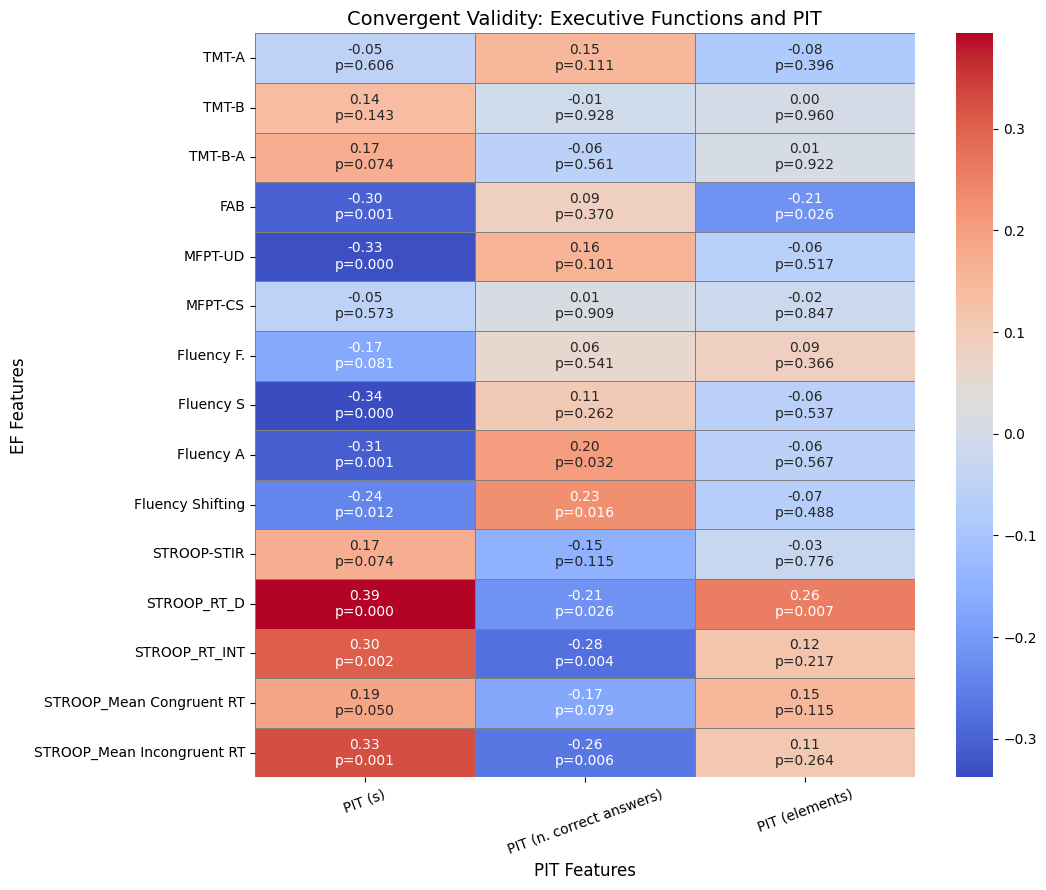

In [51]:
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT','STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']  

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

spearman_results = []
for ef in EF_features:
    for pit in pit_features:
        corr, pval = spearmanr(df_n[ef], df_n[pit])
        spearman_results.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

spearman_df = pd.DataFrame(spearman_results)

spearman_results_cleaned = []

for ef in EF_features:
    for pit in pit_features:
        # Drop NaNs pairwise
        valid_data = df_n[[ef, pit]].dropna()
        if valid_data[ef].nunique() > 1 and valid_data[pit].nunique() > 1:
            corr, pval = spearmanr(valid_data[ef], valid_data[pit])
        else:
            corr, pval = np.nan, np.nan  # Avoid errors with constant values
        spearman_results_cleaned.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

numeric_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=float)
annotation_matrix_cleaned = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    numeric_matrix_cleaned.loc[ef, pit] = corr
    if not np.isnan(corr) and not np.isnan(pval):
        annotation_matrix_cleaned.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_cleaned.loc[ef, pit] = "N/A"

plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_cleaned, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


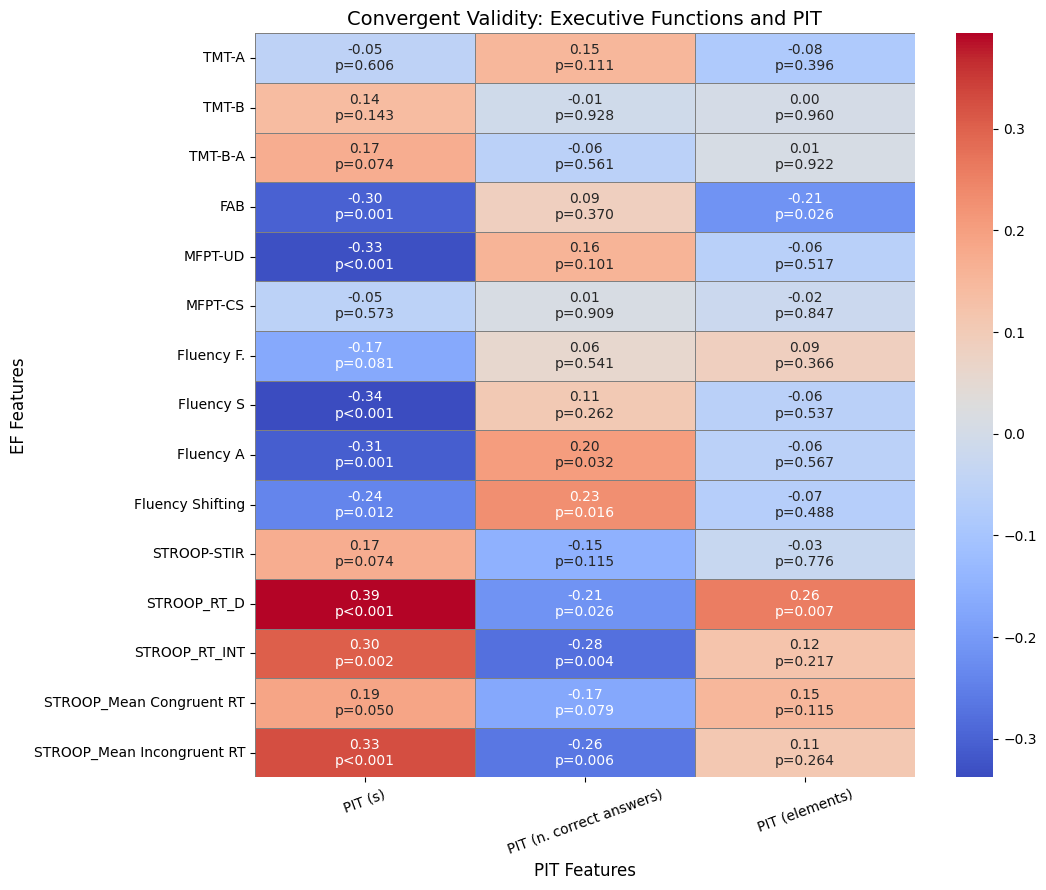

In [52]:
annotation_matrix_adjusted = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    ef = row['EF Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    
    if not np.isnan(corr) and not np.isnan(pval):
        if pval < 0.001:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np<0.001"
        else:
            annotation_matrix_adjusted.loc[ef, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_adjusted.loc[ef, pit] = "N/A"

# Plot the adjusted heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_adjusted, fmt='', cmap='coolwarm', 
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Executive Functions and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("EF Features", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


EF-PIT Spearman + CI: 100%|██████████| 15/15 [00:19<00:00,  1.27s/it]


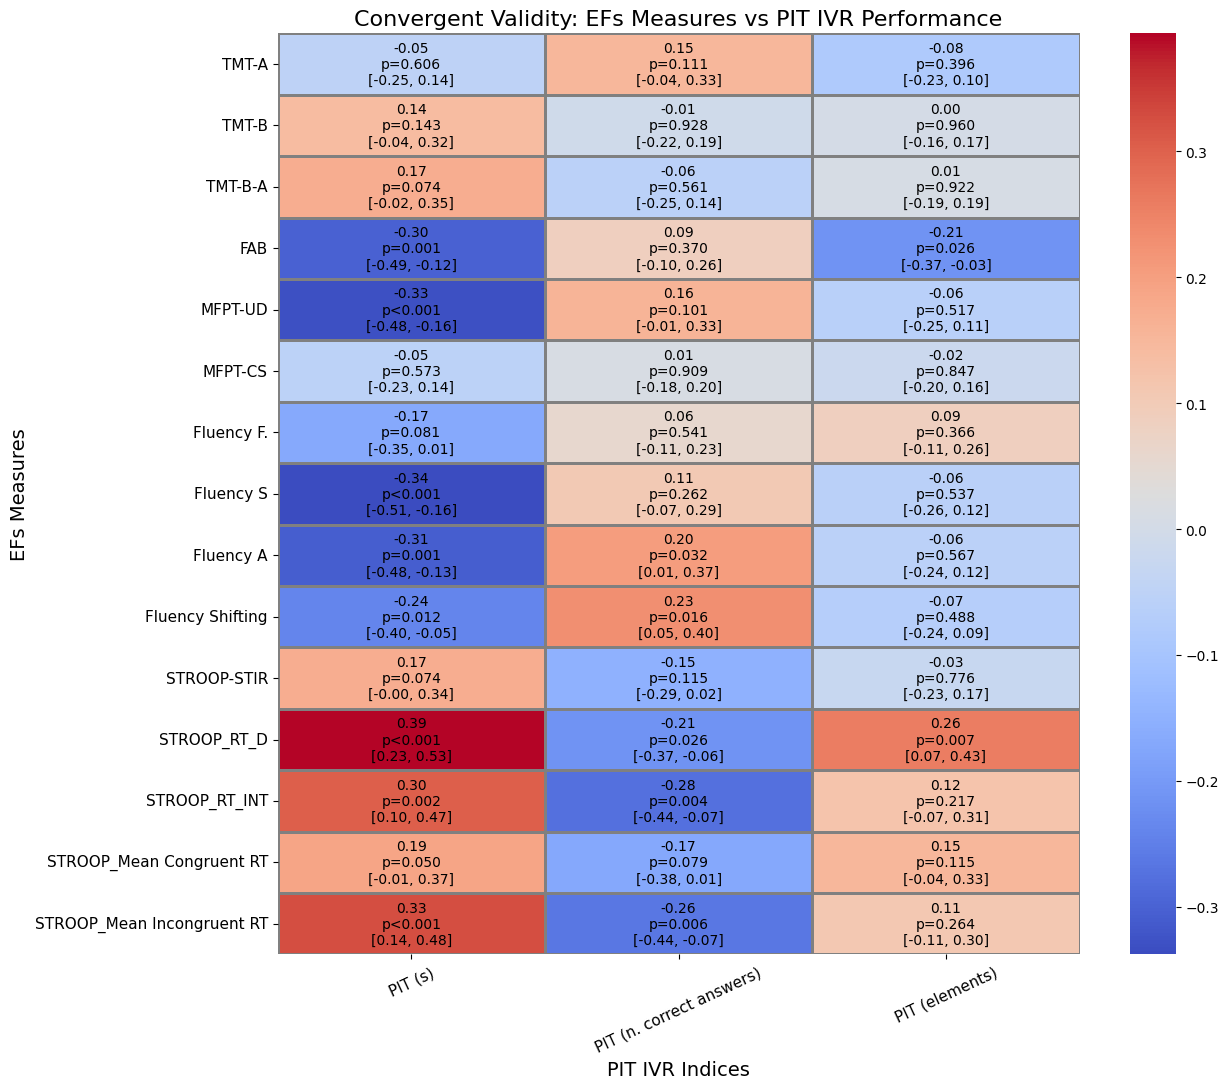

In [53]:
# Define the executive-function and PIT feature sets.
EF_features = ['TMT-A','TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency F.',
               'Fluency S', 'Fluency A', 'Fluency Shifting',
               'STROOP-STIR','STROOP_RT_D', 'STROOP_RT_INT',
               'STROOP_Mean Congruent RT','STROOP_Mean Incongruent RT']

pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Set bootstrap parameters for confidence intervals.
n_bootstrap = 1000
ci_lower = 2.5
ci_upper = 97.5

# Initialize matrices for correlations, annotations, and tabular results.
numeric_matrix_ef = pd.DataFrame(index=EF_features, columns=pit_features, dtype=float)
annotation_matrix_ef = pd.DataFrame(index=EF_features, columns=pit_features, dtype=object)
spearman_results_ef = []

# Estimate Spearman correlations and bootstrap confidence intervals.
for ef in tqdm(EF_features, desc="EF-PIT Spearman correlations with confidence intervals"):
    for pit in pit_features:
        valid_data = df_n[[ef, pit]].dropna()

        if valid_data[ef].nunique() > 1 and valid_data[pit].nunique() > 1:
            # Compute the Spearman correlation.
            corr, pval = spearmanr(valid_data[ef], valid_data[pit])

            # Bootstrap the confidence interval.
            corr_values = []
            for _ in range(n_bootstrap):
                sample = valid_data.sample(n=len(valid_data), replace=True)
                if sample[ef].nunique() > 1 and sample[pit].nunique() > 1:
                    boot_corr, _ = spearmanr(sample[ef], sample[pit])
                    if not np.isnan(boot_corr):
                        corr_values.append(boot_corr)

            if len(corr_values) > 0:
                ci_low = np.percentile(corr_values, ci_lower)
                ci_high = np.percentile(corr_values, ci_upper)
            else:
                ci_low = ci_high = np.nan
        else:
            corr = pval = ci_low = ci_high = np.nan

        # Store numerical and annotated results.
        numeric_matrix_ef.loc[ef, pit] = corr
        if not np.isnan(corr) and not np.isnan(pval):
            pval_str = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
            annotation_matrix_ef.loc[ef, pit] = f"{corr:.2f}\n{pval_str}\n[{ci_low:.2f}, {ci_high:.2f}]"
        else:
            annotation_matrix_ef.loc[ef, pit] = "N/A"

        spearman_results_ef.append({
            'EF Feature': ef,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval,
            '95% CI Lower': ci_low,
            '95% CI Upper': ci_high
        })

# Plot a publication-ready heatmap.
plt.figure(figsize=(13, 11))
sns.heatmap(
    numeric_matrix_ef.astype(float),
    annot=annotation_matrix_ef.values,
    fmt='',
    cmap='coolwarm',
    cbar=True,
    linewidths=1.0,
    linecolor='gray',
    mask=numeric_matrix_ef.isna(),
    annot_kws={"fontsize": 10, "color": "black", "va": "center"}
)
plt.title("Convergent validity: executive-function measures vs PIT-IVR performance", fontsize=16)
plt.xlabel("PIT-IVR indices", fontsize=14)
plt.ylabel("Executive-function measures", fontsize=14)
plt.xticks(rotation=25, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


# Model training and evaluation

## Multiclass classification: all three groups

In [54]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS', 'Fluency S', 'Fluency A', 'Fluency Shifting', 'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_n['group']


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"N. Training sample {len(y_train)}, {len(y_train)/len(y)*100:.2f}%")
print(f"N. Testing sample {len(y_test)}, {len(y_test)/len(y)*100:.2f}%")


N. Training sample 77, 70.00%
N. Testing sample 33, 30.00%


In [56]:
label_mapping = {'HC': 0, 'MCI': 1, 'Frailty': 2}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)


In [57]:
y_train.value_counts()


group
1    39
0    21
2    17
Name: count, dtype: int64

In [58]:
y_test.value_counts()


group
1    19
0    11
2     3
Name: count, dtype: int64

### Baseline classifier: linear discriminant analysis

In [59]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)
y_train_pred_lda = lda.predict(X_train)
y_pred_lda = lda.predict(X_test)

# Evaluate the LDA baseline model
classes = ['HC', 'MCI', 'Frailty']
print("\nLDA Classification Report on Training Set:")
print(classification_report(y_train, y_train_pred_lda, target_names=classes))
print("\nLDA Classification Report on Testing Set:\n", classification_report(y_test, y_pred_lda, target_names=classes))

# AUC-ROC
y_train_prob = lda.predict_proba(X_train)
auc_roc_t = roc_auc_score(y_train, y_train_prob, multi_class='ovo')
print(f"AUC-ROC (OvO) on Training Set: {auc_roc_t:.3f}")

y_test_prob = lda.predict_proba(X_test)
auc_roc = roc_auc_score(y_test, y_test_prob, multi_class='ovo')
print(f"AUC-ROC (OvO) on Testing Set: {auc_roc:.3f}")



LDA Classification Report on Training Set:
              precision    recall  f1-score   support

          HC       0.72      0.86      0.78        21
         MCI       0.87      0.85      0.86        39
     Frailty       0.79      0.65      0.71        17

    accuracy                           0.81        77
   macro avg       0.79      0.78      0.78        77
weighted avg       0.81      0.81      0.80        77


LDA Classification Report on Testing Set:
               precision    recall  f1-score   support

          HC       0.83      0.45      0.59        11
         MCI       0.81      0.89      0.85        19
     Frailty       0.33      0.67      0.44         3

    accuracy                           0.73        33
   macro avg       0.66      0.67      0.63        33
weighted avg       0.77      0.73      0.73        33

AUC-ROC (OvO) on Training Set: 0.905
AUC-ROC (OvO) on Testing Set: 0.838


In [ ]:
# Train and evaluate three multiclass classifiers on the same feature set.
# The comparison is intentionally kept consistent across models.
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(),
    OneVsRestClassifier(LogisticRegression(max_iter=1000)),
    KNeighborsClassifier(),
]

results = []

# Compute class-wise specificity from the confusion matrix.
def calculate_specificity(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return specificity_per_class

# Fit each model and collect train/test metrics.
for name, model in zip(model_names, models):
    model.fit(X_train, y_train)

    y_train_prob = model.predict_proba(X_train)
    y_train_pred = model.predict(X_train)

    y_test_prob = model.predict_proba(X_test)
    y_test_pred = model.predict(X_test)

    # AUC-ROC for train and test sets.
    auc_roc_train = roc_auc_score(y_train, y_train_prob, multi_class='ovo')
    auc_roc_test = roc_auc_score(y_test, y_test_prob, multi_class='ovo')

    # Classification reports for train and test sets.
    class_report_train = classification_report(y_train, y_train_pred)
    class_report_test = classification_report(y_test, y_test_pred)

    # Specificity per class for train and test sets.
    specificity_train = calculate_specificity(y_train, y_train_pred)
    specificity_test = calculate_specificity(y_test, y_test_pred)

    results.append({
        'Model': name,
        'AUC-ROC (Train)': auc_roc_train,
        'AUC-ROC (Test)': auc_roc_test,
        'Classification Report (Train)': class_report_train,
        'Classification Report (Test)': class_report_test,
        'Specificity (Train)': specificity_train,
        'Specificity (Test)': specificity_test,
    })

results_df = pd.DataFrame(results)
results_df


Model: Decision Tree
AUC-ROC (Train): 1.000
AUC-ROC (Test): 0.659
Classification Report (Training Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        17

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77

Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.70      0.64      0.67        11
           1       0.90      1.00      0.95        19
           2       0.00      0.00      0.00         3

    accuracy                           0.79        33
   macro avg       0.53      0.55      0.54        33
weighted avg       0.75      0.79      0.77        33

Specificity (Train): [1.0, 1.0, 1.0]
Specificity (Test): [0.8636363636363636, 0.8571428571428571,

In [ ]:
# Train and evaluate the balanced multiclass variants of the same three classifiers.
# The class-weight setting is changed, but the feature set and evaluation protocol stay the same.
models_balanced = [
    DecisionTreeClassifier(class_weight='balanced'),
    OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000)),  # Logistic regression is wrapped for multiclass evaluation.
    KNeighborsClassifier(),
]

results_balanced = []

# Reuse the same specificity helper and model loop structure for comparability.
for name, model in zip(model_names, models_balanced):
    model.fit(X_train, y_train)

    y_train_prob_balanced = model.predict_proba(X_train)
    y_train_pred_balanced = model.predict(X_train)

    y_test_prob_balanced = model.predict_proba(X_test)
    y_test_pred_balanced = model.predict(X_test)

    # AUC-ROC (OvO) for training and testing sets.
    auc_roc_train_balanced = roc_auc_score(y_train, y_train_prob_balanced, multi_class='ovo')
    auc_roc_test_balanced = roc_auc_score(y_test, y_test_prob_balanced, multi_class='ovo')

    class_report_train_balanced = classification_report(y_train, y_train_pred_balanced)
    class_report_test_balanced = classification_report(y_test, y_test_pred_balanced)

    specificity_train_balanced = calculate_specificity(y_train, y_train_pred_balanced)
    specificity_test_balanced = calculate_specificity(y_test, y_test_pred_balanced)

    results_balanced.append({
        'Model': name,
        'AUC-ROC (Train, Balanced)': auc_roc_train_balanced,
        'AUC-ROC (Test, Balanced)': auc_roc_test_balanced,
        'Classification Report (Train, Balanced)': class_report_train_balanced,
        'Classification Report (Test, Balanced)': class_report_test_balanced,
        'Specificity (Train, Balanced)': specificity_train_balanced,
        'Specificity (Test, Balanced)': specificity_test_balanced
    })

for result in results_balanced:
    print(f"Model (Balanced): {result['Model']}")
    print(f"AUC-ROC (Train, Balanced): {result['AUC-ROC (Train, Balanced)']:.3f}")
    print(f"AUC-ROC (Test, Balanced): {result['AUC-ROC (Test, Balanced)']:.3f}")
    print("Classification Report (Training Set, Balanced):")
    print(result['Classification Report (Train, Balanced)'])
    print("Classification Report (Testing Set, Balanced):")
    print(result['Classification Report (Test, Balanced)'])
    print(f"Specificity (Train, Balanced): {result['Specificity (Train, Balanced)']}")
    print(f"Specificity (Test, Balanced): {result['Specificity (Test, Balanced)']}")
    print("\n" + "-"*60 + "\n")


Model (Balanced): Decision Tree
AUC-ROC (Train, Balanced): 1.000
AUC-ROC (Test, Balanced): 0.707
Classification Report (Training Set, Balanced):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        17

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77

Classification Report (Testing Set, Balanced):
              precision    recall  f1-score   support

           0       0.67      0.55      0.60        11
           1       0.86      0.95      0.90        19
           2       0.33      0.33      0.33         3

    accuracy                           0.76        33
   macro avg       0.62      0.61      0.61        33
weighted avg       0.75      0.76      0.75        33

Specificity (Train, Balanced): [1.0, 1.0, 1.0]

In [62]:
# List of models to evaluate with balanced class weights
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(class_weight='balanced'),
    OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000)),
    KNeighborsClassifier(),  # KNN doesn't natively support class weights
]


def specificity_score(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return np.mean(specificity_per_class)

# StratifiedKFold cross-validation with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validation for each model
cross_val_results = {}

for name, model in zip(model_names, models):
    fold_auc_roc = []
    fold_accuracy = []
    fold_f1_weighted = []
    fold_specificity = []

    all_y_true = []
    all_y_pred = []

    for train_index, val_index in kf.split(X_train, y_train):
        # Split data into training and validation sets for this fold using .iloc for pandas DataFrames/Series
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Train model on the fold's training data
        model.fit(X_train_fold, y_train_fold)

   
        y_val_pred = model.predict(X_val_fold)
        y_val_prob = model.predict_proba(X_val_fold)

        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_val_pred)

        # Calculate AUC-ROC for OvO multiclass
        auc_roc = roc_auc_score(y_val_fold, y_val_prob, multi_class='ovo', average='weighted')
        fold_auc_roc.append(auc_roc)

        # Calculate accuracy
        accuracy = np.mean(y_val_pred == y_val_fold)
        fold_accuracy.append(accuracy)

        # Calculate F1-weighted (use weighted average F1-score)
        class_report = classification_report(y_val_fold, y_val_pred, output_dict=True)
        f1_weighted = class_report['weighted avg']['f1-score']
        fold_f1_weighted.append(f1_weighted)

        # Calculate specificity (we'll assume equal specificity for simplicity)
        specificity = specificity_score(y_val_fold, y_val_pred)
        fold_specificity.append(specificity)


    cross_val_results[name] = {
        'Weighted AUC-ROC': np.mean(fold_auc_roc),
        'Weighted Accuracy': np.mean(fold_accuracy),
        'Weighted F1-Score': np.mean(fold_f1_weighted),
        'Weighted Specificity': np.mean(fold_specificity),
        'Overall Classification Report': classification_report(all_y_true, all_y_pred)  # Overall weighted classification report
    }

for name, results in cross_val_results.items():
    print(f"Model: {name}")
    print(f"Weighted AUC-ROC (Train): {results['Weighted AUC-ROC']:.3f}")
    print(f"Weighted Accuracy (Train): {results['Weighted Accuracy']:.3f}")
    print(f"Weighted F1-Score (Train): {results['Weighted F1-Score']:.3f}")
    print(f"Weighted Specificity (Train): {results['Weighted Specificity']:.3f}")
    print("\nOverall Classification Report (Aggregated, Weighted over all folds):")
    print(results['Overall Classification Report'])
    print("\n" + "-"*60 + "\n")


Model: Decision Tree
Weighted AUC-ROC (Train): 0.653
Weighted Accuracy (Train): 0.554
Weighted F1-Score (Train): 0.549
Weighted Specificity (Train): 0.774

Overall Classification Report (Aggregated, Weighted over all folds):
              precision    recall  f1-score   support

           0       0.43      0.43      0.43        21
           1       0.70      0.67      0.68        39
           2       0.37      0.41      0.39        17

    accuracy                           0.55        77
   macro avg       0.50      0.50      0.50        77
weighted avg       0.55      0.55      0.55        77


------------------------------------------------------------

Model: Logistic Regression
Weighted AUC-ROC (Train): 0.825
Weighted Accuracy (Train): 0.586
Weighted F1-Score (Train): 0.554
Weighted Specificity (Train): 0.794

Overall Classification Report (Aggregated, Weighted over all folds):
              precision    recall  f1-score   support

           0       0.56      0.71      0.62  

In [63]:
# Hyperparameters search

param_grids = {
    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "Logistic Regression": {
        "estimator__C": [0.1, 1, 10],
        "estimator__solver": ["lbfgs", "liblinear"]
    },
    "K-Nearest Neighbors (KNN)": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"]
    },
}

# List of models to evaluate with balanced class weights
model_names = ["Decision Tree", "Logistic Regression", "K-Nearest Neighbors (KNN)"]
models = [
    DecisionTreeClassifier(class_weight='balanced'),
    OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000)),
    KNeighborsClassifier(),  # KNN doesn't natively support class weights
]


def specificity_score(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    for i in range(conf_matrix.shape[0]):
        tn = np.sum(np.delete(np.delete(conf_matrix, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(conf_matrix[:, i], i))
        specificity = tn / (tn + fp)
        specificity_per_class.append(specificity)
    return np.mean(specificity_per_class)

# StratifiedKFold cross-validation with 10 splits
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


scoring = {
    'AUC-ROC': make_scorer(roc_auc_score, multi_class='ovo', needs_proba=True),
    'Accuracy': 'accuracy',
    'F1_macro': 'f1_macro',
    'Specificity': make_scorer(specificity_score)
}

best_models = {}
grid_search_results = {}


for name, model, param_grid in zip(model_names, models, param_grids.values()):
    print(f"Performing grid search for {name}...")
    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring='roc_auc_ovo', n_jobs=-1)
    grid_search.fit(X_train, y_train)

 
    best_models[name] = grid_search.best_estimator_
    grid_search_results[name] = grid_search.best_params_

    print(f"Best hyperparameters for {name}: {grid_search.best_params_}")
    print(f"Best AUC-ROC for {name}: {grid_search.best_score_:.3f}")
    print("\n" + "-"*60 + "\n")

# Cross-validation with the best models found from GridSearchCV
cross_val_results = {}

for name, best_model in best_models.items():
    fold_auc_roc = []
    fold_accuracy = []
    fold_f1_weighted = []
    fold_specificity = []

   
    all_y_true = []
    all_y_pred = []

    for train_index, val_index in kf.split(X_train, y_train):
        # Split data into training and validation sets for this fold using .iloc for pandas DataFrames/Series
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

       
        best_model.fit(X_train_fold, y_train_fold)

        
        y_val_pred = best_model.predict(X_val_fold)
        y_val_prob = best_model.predict_proba(X_val_fold)

       
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_val_pred)

        auc_roc = roc_auc_score(y_val_fold, y_val_prob, multi_class='ovo', average='weighted')
        fold_auc_roc.append(auc_roc)

        
        accuracy = np.mean(y_val_pred == y_val_fold)
        fold_accuracy.append(accuracy)

        class_report = classification_report(y_val_fold, y_val_pred, output_dict=True)
        f1_weighted = class_report['weighted avg']['f1-score']
        fold_f1_weighted.append(f1_weighted)

        
        specificity = specificity_score(y_val_fold, y_val_pred)
        fold_specificity.append(specificity)

    
    cross_val_results[name] = {
        'Weighted AUC-ROC': np.mean(fold_auc_roc),
        'Weighted Accuracy': np.mean(fold_accuracy),
        'Weighted F1-Score': np.mean(fold_f1_weighted),
        'Weighted Specificity': np.mean(fold_specificity),
        'Overall Classification Report': classification_report(all_y_true, all_y_pred)
    }


for name, results in cross_val_results.items():
    print(f"Model: {name}")
    print(f"Weighted AUC-ROC (Train): {results['Weighted AUC-ROC']:.3f}")
    print(f"Weighted Accuracy (Train): {results['Weighted Accuracy']:.3f}")
    print(f"Weighted F1-Score (Train): {results['Weighted F1-Score']:.3f}")
    print(f"Weighted Specificity (Train): {results['Weighted Specificity']:.3f}")
    print("\nOverall Classification Report (Aggregated, Weighted over all folds):")
    print(results['Overall Classification Report'])
    print("\n" + "-"*60 + "\n")


best_model_name = max(cross_val_results, key=lambda name: cross_val_results[name]['Weighted AUC-ROC'])
print(f"The best model is {best_model_name} with a Weighted AUC-ROC of {cross_val_results[best_model_name]['Weighted AUC-ROC']:.3f}")


Performing grid search for Decision Tree...
Best hyperparameters for Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}
Best AUC-ROC for Decision Tree: 0.665

------------------------------------------------------------

Performing grid search for Logistic Regression...
Best hyperparameters for Logistic Regression: {'estimator__C': 1, 'estimator__solver': 'lbfgs'}
Best AUC-ROC for Logistic Regression: 0.812

------------------------------------------------------------

Performing grid search for K-Nearest Neighbors (KNN)...
Best hyperparameters for K-Nearest Neighbors (KNN): {'n_neighbors': 7, 'weights': 'distance'}
Best AUC-ROC for K-Nearest Neighbors (KNN): 0.714

------------------------------------------------------------

Model: Decision Tree
Weighted AUC-ROC (Train): 0.669
Weighted Accuracy (Train): 0.539
Weighted F1-Score (Train): 0.545
Weighted Specificity (Train): 0.774

Overall Classification Report (Aggregated, Weighted over all folds):
           

### Multiclass logistic-regression classifier

Logistic Regression Multiclass
              precision    recall  f1-score   support

     Frailty       0.25      0.33      0.29         6
          HC       0.55      0.60      0.57        10
         MCI       0.79      0.65      0.71        17

    accuracy                           0.58        33
   macro avg       0.53      0.53      0.52        33
weighted avg       0.62      0.58      0.59        33



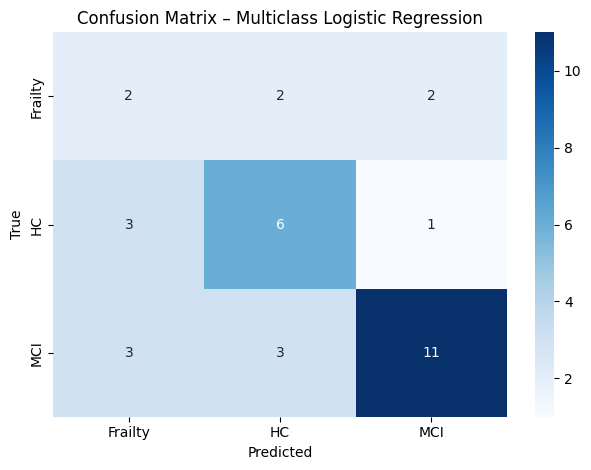


Specificity per class (One-vs-Rest):
Frailty: 0.778
HC: 0.783
MCI: 0.812


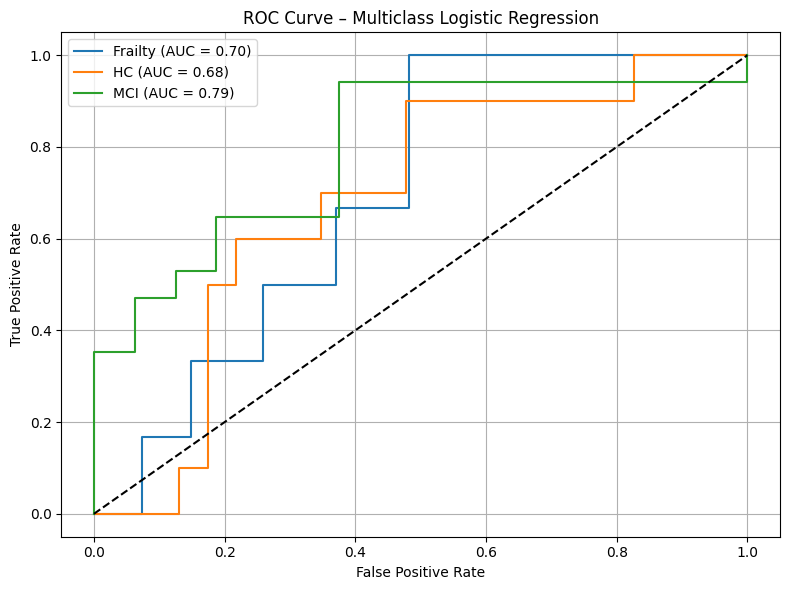

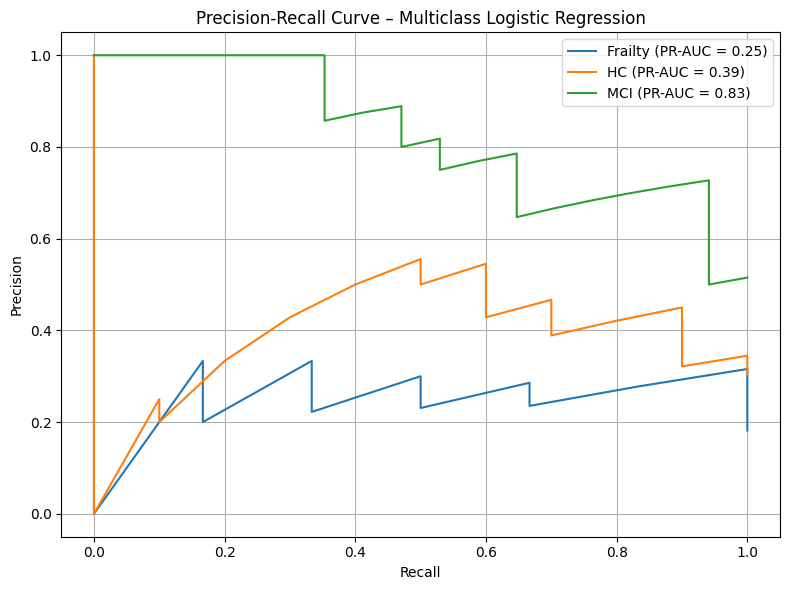


Coefficients per class (OvR):
                          Frailty     HC    MCI
TMT-B                      -0.771  0.458  0.126
TMT-B-A                     0.407 -0.690 -0.108
FAB                         1.296  0.731 -1.368
MFPT-UD                    -0.453  1.380 -0.946
MFPT-CS                     0.710 -0.862  0.329
Fluency S                   0.072  0.562 -0.770
Fluency A                   0.573  0.644 -1.212
Fluency Shifting           -0.647  0.015  0.459
STROOP-STIR                -0.415  0.213  0.185
PIT (s)                    -1.016  0.675 -0.027
PIT (n. correct answers)    0.994 -0.103 -0.356
PIT (elements)              1.182 -0.234 -0.844

Top features for class Frailty:
FAB                         1.296097
PIT (elements)              1.182099
PIT (s)                    -1.016384
PIT (n. correct answers)    0.994196
TMT-B                      -0.770506
MFPT-CS                     0.710107
Fluency Shifting           -0.647159
Fluency A                   0.572822
MFPT-UD         

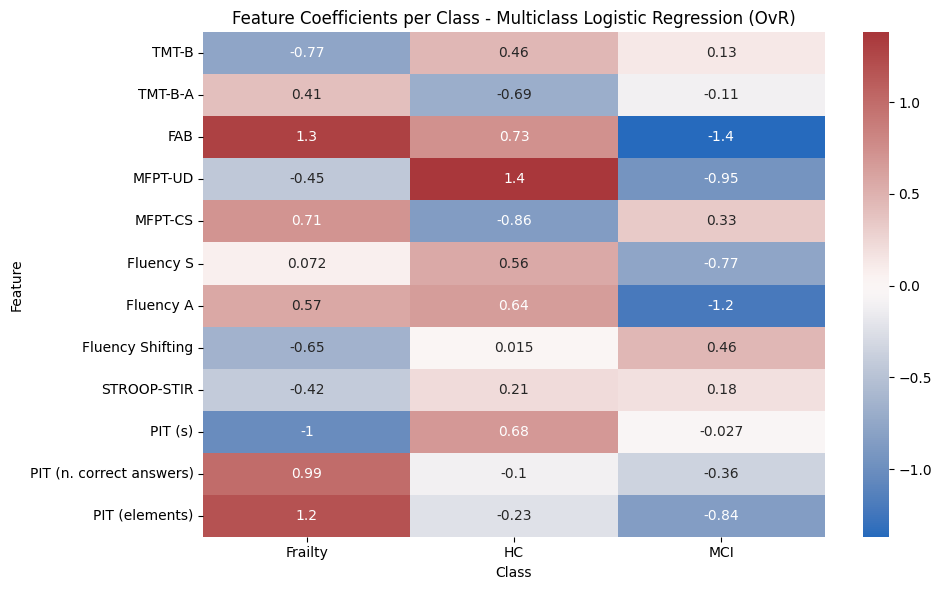

In [64]:
# Feature set 
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target: multiclass
y = df_n['group']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train Logistic Regression (OvR)
model = OneVsRestClassifier(LogisticRegression(C=1, solver='lbfgs', class_weight='balanced', max_iter=1000))
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Classification report
print("Logistic Regression Multiclass")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Multiclass Logistic Regression")
plt.tight_layout()
plt.show()

print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for i, cls in enumerate(model.classes_):
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable (only one class present)")

# Binarize y_test for One-vs-Rest metrics
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

# ROC Curves per class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – Multiclass Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curves per class
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – Multiclass Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Macro metrics dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

# Save metrics
try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# Coefficients per class
coef_matrix = np.vstack([est.coef_.ravel() for est in model.estimators_]).T
coef_df = pd.DataFrame(coef_matrix, index=X.columns, columns=model.classes_)

print("\nCoefficients per class (OvR):")
print(coef_df.round(3))

# Top features per class
for cls in model.classes_:
    print(f"\nTop features for class {cls}:")
    print(coef_df[cls].sort_values(key=abs, ascending=False).head(10))

# Plot all coefficients in a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class - Multiclass Logistic Regression (OvR)")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Multiclass logistic regression with bootstrap validation

In [65]:
# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

# Binarize y_test
y_test_bin = label_binarize(y_test, classes=model.classes_)
y_proba = model.predict_proba(X_test)


boot_metrics = {
    "accuracy": [],
    "precision_macro": [],
    "recall_macro": [],
    "f1_macro": [],
    "roc_auc_macro": [],
    "pr_auc_macro": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = model.predict(X_test.iloc[indices])
    y_proba_b = model.predict_proba(X_test.iloc[indices])

    # Skip if any class is missing
    if len(np.unique(y_true_b)) < 2:
        continue

    y_true_bin_b = label_binarize(y_true_b, classes=model.classes_)

    # PR-AUC macro
    pr_auc_list = []
    for i in range(len(model.classes_)):
        prec, rec, _ = precision_recall_curve(y_true_bin_b[:, i], y_proba_b[:, i])
        if len(prec) > 1:
            pr_auc_list.append(auc(rec, prec))
    pr_auc_macro = np.mean(pr_auc_list)

    # ROC-AUC macro
    try:
        roc_auc_macro = roc_auc_score(y_true_bin_b, y_proba_b, average='macro', multi_class='ovr')
    except ValueError:
        roc_auc_macro = np.nan

 
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision_macro"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    boot_metrics["recall_macro"].append(recall_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["f1_macro"].append(f1_score(y_true_b, y_pred_b, average='macro'))
    boot_metrics["roc_auc_macro"].append(roc_auc_macro)
    boot_metrics["pr_auc_macro"].append(pr_auc_macro)


print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    values = np.array(values)
    mean_val = np.nanmean(values)
    std_val = np.nanstd(values)
    ci_low = np.nanpercentile(values, 2.5)
    ci_high = np.nanpercentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

# Coefficients per class
print("\nCoefficients by class (one-vs-rest):")
coef_df = pd.DataFrame(
    np.vstack([est.coef_.ravel() for est in model.estimators_]).T,
    index=X_test.columns,
    columns=model.classes_
)
print(coef_df.round(3))



Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.577 ± 0.088 | 95% CI [0.394, 0.758]
PRECISION_MACRO: 0.529 ± 0.088 | 95% CI [0.365, 0.708]
RECALL_MACRO: 0.526 ± 0.097 | 95% CI [0.339, 0.728]
F1_MACRO: 0.512 ± 0.089 | 95% CI [0.348, 0.689]
ROC_AUC_MACRO: 0.723 ± 0.063 | 95% CI [0.598, 0.841]
PR_AUC_MACRO: 0.501 ± 0.060 | 95% CI [0.403, 0.642]

Coefficients by class (one-vs-rest):
                          Frailty     HC    MCI
TMT-B                      -0.771  0.458  0.126
TMT-B-A                     0.407 -0.690 -0.108
FAB                         1.296  0.731 -1.368
MFPT-UD                    -0.453  1.380 -0.946
MFPT-CS                     0.710 -0.862  0.329
Fluency S                   0.072  0.562 -0.770
Fluency A                   0.573  0.644 -1.212
Fluency Shifting           -0.647  0.015  0.459
STROOP-STIR                -0.415  0.213  0.185
PIT (s)                    -1.016  0.675 -0.027
PIT (n. correct answers)    0.994 -0.103 -0.356
PIT (elements)              1.182

### Multiclass logistic regression with SMOTE balancing


Logistic Regression Multiclass – SMOTE
              precision    recall  f1-score   support

     Frailty       0.25      0.33      0.29         6
          HC       0.55      0.60      0.57        10
         MCI       0.79      0.65      0.71        17

    accuracy                           0.58        33
   macro avg       0.53      0.53      0.52        33
weighted avg       0.62      0.58      0.59        33



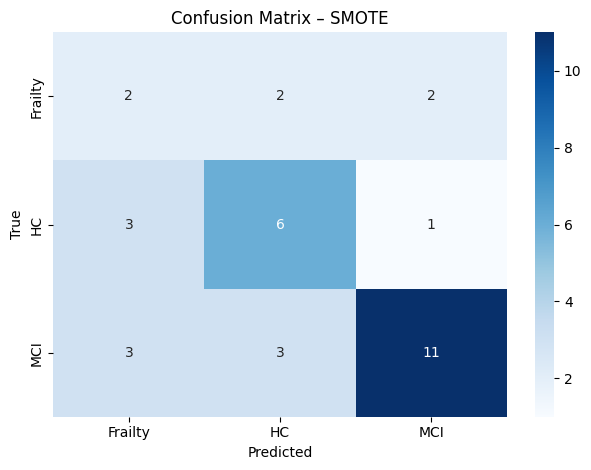


Specificity per class (One-vs-Rest):
Frailty: 0.778
HC: 0.783
MCI: 0.812


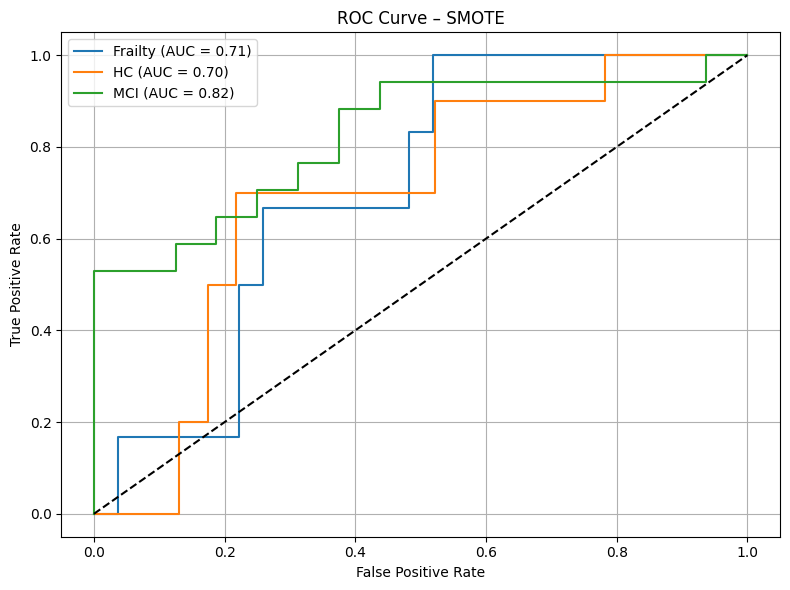

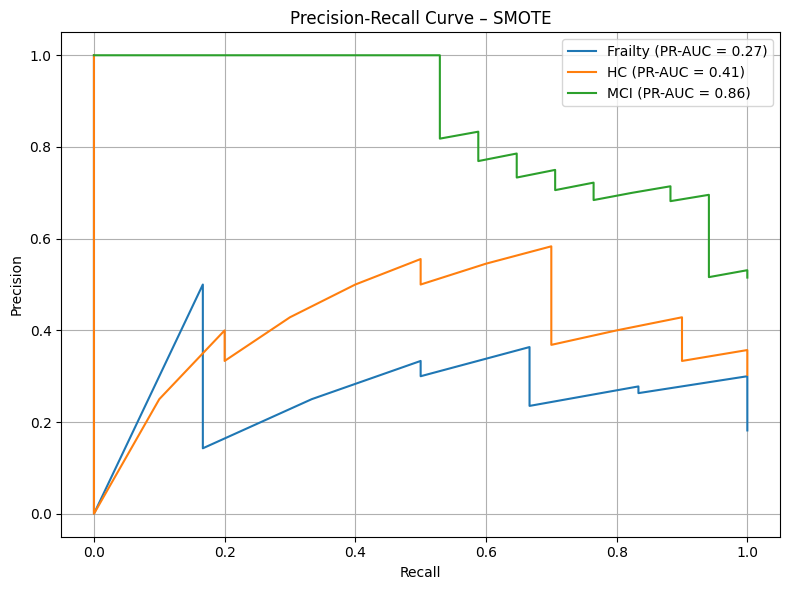


Coefficients per class (SMOTE):
                          Frailty     HC    MCI
TMT-B                      -1.256  0.889  0.443
TMT-B-A                     0.365 -0.794 -0.245
FAB                         1.577  0.496 -1.506
MFPT-UD                    -0.701  1.691 -0.927
MFPT-CS                     0.969 -0.983  0.192
Fluency S                   0.031  0.490 -0.887
Fluency A                   0.348  0.977 -1.579
Fluency Shifting           -0.818  0.113  0.675
STROOP-STIR                -0.245  0.123  0.152
PIT (s)                    -1.284  0.804  0.176
PIT (n. correct answers)    1.275 -0.433 -0.533
PIT (elements)              1.503 -0.767 -0.974


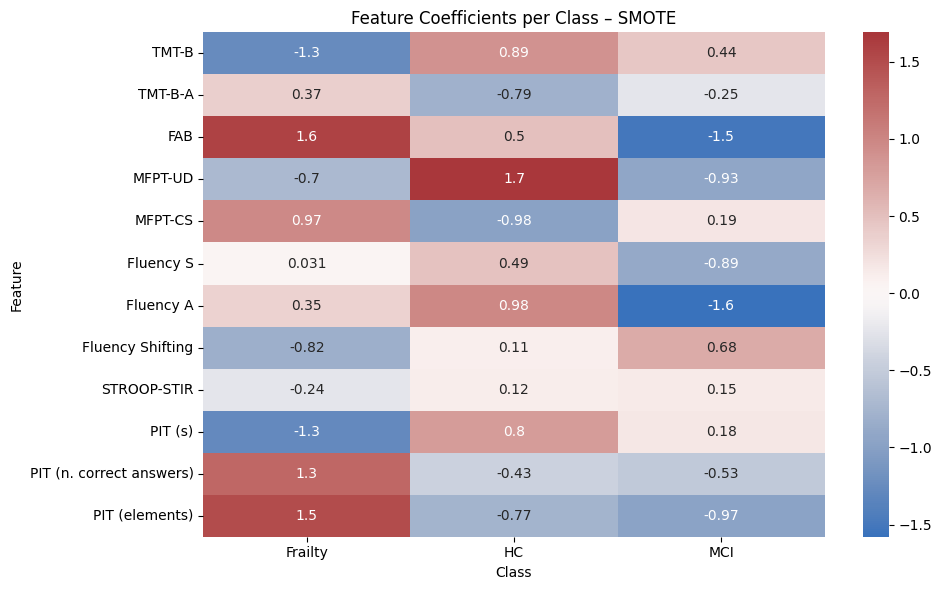

In [66]:
# Feature set
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Multiclass target
y = df_n['group']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Train model
model = OneVsRestClassifier(LogisticRegression(C=1, solver='lbfgs', class_weight='balanced', max_iter=1000))
model.fit(X_train_res, y_train_res)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Report
print("Logistic Regression Multiclass – SMOTE")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – SMOTE")
plt.tight_layout()
plt.show()

# Specificity per class (OvR)
print("\nSpecificity per class (One-vs-Rest):")
specificities = {}
for cls in model.classes_:
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    if cm_bin.shape == (2, 2):
        tn, fp, fn, tp = cm_bin.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        specificities[cls] = specificity
        print(f"{cls}: {specificity:.3f}")
    else:
        specificities[cls] = np.nan
        print(f"{cls}: Not computable")

# ROC and PR curves
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

# ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve – SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR curves
plt.figure(figsize=(8, 6))
pr_aucs = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    plt.plot(recall, precision, label=f"{model.classes_[i]} (PR-AUC = {pr_auc:.2f})")

plt.title("Precision-Recall Curve – SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save metrics to dictionary
metrics_dict = {
    "Model": "Multiclass Logistic Regression – SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average='macro'),
    "F1-score (macro)": f1_score(y_test, y_pred, average='macro'),
    "ROC-AUC (macro)": roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'),
    "PR-AUC (macro)": np.mean(pr_aucs),
    "Specificity (HC)": specificities.get('HC', np.nan),
    "Specificity (Frailty)": specificities.get('Frailty', np.nan),
    "Specificity (MCI)": specificities.get('MCI', np.nan)
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# Coefficients per class
coef_matrix = np.vstack([est.coef_.ravel() for est in model.estimators_]).T
coef_df = pd.DataFrame(coef_matrix, index=X.columns, columns=model.classes_)
print("\nCoefficients per class (SMOTE):")
print(coef_df.round(3))

# Plot heatmap of coefficients
plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, cmap="vlag", center=0)
plt.title("Feature Coefficients per Class – SMOTE")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Binary classification

Binary classifications (MCI vs all, MCI vs frailty, and HC vs frailty) were performed using LASSO logistic regression, decision-tree, and k-nearest-neighbour classifiers. Class imbalance was handled with contrast-specific random oversampling or undersampling when required.

In [67]:
df_mci_all = df_n[df_n['group'].isin(['MCI', 'HC', 'Frailty'])].copy()
X = df_mci_all[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Recode the target as binary, with MCI as the positive class and all other groups as the negative class.
y = df_mci_all['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]  # Probabilità per classe 1

# Evaluation
print("MCI vs All – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


MCI vs All – LDA
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

ROC-AUC: 0.7573529411764706


In [68]:
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Features
X = df_hc_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Encode frailty as the positive class and healthy controls as the negative class.
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("HC vs Frailty – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


HC vs Frailty – LDA
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        10
           1       0.40      0.33      0.36         6

    accuracy                           0.56        16
   macro avg       0.52      0.52      0.52        16
weighted avg       0.55      0.56      0.55        16

ROC-AUC: 0.65


In [69]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Encode frailty as the positive class and MCI as the negative class.
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LDA training
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

# Results
print("Frailty vs MCI – LDA")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Frailty vs MCI – LDA
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        18
           1       1.00      0.33      0.50         6

    accuracy                           0.83        24
   macro avg       0.91      0.67      0.70        24
weighted avg       0.86      0.83      0.80        24

ROC-AUC: 0.8703703703703705


In [70]:
features = ['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
            'Fluency S', 'Fluency A', 'Fluency Shifting',
            'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

def run_pipeline(target_mapping, label, sampling=None):
    df_copy = df_n.copy()
    df_copy['Target'] = df_copy['group'].map(target_mapping)
    df_copy = df_copy[df_copy['Target'].isin([0, 1])]

    X = df_copy[features]
    y = df_copy['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    if sampling == "over":
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
    elif sampling == "under":
        rus = RandomUnderSampler(random_state=42)
        X_train, y_train = rus.fit_resample(X_train, y_train)

    models = {
        "LASSO Logistic Regression": LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'),
        "Decision Tree": DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
        "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            "Label": label,
            "Sampling": sampling or "none",
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Specificity": spec,
            "F1-score": f1,
            "ROC-AUC": auc
        })

    return results

all_results = []

# MCI vs ALL – none and oversampling
all_results += run_pipeline({'MCI': 1, 'HC': 0, 'Frailty': 0}, 'MCI vs ALL', sampling=None)
all_results += run_pipeline({'MCI': 1, 'HC': 0, 'Frailty': 0}, 'MCI vs ALL', sampling='over')

# HC vs FRAILTY – none and oversampling
all_results += run_pipeline({'HC': 0, 'Frailty': 1}, 'HC vs FRAILTY', sampling=None)
all_results += run_pipeline({'HC': 0, 'Frailty': 1}, 'HC vs FRAILTY', sampling='over')

# MCI vs FRAILTY – none and undersampling
all_results += run_pipeline({'MCI': 1, 'Frailty': 0}, 'MCI vs FRAILTY', sampling=None)
all_results += run_pipeline({'MCI': 1, 'Frailty': 0}, 'MCI vs FRAILTY', sampling='under')


results_df = pd.DataFrame(all_results).round(3)
best_models_df = results_df.loc[results_df.groupby("Label")["F1-score"].idxmax()].reset_index(drop=True)


results_df, best_models_df


(             Label Sampling                      Model  Accuracy  Precision  \
 0       MCI vs ALL     none  LASSO Logistic Regression     0.697      0.769   
 1       MCI vs ALL     none              Decision Tree     0.545      0.538   
 2       MCI vs ALL     none                  KNN (k=3)     0.636      0.692   
 3       MCI vs ALL     over  LASSO Logistic Regression     0.697      0.769   
 4       MCI vs ALL     over              Decision Tree     0.727      0.722   
 5       MCI vs ALL     over                  KNN (k=3)     0.636      0.692   
 6    HC vs FRAILTY     none  LASSO Logistic Regression     0.625      0.500   
 7    HC vs FRAILTY     none              Decision Tree     0.562      0.400   
 8    HC vs FRAILTY     none                  KNN (k=3)     0.438      0.200   
 9    HC vs FRAILTY     over  LASSO Logistic Regression     0.562      0.429   
 10   HC vs FRAILTY     over              Decision Tree     0.500      0.400   
 11   HC vs FRAILTY     over            

# Binary classification: LASSO logistic regression

## Baseline contrast: MCI vs all


Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.891 ± 0.065
PR-AUC:   0.924 ± 0.049
MCI vs (HC + Frailty)
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.831
PR-AUC: 0.867

Non-zero coefficients (LASSO-selected features):
             Feature  Coefficient
6          Fluency A    -1.115037
2                FAB    -1.111511
3            MFPT-UD    -0.933706
5          Fluency S    -0.618080
11    PIT (elements)    -0.463938
8        STROOP-STIR     0.260923
7   Fluency Shifting     0.108894
0              TMT-B     0.030192


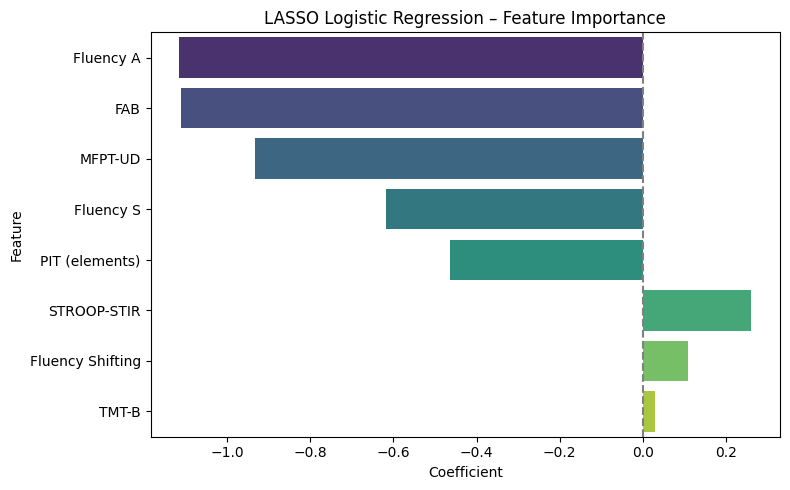

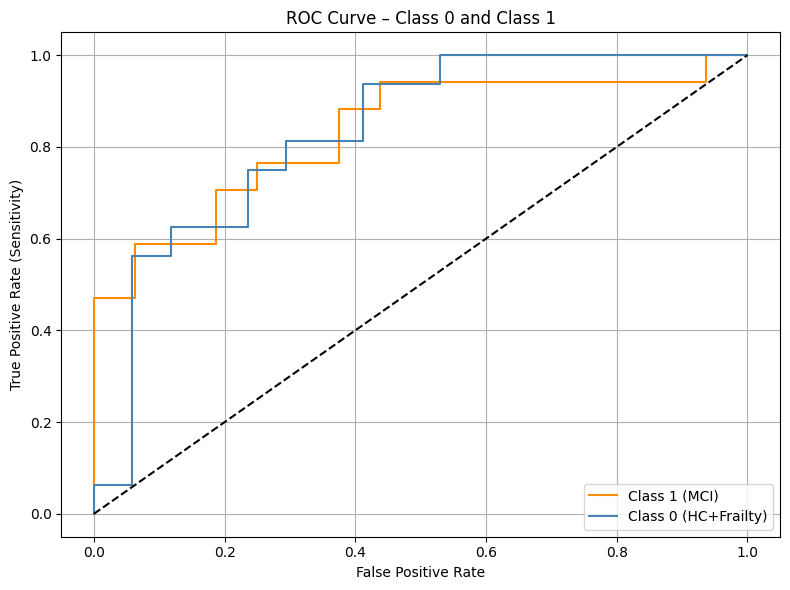

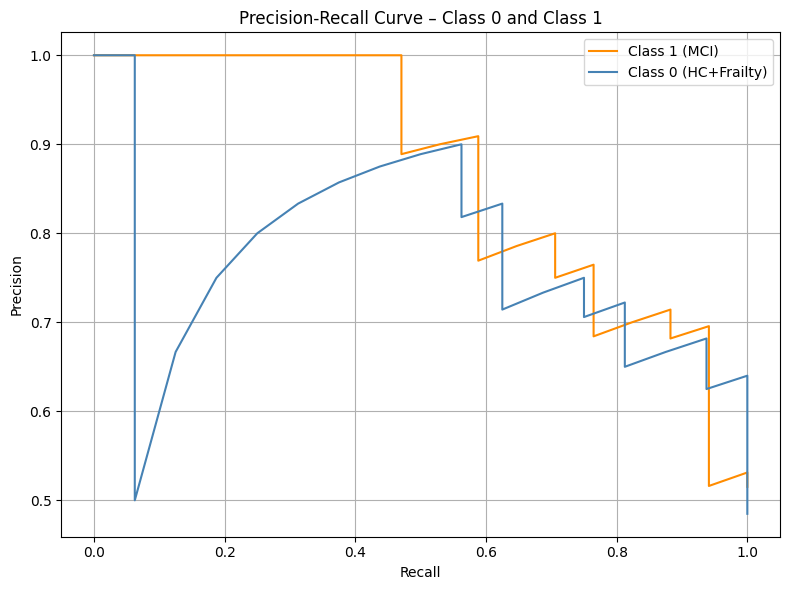

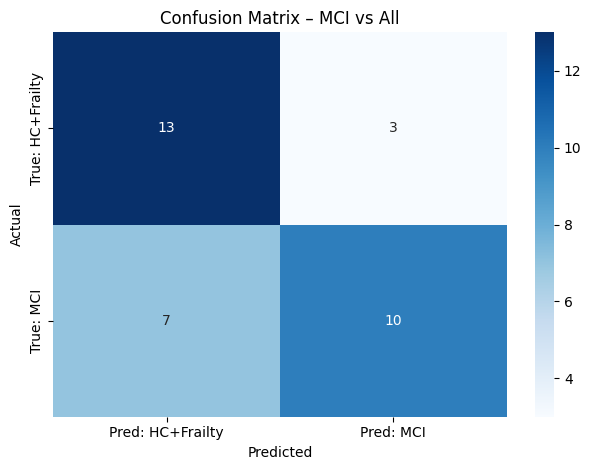


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.829 ± 0.075 | 95% CI [0.673, 0.956]
PR_AUC: 0.863 ± 0.068 | 95% CI [0.693, 0.964]

Training set metrics:
Accuracy: 0.870
Precision: 0.943
Recall (Sensitivity): 0.805
Specificity: 0.944
F1-score: 0.868
ROC-AUC: 0.955
PR-AUC: 0.966


In [71]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LASSO Model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)  # same as sensitivity
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)


print("MCI vs (HC + Frailty)")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Extract and display non-zero coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Keep only non-zero coefficients
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("\nNon-zero coefficients (LASSO-selected features):")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()


# ROC Curve for both classes
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve for both classes
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 (MCI)', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All")
plt.tight_layout()
plt.show()

# Bootstrapping all metrics
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class
    if len(np.unique(y_true_b)) < 2:
        continue

    
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue  # skip bootstrap samples with invalid confusion matrix

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    # Metrics
    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

# Print bootstrapped results
print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

# Training set metrics
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
tn_t, fp_t, fn_t, tp_t = cm_train.ravel()
specificity_train = tn_t / (tn_t + fp_t)
sensitivity_train = tp_t / (tp_t + fn_t)

acc_train = accuracy_score(y_train, y_train_pred)
prec_train = precision_score(y_train, y_train_pred, zero_division=0)
rec_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_train_proba)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("\nTraining set metrics:")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO Logistic",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]


## Selected best-performing model: MCI vs All with random oversampling

Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.894 ± 0.065
PR-AUC:   0.922 ± 0.053
Training set metrics
Accuracy: 0.890
Precision: 0.944
Recall (Sensitivity): 0.829
Specificity: 0.951
F1-score: 0.883
ROC-AUC: 0.960
PR-AUC: 0.966
Test set metrics
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.824
PR-AUC: 0.859


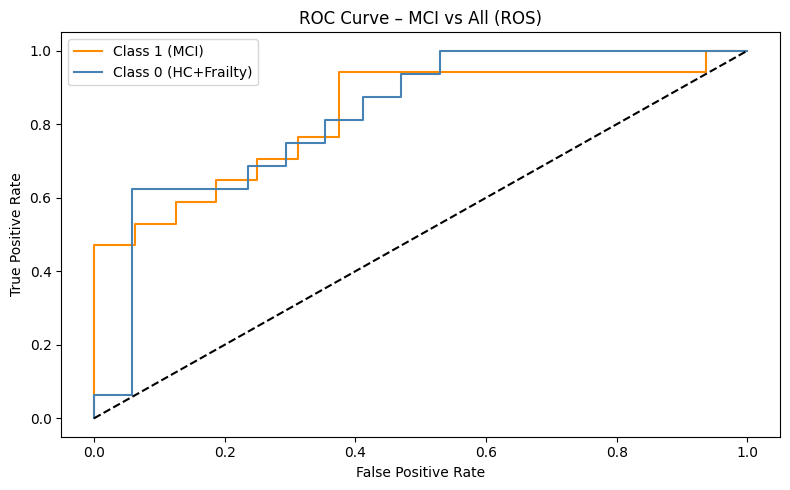

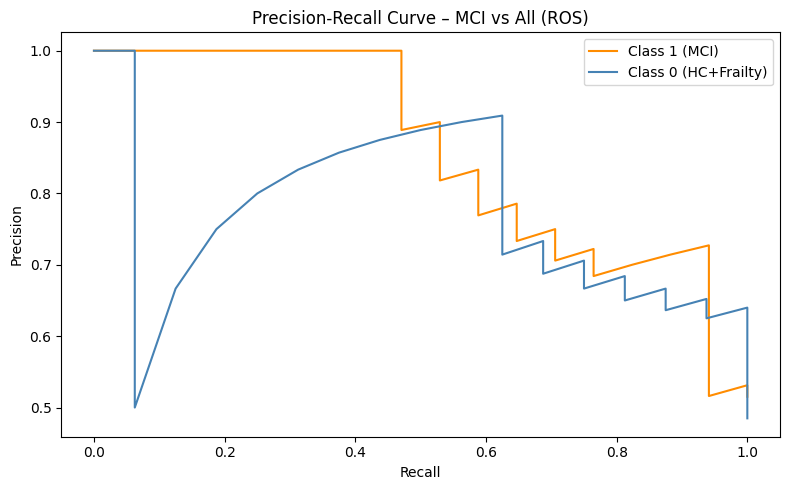

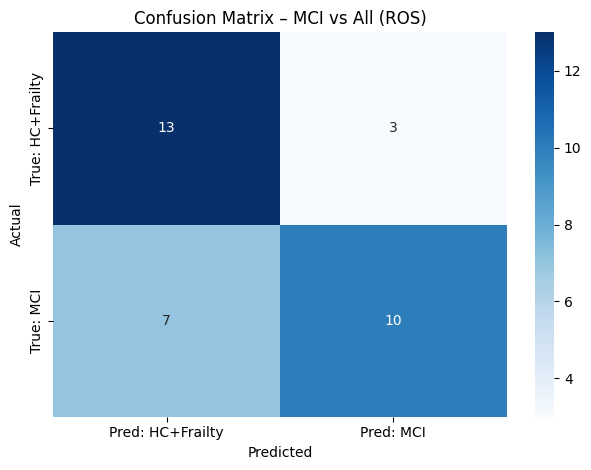

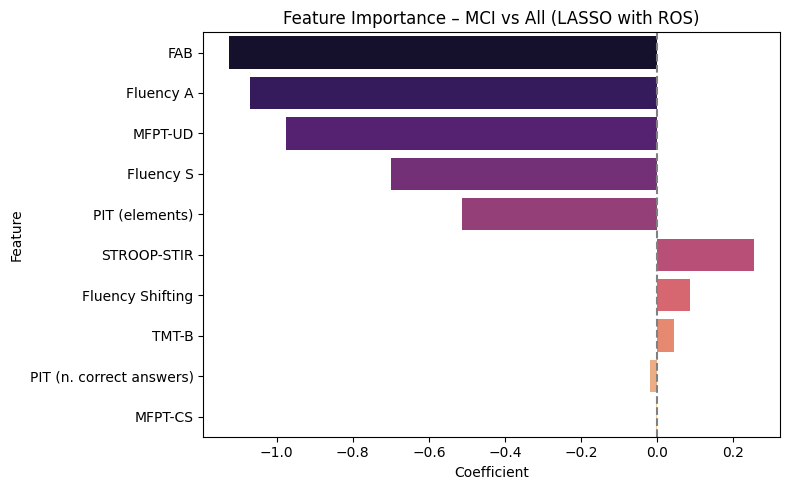

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.822 ± 0.077 | 95% CI [0.665, 0.954]
PR_AUC: 0.855 ± 0.070 | 95% CI [0.687, 0.962]


In [72]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_ros, y_train_ros)

y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

y_pred_train = model.predict(X_train_ros)
y_proba_train = model.predict_proba(X_train_ros)[:, 1]

cm_train = confusion_matrix(y_train_ros, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train_ros, y_pred_train)
prec_train = precision_score(y_train_ros, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_ros, y_pred_train)
f1_train = f1_score(y_train_ros, y_pred_train)
roc_auc_train = roc_auc_score(y_train_ros, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_ros, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (ROS)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5), facecolor='white') 
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.grid(False)
plt.show()

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (ROS)")
plt.tight_layout()
plt.show()

coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with ROS)')
plt.tight_layout()
plt.show()

n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## MCI vs all with SMOTE balancing


Cross-Validation Results (5-fold):
Accuracy: 0.782 ± 0.034
F1-score: 0.790 ± 0.042
ROC-AUC:  0.882 ± 0.072
PR-AUC:   0.919 ± 0.054
Training set metrics
Accuracy: 0.890
Precision: 0.944
Recall (Sensitivity): 0.829
Specificity: 0.951
F1-score: 0.883
ROC-AUC: 0.960
PR-AUC: 0.967
Test set metrics
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.77      0.59      0.67        17

    accuracy                           0.70        33
   macro avg       0.71      0.70      0.69        33
weighted avg       0.71      0.70      0.69        33

Accuracy: 0.697
Precision: 0.769
Recall (Sensitivity): 0.588
Specificity: 0.812
F1-score: 0.667
ROC-AUC: 0.827
PR-AUC: 0.868


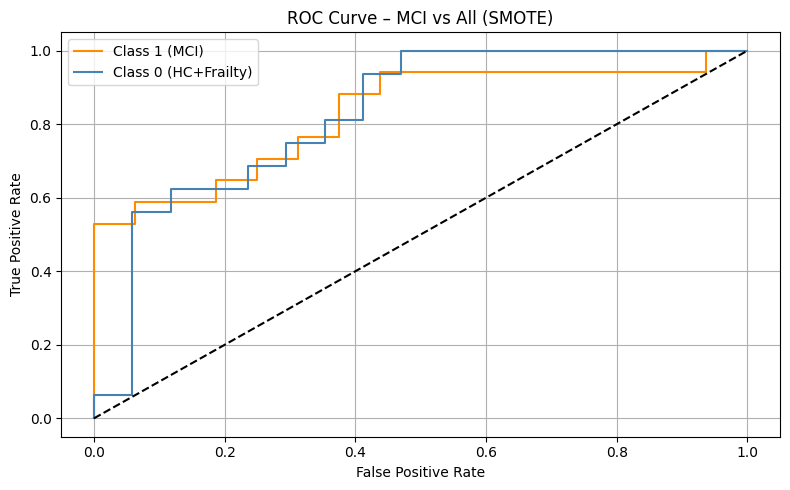

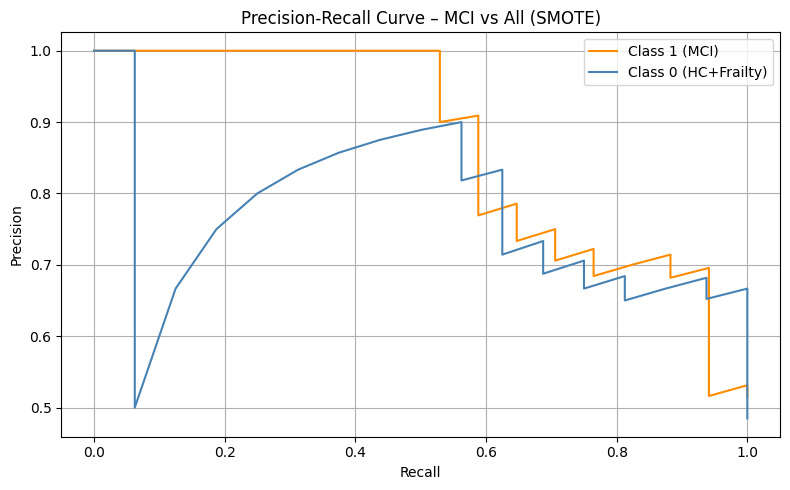

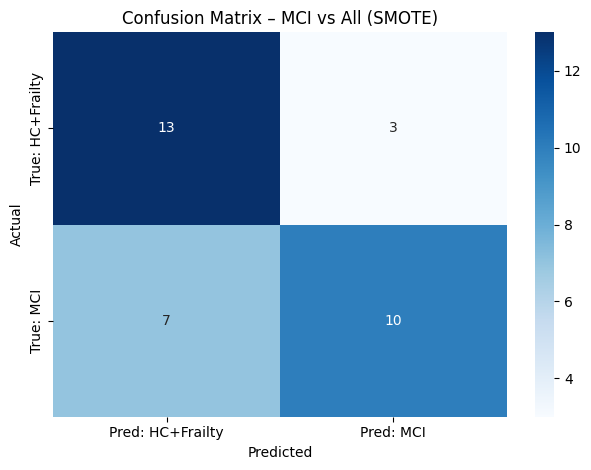

Selected non-zero coefficients
                     Feature  Coefficient
6                  Fluency A    -1.307460
2                        FAB    -1.182462
3                    MFPT-UD    -0.945213
5                  Fluency S    -0.579854
11            PIT (elements)    -0.512015
7           Fluency Shifting     0.244185
8                STROOP-STIR     0.233344
10  PIT (n. correct answers)    -0.016626


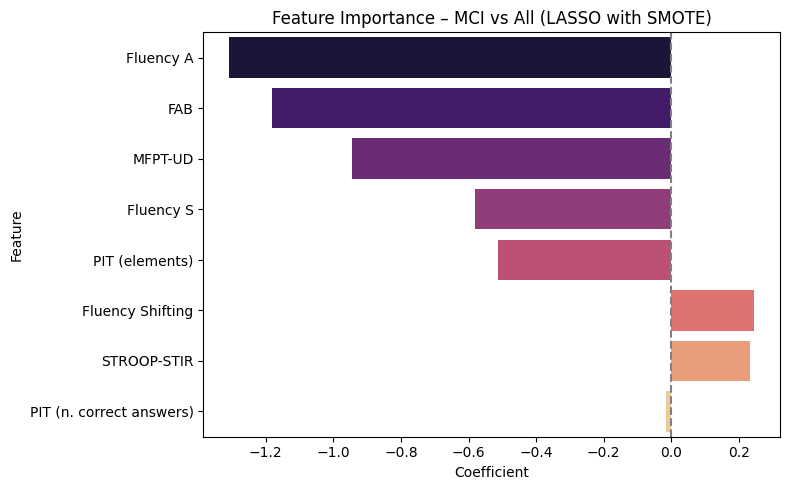

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.695 ± 0.081 | 95% CI [0.545, 0.848]
PRECISION: 0.764 ± 0.118 | 95% CI [0.500, 1.000]
RECALL: 0.589 ± 0.122 | 95% CI [0.353, 0.818]
SPECIFICITY: 0.807 ± 0.099 | 95% CI [0.583, 1.000]
F1: 0.658 ± 0.103 | 95% CI [0.435, 0.839]
ROC_AUC: 0.826 ± 0.076 | 95% CI [0.665, 0.954]
PR_AUC: 0.864 ± 0.067 | 95% CI [0.707, 0.963]


In [73]:
# MCI vs All (SMOTE)
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_smote, y_train_smote)

# Test set evaluation
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
specificity_test = tn / (tn + fp)
sensitivity_test = tp / (tp + fn)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_vals_test, recall_vals_test, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc_test = auc(recall_vals_test, precision_vals_test)

# Training set evaluation
y_pred_train = model.predict(X_train_smote)
y_proba_train = model.predict_proba(X_train_smote)[:, 1]

cm_train = confusion_matrix(y_train_smote, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

acc_train = accuracy_score(y_train_smote, y_pred_train)
prec_train = precision_score(y_train_smote, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_smote, y_pred_train)
f1_train = f1_score(y_train_smote, y_pred_train)
roc_auc_train = roc_auc_score(y_train_smote, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_smote, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

print("Training set metrics")
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred_test))
print(f"Accuracy: {acc_test:.3f}")
print(f"Precision: {prec_test:.3f}")
print(f"Recall (Sensitivity): {rec_test:.3f}")
print(f"Specificity: {specificity_test:.3f}")
print(f"F1-score: {f1_test:.3f}")
print(f"ROC-AUC: {roc_auc_test:.3f}")
print(f"PR-AUC: {pr_auc_test:.3f}")

metrics_dict = {
    "Model": "MCI vs All – LASSO (SMOTE)",
    "Accuracy": acc_test,
    "Precision": prec_test,
    "Recall (Sensitivity)": rec_test,
    "Specificity": specificity_test,
    "F1-score": f1_test,
    "ROC-AUC": roc_auc_test,
    "PR-AUC": pr_auc_test
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba_test)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba_test)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba_test)

plt.figure(figsize=(8, 5))
plt.plot(rec1, prec1, label='Class 1 (MCI)', color='darkorange')
plt.plot(rec0, prec0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs All (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All (SMOTE)")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – MCI vs All (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]
    y_proba_b = y_proba_test[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The ROS-based model achieved the best MCI vs all performance, with the strongest balance of recall, F1-score, accuracy, precision, and AUC, making it the most suitable option when sensitivity is prioritized.

### Ablation study: with and without PIT features

             Accuracy  Precision  Recall (Sensitivity)  Specificity     F1  \
With PIT        0.697      0.769                 0.588        0.812  0.667   
Without PIT     0.727      0.722                 0.765        0.688  0.743   

             ROC-AUC  PR-AUC  
With PIT       0.824   0.859  
Without PIT    0.838   0.881  


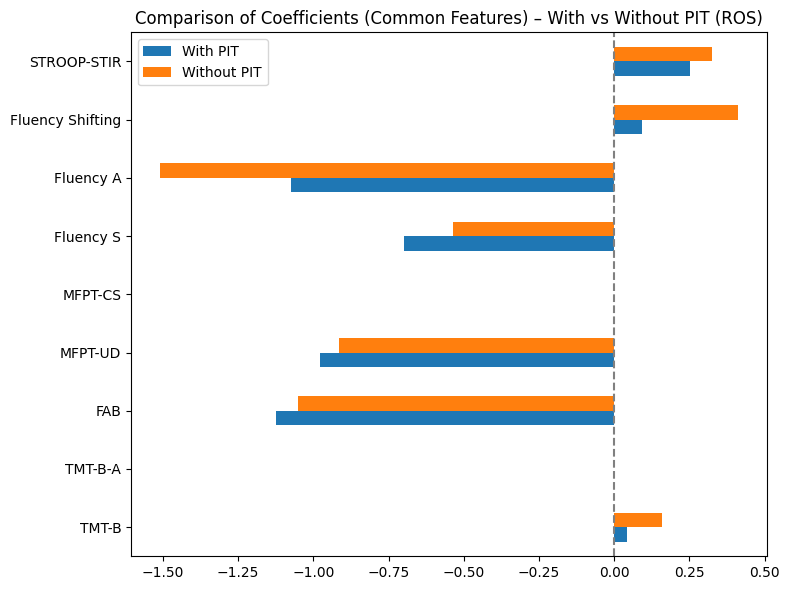

In [74]:
# LASSO LR with ROS
# PIT features
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Full feature set
X_full = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
               'Fluency S', 'Fluency A', 'Fluency Shifting',
               'STROOP-STIR'] + pit_features]

# Feature set without PIT
X_nopit = X_full.drop(columns=pit_features)

# Target
y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

# Train-test split
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_f_ros, y_train_ros = ros.fit_resample(X_train_f, y_train)
X_train_np_ros, _ = ros.fit_resample(X_train_np, y_train)  # Use same indices

# Train LASSO models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')

model_full.fit(X_train_f_ros, y_train_ros)
model_nopit.fit(X_train_np_ros, y_train_ros)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metrics
def compute_metrics(y_true, y_pred, y_proba):
    prec, recall, _ = precision_recall_curve(y_true, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall, prec)
    }

results = pd.DataFrame({
    'With PIT': compute_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': compute_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print(results)

# Coefficients
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

common_features = [col for col in coef_f.index if col in coef_np.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Comparison of Coefficients (Common Features) – With vs Without PIT (ROS)")
plt.tight_layout()
plt.show()


### Permutation importance: MCI vs all

In [75]:
X = df_n[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
          'Fluency S', 'Fluency A', 'Fluency Shifting',
          'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

y = df_n['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)


model_full = LogisticRegression(penalty='l1', solver='liblinear')
model_full.fit(X_train_ros, y_train_ros)


def safe_roc_auc(estimator, X, y):
    if len(np.unique(y)) < 2:
        return 0.0
    y_scores = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y, y_scores)


result = permutation_importance(
    estimator=model_full,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=safe_roc_auc  # <-- FIX QUI
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False)

print("\nPermutation Importance (based on ROC-AUC, MCI vs All):")
print(perm_df)


threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered = perm_df_filtered.sort_values(by='Importance', ascending=False)


error_bar_factor = 0.05 
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * error_bar_factor


fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – MCI vs All (RO)",
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis',
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True, autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()



Permutation Importance (based on ROC-AUC, MCI vs All):
                     Feature  Importance       Std
6                  Fluency A    0.112990  0.051066
2                        FAB    0.105147  0.057543
3                    MFPT-UD    0.029902  0.038847
8                STROOP-STIR    0.026103  0.017227
5                  Fluency S    0.018382  0.031825
11            PIT (elements)    0.008333  0.033019
0                      TMT-B    0.002574  0.004665
1                    TMT-B-A    0.000000  0.000000
4                    MFPT-CS    0.000000  0.000000
9                    PIT (s)    0.000000  0.000000
10  PIT (n. correct answers)   -0.000735  0.002401
7           Fluency Shifting   -0.004412  0.007558


### Selected semantic-feature model: MCI vs all

Test Set Metrics – MCI vs (HC + Frailty)
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.86      0.71      0.77        17

    accuracy                           0.79        33
   macro avg       0.80      0.79      0.79        33
weighted avg       0.80      0.79      0.79        33

Accuracy: 0.788
Precision: 0.857
Recall (Sensitivity): 0.706
Specificity: 0.875
F1-score: 0.774
ROC-AUC: 0.801
PR-AUC: 0.853
Stratified Cross-Validation (5 folds):
ACCURACY: 0.770 ± 0.052
PRECISION: 0.805 ± 0.061
RECALL: 0.752 ± 0.153
F1: 0.765 ± 0.073
ROC_AUC: 0.871 ± 0.068
AVERAGE_PRECISION: 0.901 ± 0.055
Non-zero Coefficients (LASSO):
               Feature  Coefficient
5            Fluency S    -1.419788
6            Fluency A    -1.182508
2                  FAB    -0.817628
3              MFPT-UD    -0.721603
15  perseverations_tot    -0.408714
21      Clustering_PIT     0.284729
8          STROOP-STIR     0.278499
11  

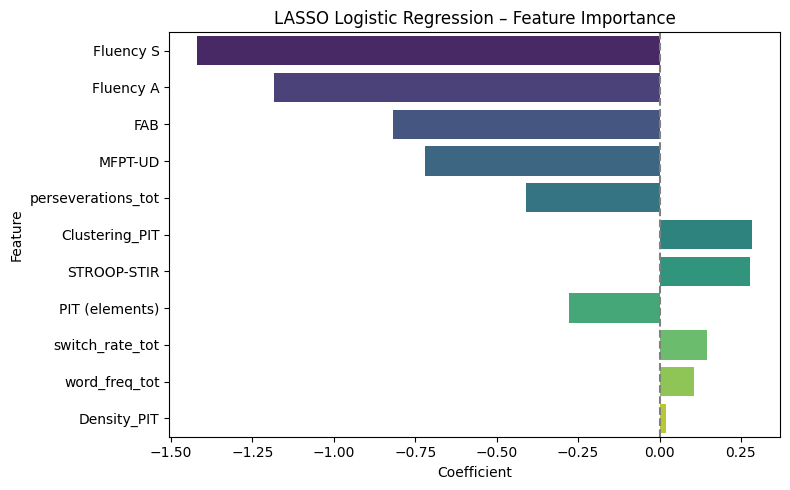

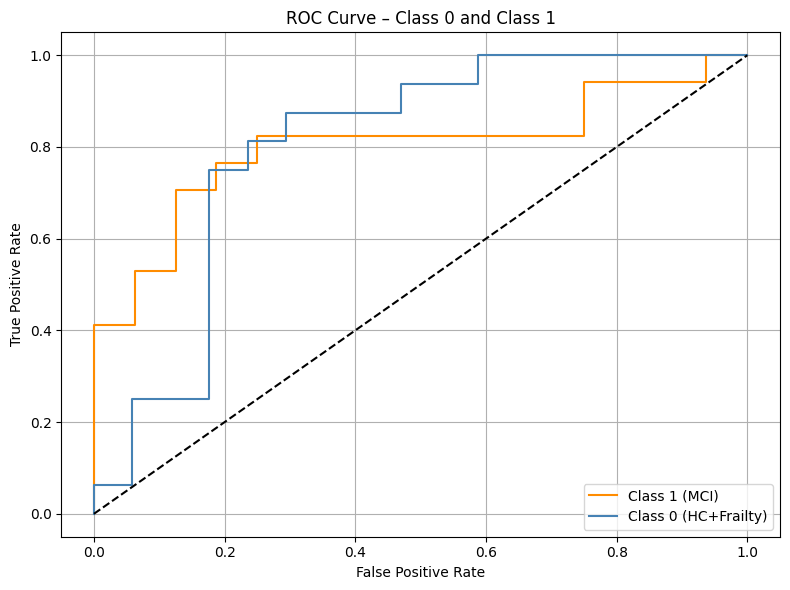

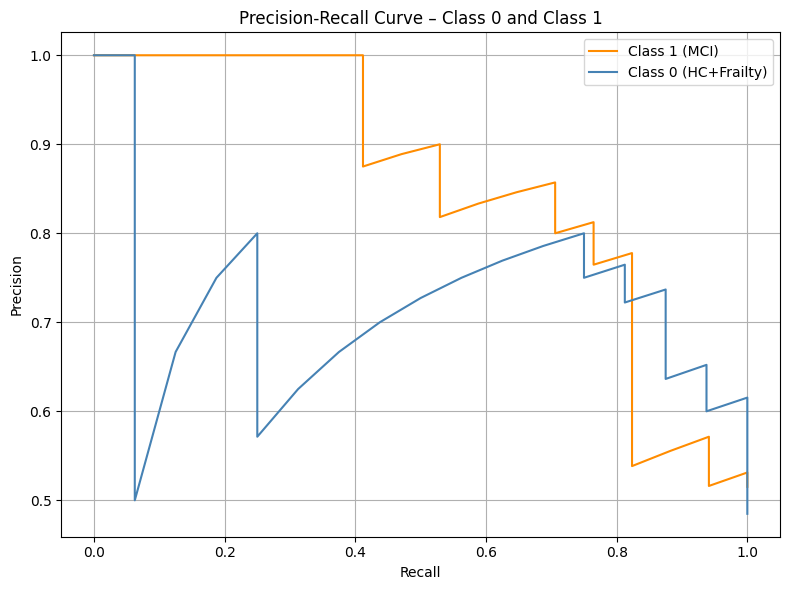

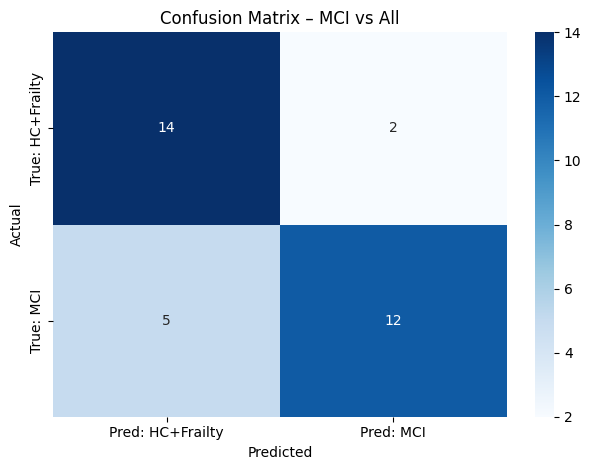

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.785 ± 0.073 | 95% CI [0.636, 0.909]
PRECISION: 0.851 ± 0.098 | 95% CI [0.636, 1.000]
RECALL: 0.706 ± 0.114 | 95% CI [0.470, 0.917]
SPECIFICITY: 0.868 ± 0.089 | 95% CI [0.684, 1.000]
F1: 0.766 ± 0.089 | 95% CI [0.571, 0.919]
ROC_AUC: 0.799 ± 0.083 | 95% CI [0.630, 0.948]
PR_AUC: 0.849 ± 0.075 | 95% CI [0.676, 0.963]


In [147]:
df = pd.read_csv("df_merged (semantic+nps).csv")

selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_ros, y_train_ros)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – MCI vs (HC + Frailty)")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('ros', RandomOverSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

# SAVE non-zero LASSO subset for later robustness cells (MCI vs All) 
feature_subset_mcia = coef_df["Feature"].tolist()
coef_series_mcia = pd.Series(
    coef_df["Coefficient"].values,
    index=coef_df["Feature"].values
)
print("Saved feature_subset_mcia (n features):", len(feature_subset_mcia))

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 (MCI)', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 (MCI)', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 (HC+Frailty)', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC+Frailty", "Pred: MCI"],
            yticklabels=["True: HC+Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs All")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP interpretation: MCI vs all


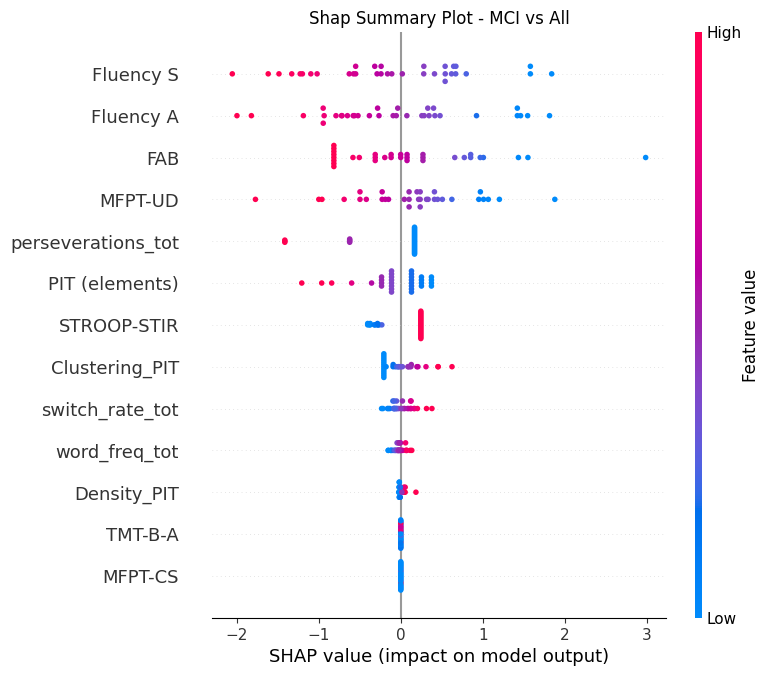

In [77]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

X = df[selected_features]
y = df['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_ros)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_ros)

# Compute SHAP values and generate the summary plot.
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - MCI vs All", show=False)
plt.title("Shap Summary Plot - MCI vs All")
plt.show()

y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Save the fitted binary model used for SHAP so it can be reused later
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}

binary_model_outputs['MCI vs All'] = {
    'comparison_name': 'MCI vs All',
    'positive_group': 'MCI',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}


## Selected best-performing model: FF vs HC

Cross-Validation Results (5-fold):
Accuracy: 0.655 ± 0.039
F1-score: 0.380 ± 0.221
ROC-AUC:  0.602 ± 0.039
PR-AUC:   0.552 ± 0.112
Training set metrics
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.81      0.93      0.87        14

    accuracy                           0.89        36
   macro avg       0.88      0.90      0.89        36
weighted avg       0.90      0.89      0.89        36

Accuracy: 0.889
Precision: 0.812
Recall (Sensitivity): 0.929
Specificity: 0.864
F1-score: 0.867
ROC-AUC: 0.906
PR-AUC: 0.770
HC vs Frailty – Full model
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.50      0.50      0.50         6

    accuracy                           0.62        16
   macro avg       0.60      0.60      0.60        16
weighted avg       0.62      0.62      0.62        16

Accuracy: 0.625
Precision: 0.500
Recall (S

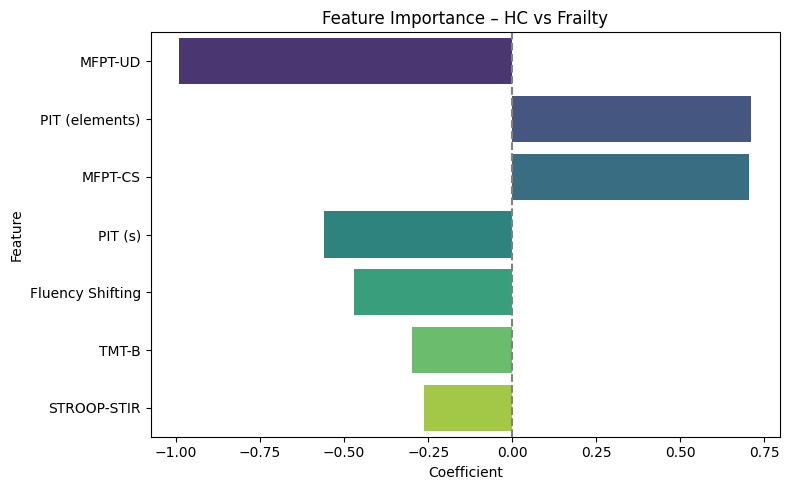

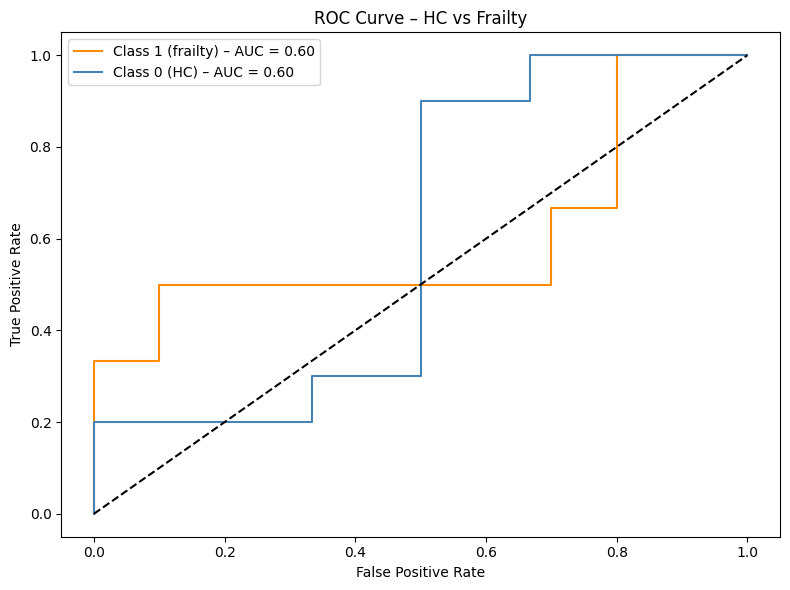

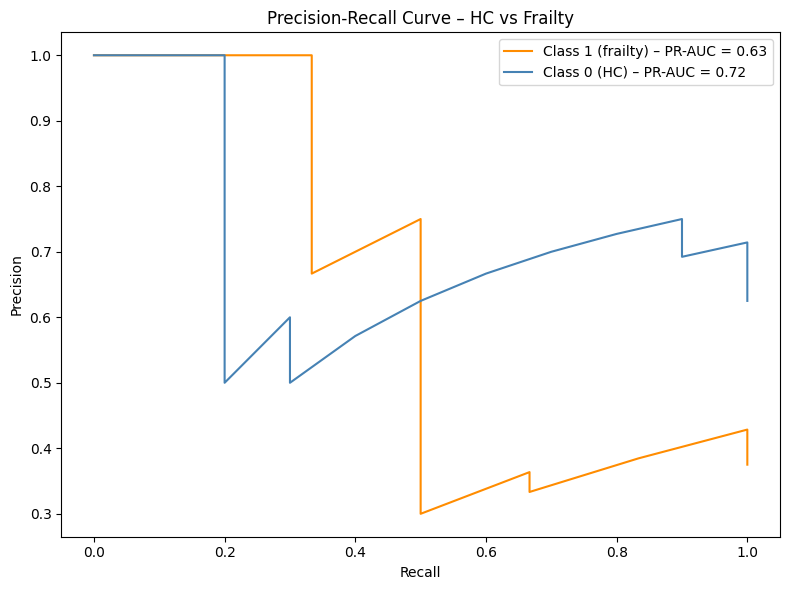

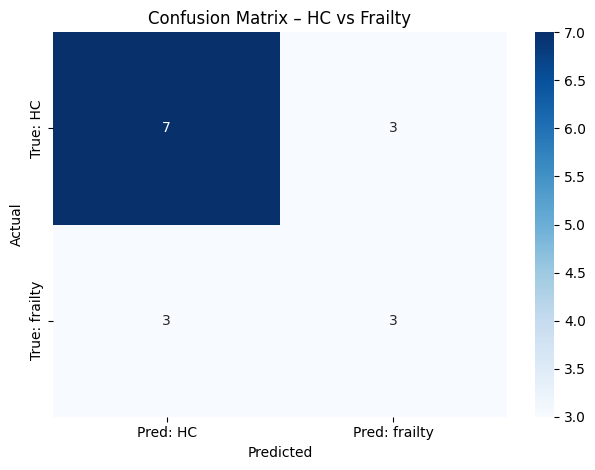


Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.627 ± 0.124 | 95% CI [0.375, 0.875]
PRECISION: 0.506 ± 0.225 | 95% CI [0.000, 1.000]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.706 ± 0.151 | 95% CI [0.400, 1.000]
F1: 0.477 ± 0.188 | 95% CI [0.000, 0.824]
ROC_AUC: 0.599 ± 0.183 | 95% CI [0.222, 0.979]
PR_AUC: 0.629 ± 0.195 | 95% CI [0.161, 0.947]


In [78]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter only HC and Frailty subjects
df_hc_frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

X = df_hc_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR'] + pit_features]

# Encode frailty as the positive class and healthy controls as the negative class.
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# LASSO Logistic Regression
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Predictions on training set
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)
sensitivity_train = tp_tr / (tp_tr + fn_tr)

# Metrics on training set
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Metrics
print("HC vs Frailty – Full model")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall (Sensitivity): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC: {auc(recall_vals, precision_vals):.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs', ascending=False)

print("\nSelected coefficients:")
print(coef_df[['Feature', 'Coefficient']])


plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – HC vs Frailty")
plt.tight_layout()
plt.show()

# ROC and PR curves for class 0 and 1
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


# PR curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (frailty) – PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (HC) – PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: frailty"],
            yticklabels=["True: HC", "True: frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Bootstrapping (1000 iterations) 
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    # Skip if only one class present
    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("\nBootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## FF vs HC with random oversampling

Cross-Validation Results (5-fold):
Accuracy: 0.675 ± 0.091
F1-score: 0.501 ± 0.253
ROC-AUC:  0.671 ± 0.035
PR-AUC:   0.602 ± 0.080
Training set metrics
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.88      0.95      0.91        22

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

Accuracy: 0.909
Precision: 0.875
Recall (Sensitivity): 0.955
Specificity: 0.864
F1-score: 0.913
ROC-AUC: 0.905
PR-AUC: 0.847
Test set metrics
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.43      0.50      0.46         6

    accuracy                           0.56        16
   macro avg       0.55      0.55      0.55        16
weighted avg       0.58      0.56      0.57        16

Accuracy: 0.562
Precision: 0.429
Recall (Sensitivity

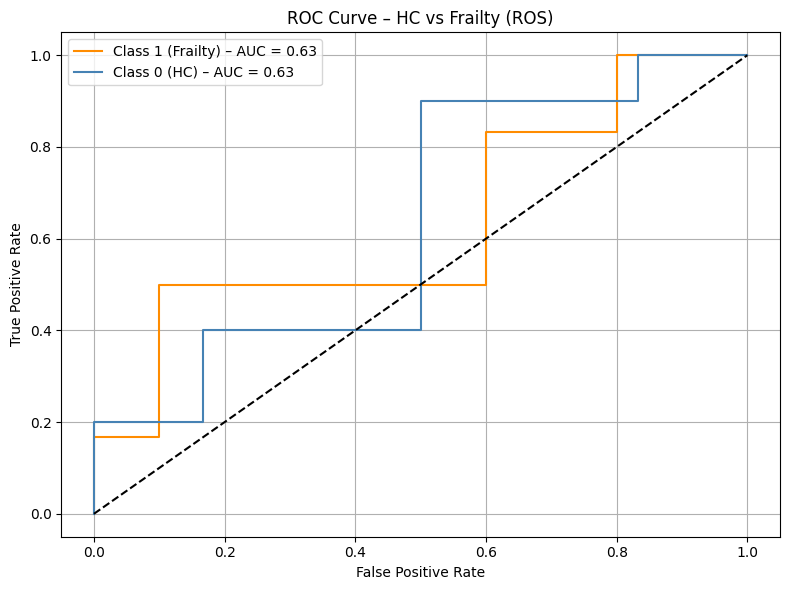

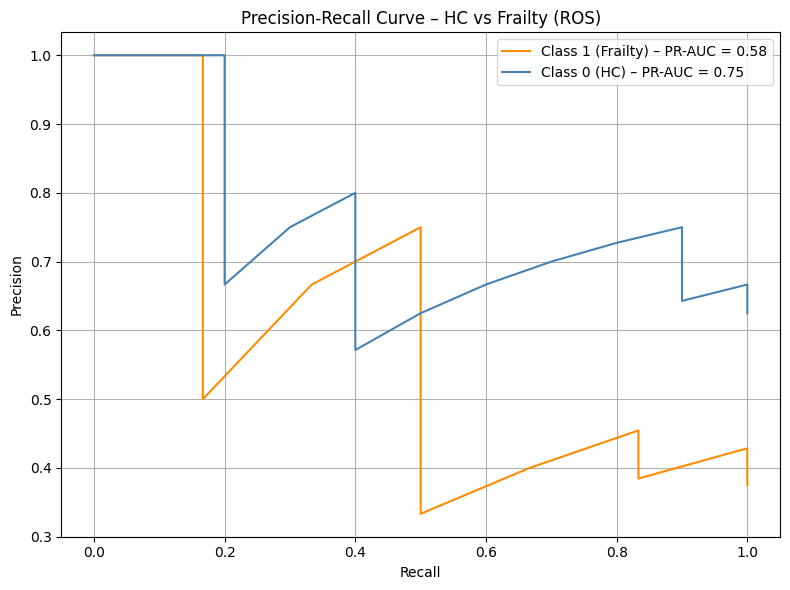

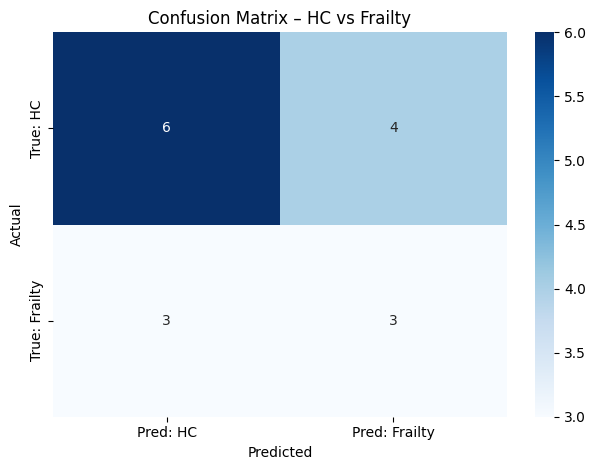

Selected non-zero coefficients
             Feature  Coefficient
3            MFPT-UD    -1.309070
4            MFPT-CS     0.758953
11    PIT (elements)     0.735772
0              TMT-B    -0.612776
9            PIT (s)    -0.552128
7   Fluency Shifting    -0.277048
8        STROOP-STIR    -0.209347


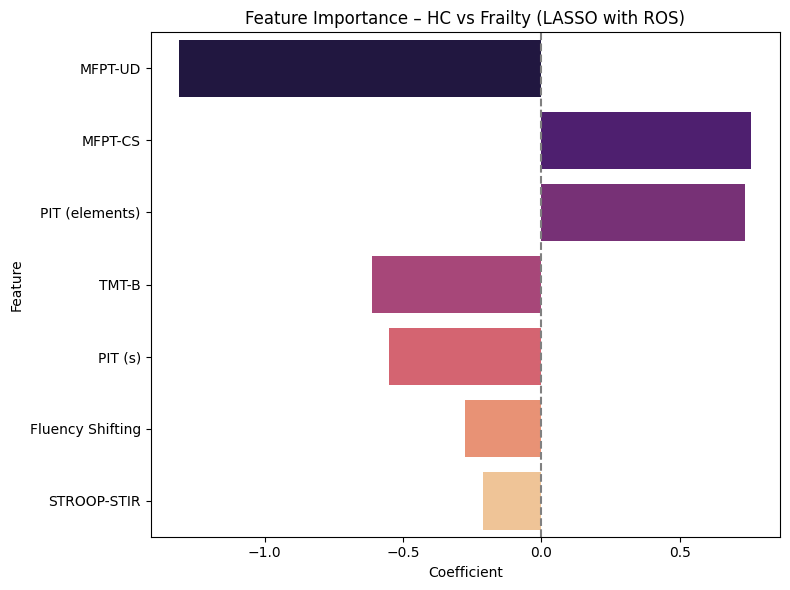

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.566 ± 0.122 | 95% CI [0.312, 0.812]
PRECISION: 0.433 ± 0.199 | 95% CI [0.000, 0.833]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.609 ± 0.157 | 95% CI [0.300, 0.900]
F1: 0.441 ± 0.177 | 95% CI [0.000, 0.750]
ROC_AUC: 0.637 ± 0.163 | 95% CI [0.312, 0.938]
PR_AUC: 0.590 ± 0.203 | 95% CI [0.162, 0.901]


In [79]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Encode frailty as the positive class and healthy controls as the negative class.
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Random Oversampling on training set
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_ros, y_train_ros)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train_ros)
y_proba_train = model.predict_proba(X_train_ros)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train_ros, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train_ros, y_pred_train)
prec_train = precision_score(y_train_ros, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_ros, y_pred_train)
f1_train = f1_score(y_train_ros, y_pred_train)
roc_auc_train = roc_auc_score(y_train_ros, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_ros, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)

# Print metrics
print("Training set metrics")
print(classification_report(y_train_ros, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Metrics dictionary for test set
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (ROS)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (ROS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with ROS)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## FF vs HC with SMOTE

Cross-Validation Results (5-fold):
Accuracy: 0.675 ± 0.091
F1-score: 0.489 ± 0.264
ROC-AUC:  0.626 ± 0.092
PR-AUC:   0.598 ± 0.106
Training set metrics
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        22
           1       0.87      0.91      0.89        22

    accuracy                           0.89        44
   macro avg       0.89      0.89      0.89        44
weighted avg       0.89      0.89      0.89        44

Accuracy: 0.886
Precision: 0.870
Recall (Sensitivity): 0.909
Specificity: 0.864
F1-score: 0.889
ROC-AUC: 0.917
PR-AUC: 0.834
Test set metrics
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.50      0.50      0.50         6

    accuracy                           0.62        16
   macro avg       0.60      0.60      0.60        16
weighted avg       0.62      0.62      0.62        16

Accuracy: 0.625
Precision: 0.500
Recall (Sensitivity

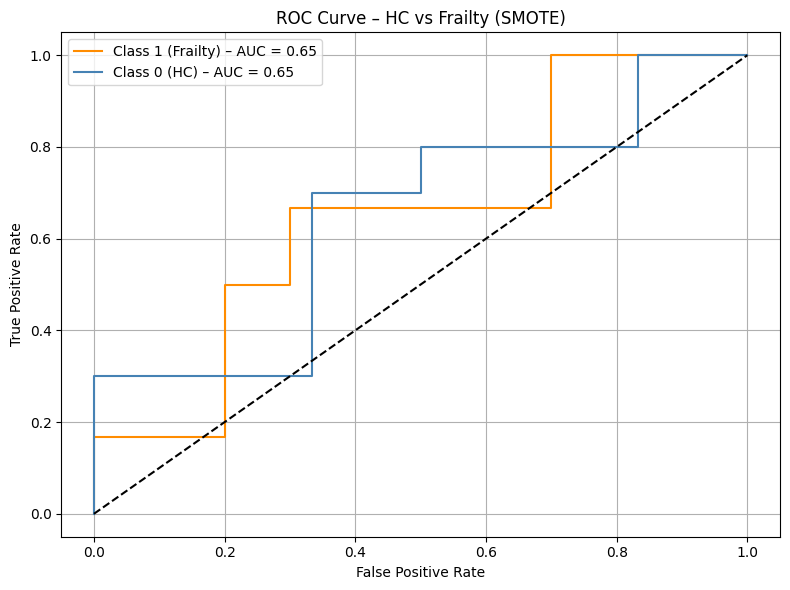

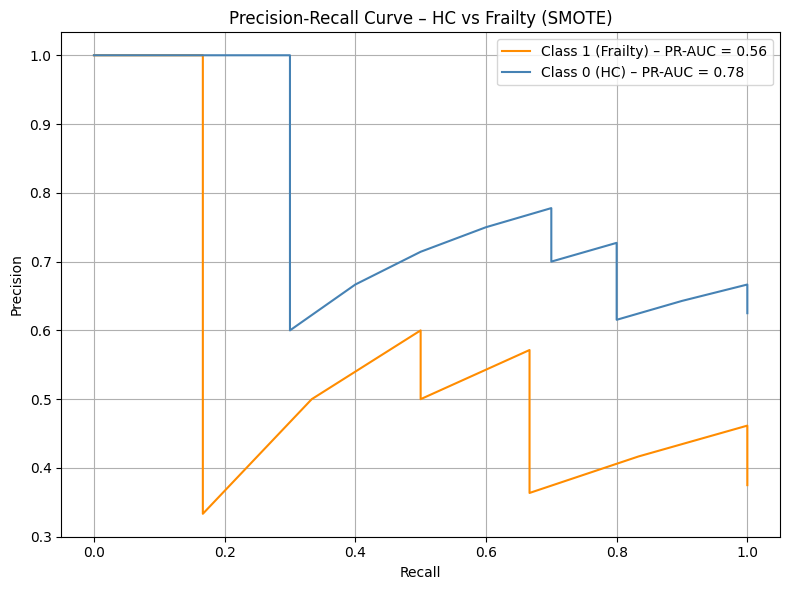

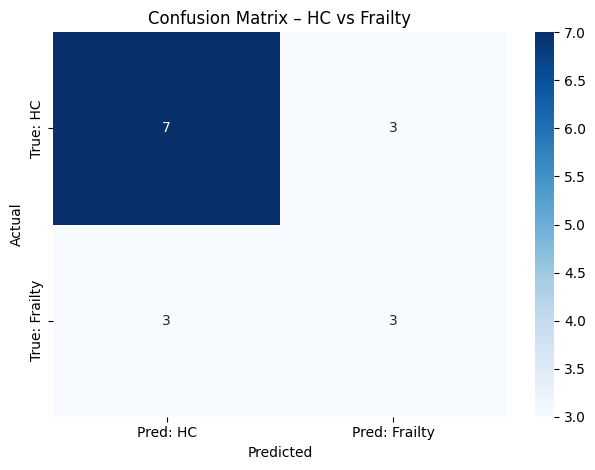

Selected non-zero coefficients
             Feature  Coefficient
3            MFPT-UD    -1.191616
4            MFPT-CS     0.702811
8        STROOP-STIR    -0.578873
9            PIT (s)    -0.523119
7   Fluency Shifting    -0.446036
0              TMT-B    -0.438848
11    PIT (elements)     0.435985
5          Fluency S     0.064574


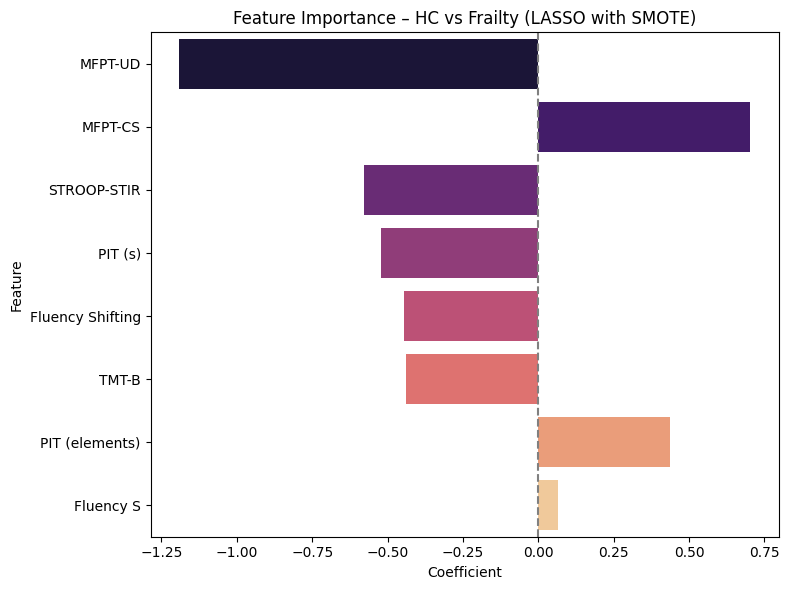

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.623 ± 0.123 | 95% CI [0.375, 0.875]
PRECISION: 0.497 ± 0.218 | 95% CI [0.000, 0.875]
RECALL: 0.496 ± 0.225 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.700 ± 0.146 | 95% CI [0.400, 0.925]
F1: 0.474 ± 0.189 | 95% CI [0.000, 0.800]
ROC_AUC: 0.653 ± 0.157 | 95% CI [0.333, 0.927]
PR_AUC: 0.564 ± 0.201 | 95% CI [0.161, 0.916]


In [80]:
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Feature set
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Encode frailty as the positive class and healthy controls as the negative class.
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply SMOTE on training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train_smote, y_train_smote)

# Predictions on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Metrics on test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# Predictions on training set
y_pred_train = model.predict(X_train_smote)
y_proba_train = model.predict_proba(X_train_smote)[:, 1]

# Confusion matrix train
cm_train = confusion_matrix(y_train_smote, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
specificity_train = tn_tr / (tn_tr + fp_tr)

# Metrics on training set
acc_train = accuracy_score(y_train_smote, y_pred_train)
prec_train = precision_score(y_train_smote, y_pred_train, zero_division=0)
rec_train = recall_score(y_train_smote, y_pred_train)
f1_train = f1_score(y_train_smote, y_pred_train)
roc_auc_train = roc_auc_score(y_train_smote, y_proba_train)
precision_vals_train, recall_vals_train, _ = precision_recall_curve(y_train_smote, y_proba_train)
pr_auc_train = auc(recall_vals_train, precision_vals_train)


print("Training set metrics")
print(classification_report(y_train_smote, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall (Sensitivity): {rec_train:.3f}")
print(f"Specificity: {specificity_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")


print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Metrics dictionary (test)
metrics_dict = {
    "Model": "HC vs Frailty – LASSO (SMOTE)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

try:
    all_model_results.append(metrics_dict)
except NameError:
    all_model_results = [metrics_dict]

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (HC) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
prec1, rec1, _ = precision_recall_curve(y_test, y_proba)
prec0, rec0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec1, prec1, label=f"Class 1 (Frailty) – PR-AUC = {auc(rec1, prec1):.2f}", color='darkorange')
plt.plot(rec0, prec0, label=f"Class 0 (HC) – PR-AUC = {auc(rec0, prec0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – HC vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: HC", "Pred: Frailty"],
            yticklabels=["True: HC", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – HC vs Frailty")
plt.tight_layout()
plt.show()

# Coefficients (non-zero)
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef[coef['Coefficient'] != 0]
coef['AbsCoef'] = coef['Coefficient'].abs()
coef = coef.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Feature Importance – HC vs Frailty (LASSO with SMOTE)')
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "roc_auc": [],
    "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The best-performing model for HC vs Frailty classification is the one without resampling. The unbalanced model had the highest precision, F1 and PR-AUC, at equal recall, proving more effective in distinguishing HC from frailty.

### FF vs HC: full model compared with no-PIT model

Metric Comparison – HC vs Frailty (No Resampling)
             Accuracy  Precision  Recall (Sensitivity)  Specificity   F1  \
With PIT        0.625        0.5                   0.5          0.7  0.5   
Without PIT     0.625        0.5                   0.5          0.7  0.5   

             ROC-AUC  PR-AUC  
With PIT       0.600   0.634  
Without PIT    0.567   0.519  


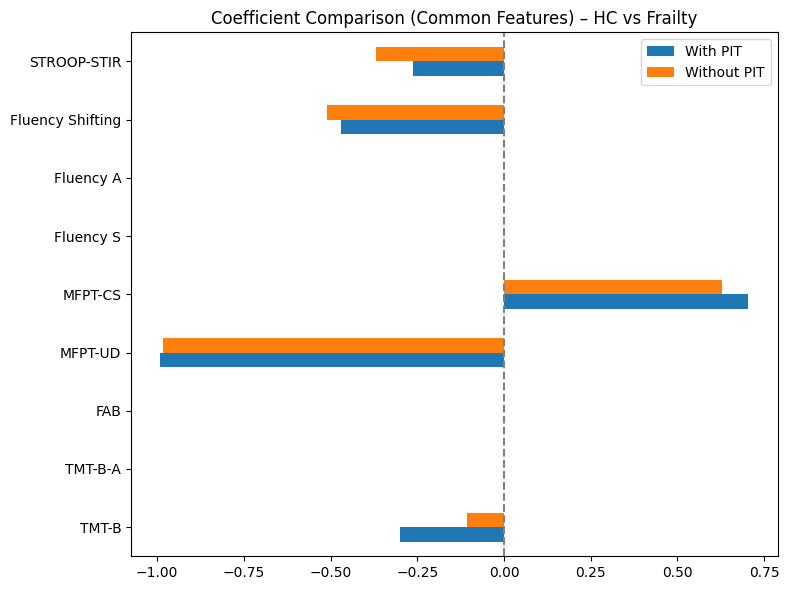

In [81]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

X_full = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                        'Fluency S', 'Fluency A', 'Fluency Shifting',
                        'STROOP-STIR'] + pit_features]

# Feature set without PIT
X_nopit = X_full.drop(columns=pit_features)

# Encode frailty as the positive class and healthy controls as the negative class.
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Same split for both models
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Train models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_full.fit(X_train_f, y_train)
model_nopit.fit(X_train_np, y_train)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metric function
def get_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': sensitivity,
        'Specificity': specificity,
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall_vals, precision_vals)
    }

# Compare results
results = pd.DataFrame({
    'With PIT': get_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': get_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print("Metric Comparison – HC vs Frailty (No Resampling)")
print(results)

# Extract coefficients
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

# Common features only
common_features = [col for col in coef_np.index if col in coef_f.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

# Plot
df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Coefficient Comparison (Common Features) – HC vs Frailty")
plt.tight_layout()
plt.show()


### Permutation importance: FF vs HC

In [82]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter only HC and Frailty
df_hc_Frailty = df_n[df_n['group'].isin(['HC', 'Frailty'])].copy()

# Full feature set (with PIT)
X = df_hc_Frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                   'Fluency S', 'Fluency A', 'Fluency Shifting',
                   'STROOP-STIR'] + pit_features]

# Target
y = df_hc_Frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train LASSO Logistic Regression
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Safe ROC-AUC scorer
def safe_roc_auc(y_true, y_score):
    return roc_auc_score(y_true, y_score, multi_class="ovr", average="weighted")

roc_auc_scorer = make_scorer(
    safe_roc_auc,
    response_method="predict_proba"
)

# Permutation importance
perm_result = permutation_importance(
    estimator=model_full,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=roc_auc_scorer
)


perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
})

# Filter and sort
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered = perm_df_filtered.sort_values(by='Importance', ascending=False)

print("\nPermutation Importance (based on ROC-AUC, HC vs Frailty):")
print(perm_df_filtered)


error_bar_factor = 0.05
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * error_bar_factor

fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – HC vs Frailty",
    labels={'Importance': 'Mean decrease in ROC-AUC when feature is permuted', 'Feature': 'Feature'},
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True, autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()



Permutation Importance (based on ROC-AUC, HC vs Frailty):
             Feature  Importance       Std
9            PIT (s)    0.045556  0.072128
0              TMT-B    0.022778  0.029339
8        STROOP-STIR    0.021667  0.045164
3            MFPT-UD    0.008889  0.124628
11    PIT (elements)   -0.014444  0.087107
4            MFPT-CS   -0.028333  0.059807
7   Fluency Shifting   -0.060556  0.075827


### Selected semantic-feature model: FF vs HC

Test Set Metrics – HC vs Frailty
              precision    recall  f1-score   support

           0       0.67      0.40      0.50        10
           1       0.40      0.67      0.50         6

    accuracy                           0.50        16
   macro avg       0.53      0.53      0.50        16
weighted avg       0.57      0.50      0.50        16

Accuracy: 0.500
Precision: 0.400
Recall (Sensitivity): 0.667
Specificity: 0.400
F1-score: 0.500
ROC-AUC: 0.650
PR-AUC: 0.631
Stratified Cross-Validation (5 folds):
ACCURACY: 0.596 ± 0.113
PRECISION: 0.468 ± 0.114
RECALL: 0.600 ± 0.255
F1: 0.516 ± 0.164
ROC_AUC: 0.669 ± 0.116
AVERAGE_PRECISION: 0.584 ± 0.115
Non-zero Coefficients (LASSO):
             Feature  Coefficient
4            MFPT-CS     1.342553
3            MFPT-UD    -1.158050
11    PIT (elements)     0.570397
9            PIT (s)    -0.492241
7   Fluency Shifting    -0.446618
18           aoa_tot    -0.352661
21    Clustering_PIT    -0.324393
16    intrusions_tot    -0.2

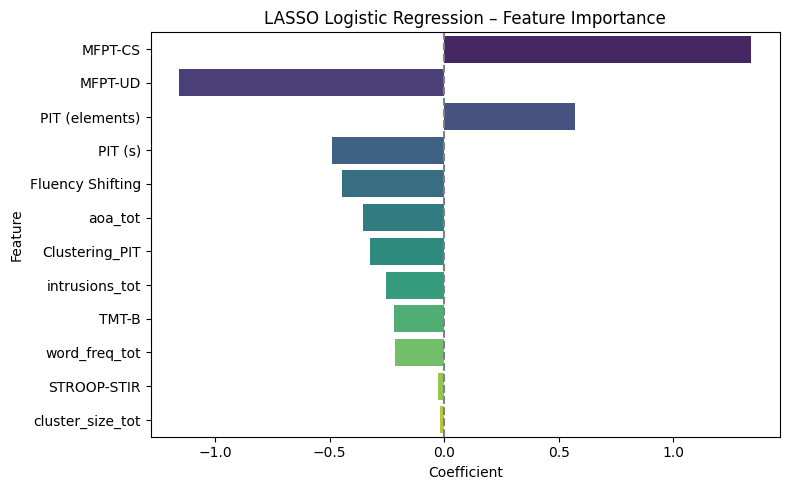

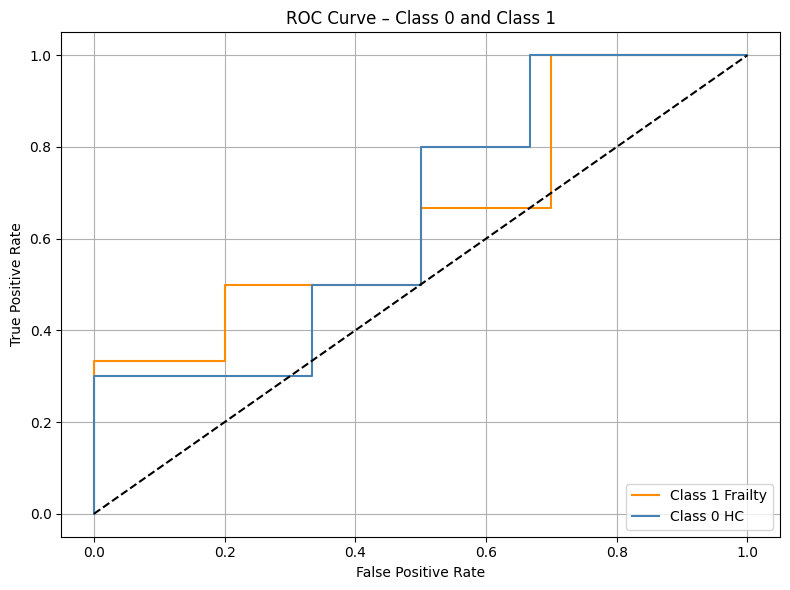

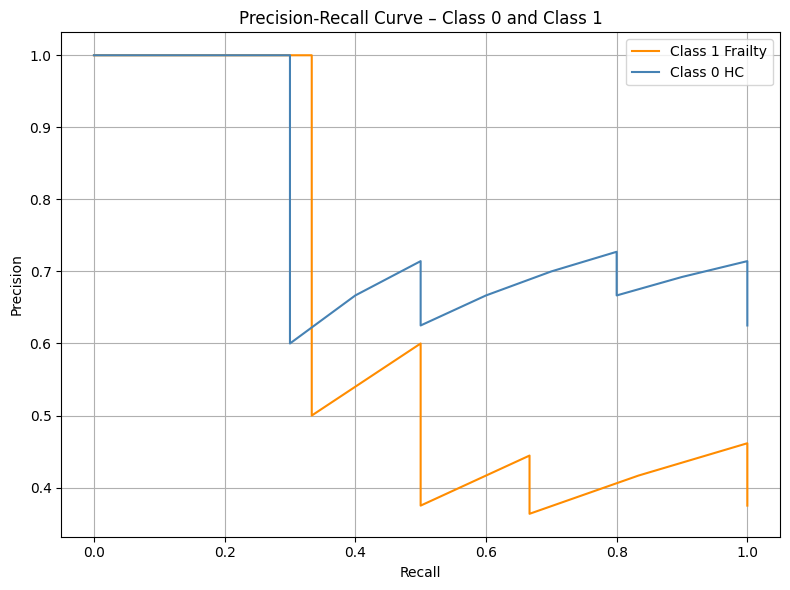

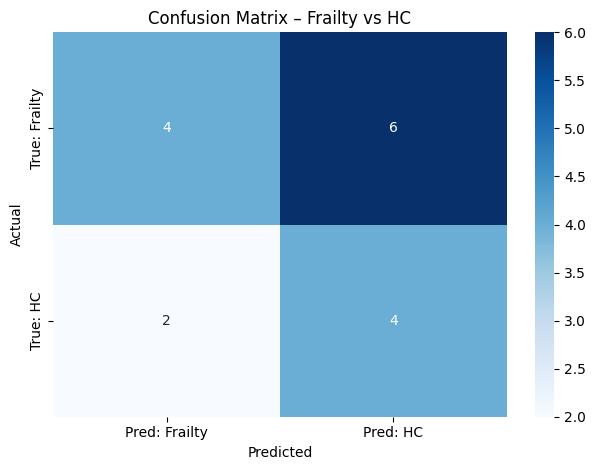

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.506 ± 0.121 | 95% CI [0.250, 0.750]
PRECISION: 0.405 ± 0.160 | 95% CI [0.111, 0.715]
RECALL: 0.666 ± 0.206 | 95% CI [0.250, 1.000]
SPECIFICITY: 0.412 ± 0.161 | 95% CI [0.100, 0.750]
F1: 0.486 ± 0.155 | 95% CI [0.167, 0.737]
ROC_AUC: 0.654 ± 0.159 | 95% CI [0.317, 0.958]
PR_AUC: 0.628 ± 0.194 | 95% CI [0.167, 0.938]


In [145]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]


df_hc_frailty = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_hc_frailty[selected_features]
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_ros, y_train_ros)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – HC vs Frailty")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ( 'ros', RandomOverSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

# SAVE non-zero LASSO subset for later robustness cells (FF vs HC)
feature_subset_fhc = coef_df["Feature"].tolist()
coef_series_fhc = pd.Series(
    coef_df["Coefficient"].values,
    index=coef_df["Feature"].values
)
print("Saved feature_subset_fhc (n features):", len(feature_subset_fhc))

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 Frailty', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 HC', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 Frailty', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 HC', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Frailty", "Pred: HC"],
            yticklabels=["True: Frailty", "True: HC"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Frailty vs HC")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP interpretation: FF vs HC

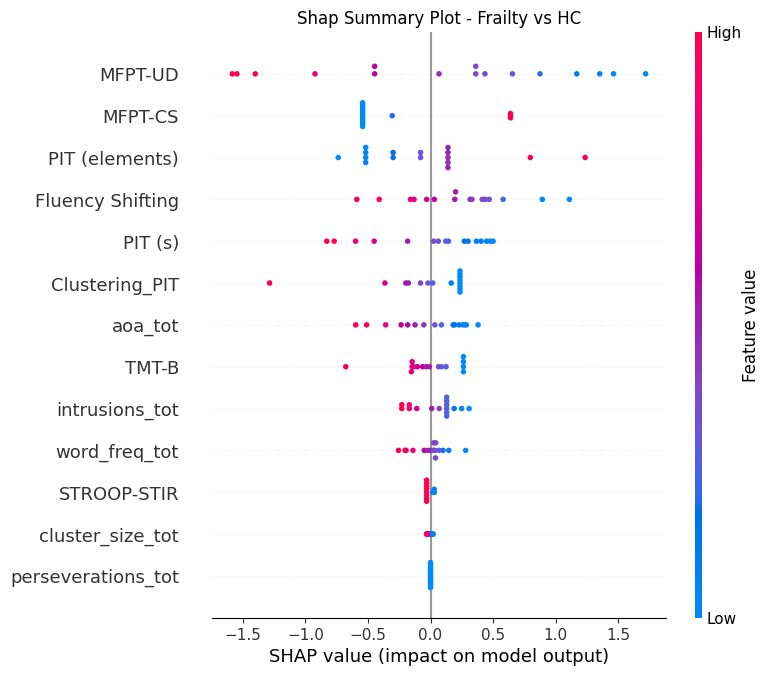

In [84]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_hc_frailty = df[df['group'].isin(['HC', 'Frailty'])].copy()
X = df_hc_frailty[selected_features]
y = df_hc_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_ros)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_ros)

# Compute SHAP values and generate the summary plot.
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - Frailty vs HC", show=False)
plt.title("Shap Summary Plot - Frailty vs HC")
plt.show()

y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Save the fitted binary model used for SHAP so it can be reused later
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}

binary_model_outputs['HC vs Frailty'] = {
    'comparison_name': 'HC vs Frailty',
    'positive_group': 'Frailty',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}


## FF vs MCI

Cross-Validation Results (5-fold):
Accuracy: 0.821 ± 0.082
F1-score: 0.556 ± 0.200
ROC-AUC:  0.884 ± 0.089
PR-AUC:   0.768 ± 0.175
Training set metrics
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        40
           1       0.67      1.00      0.80        14

    accuracy                           0.87        54
   macro avg       0.83      0.91      0.85        54
weighted avg       0.91      0.87      0.88        54

Accuracy: 0.870
Precision: 0.667
Recall: 1.000
Specificity: 0.825
F1-score: 0.800
ROC-AUC: 0.964
PR-AUC: 0.899
Test set metrics
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        18
           1       0.75      0.50      0.60         6

    accuracy                           0.83        24
   macro avg       0.80      0.72      0.75        24
weighted avg       0.82      0.83      0.82        24

Accuracy: 0.833
Precision: 0.750
Recall: 0.500
Specificity: 0.944


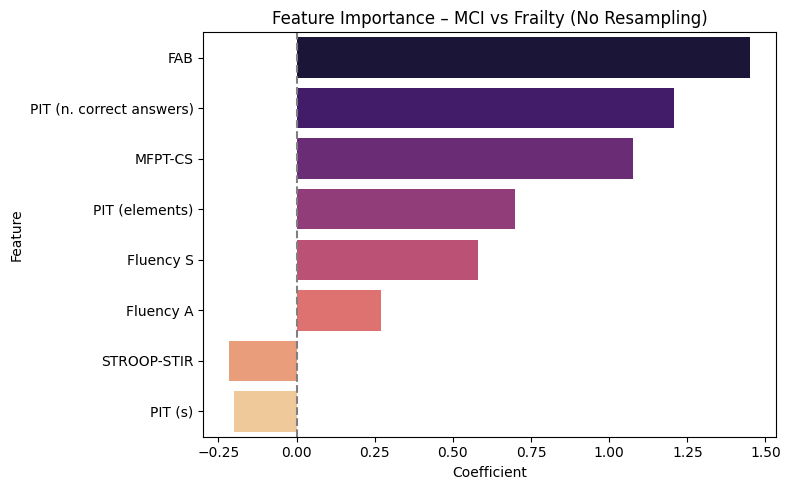

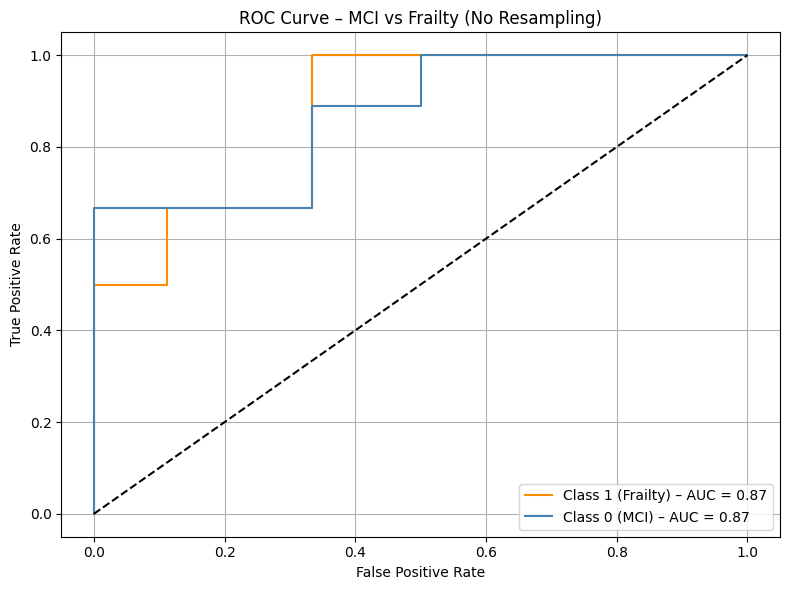

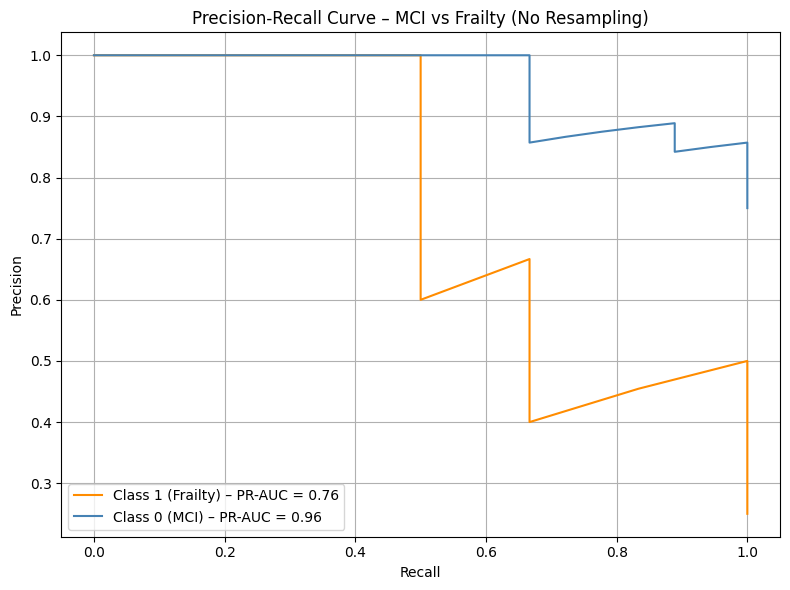

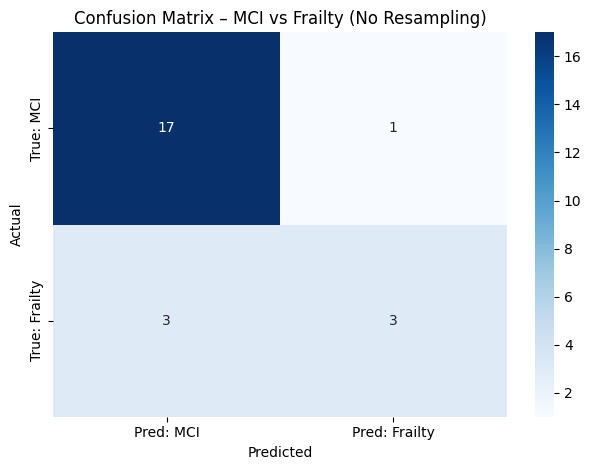

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.826 ± 0.079 | 95% CI [0.667, 0.958]
PRECISION: 0.738 ± 0.248 | 95% CI [0.000, 1.000]
RECALL: 0.502 ± 0.213 | 95% CI [0.000, 1.000]
SPECIFICITY: 0.939 ± 0.057 | 95% CI [0.812, 1.000]
F1: 0.574 ± 0.199 | 95% CI [0.000, 0.889]
ROC_AUC: 0.870 ± 0.084 | 95% CI [0.682, 1.000]
PR_AUC: 0.757 ± 0.164 | 95% CI [0.384, 1.000]


In [85]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Target
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# Predictions test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Predictions train
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

# Metrics train
cm_train = confusion_matrix(y_train, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics")
print(classification_report(y_train, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Metrics test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

print("Selected non-zero coefficients")
print(coef_df[['Feature', 'Coefficient']])

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# ROC and PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty) – AUC = {auc(fpr1, tpr1):.2f}", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI) – AUC = {auc(fpr0, tpr0):.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty) – PR-AUC = {auc(recall1, precision1):.2f}", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI) – PR-AUC = {auc(recall0, precision0):.2f}", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (No Resampling)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (No Resampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## Selected best-performing model: FF vs MCI with random undersampling

Cross-Validation Results (5-fold):
Accuracy: 0.794 ± 0.109
F1-score: 0.695 ± 0.164
ROC-AUC:  0.846 ± 0.106
PR-AUC:   0.700 ± 0.225
Training set metrics – MCI vs Frailty (Undersampling)
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.81      0.93      0.87        14

    accuracy                           0.86        28
   macro avg       0.86      0.86      0.86        28
weighted avg       0.86      0.86      0.86        28

Accuracy: 0.857
Precision: 0.812
Recall: 0.929
Specificity: 0.786
F1-score: 0.867
ROC-AUC: 0.944
PR-AUC: 0.933
Test set metrics
              precision    recall  f1-score   support

           0       0.93      0.72      0.81        18
           1       0.50      0.83      0.62         6

    accuracy                           0.75        24
   macro avg       0.71      0.78      0.72        24
weighted avg       0.82      0.75      0.77        24

Accuracy: 0.750
Precision: 0.500


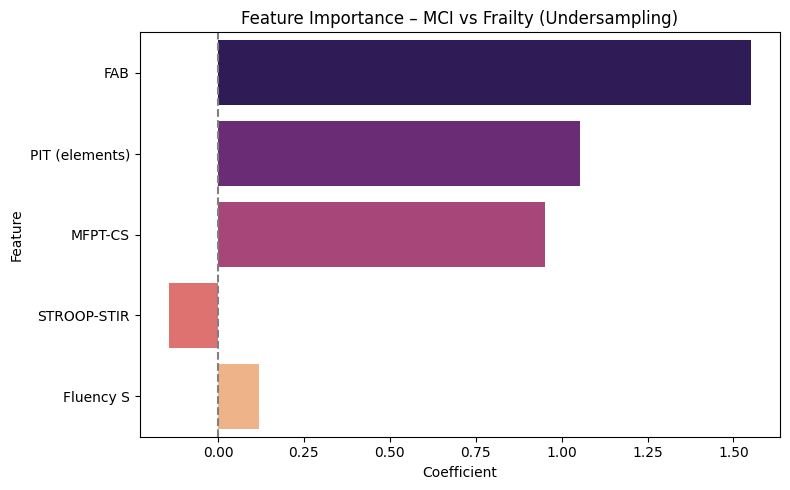

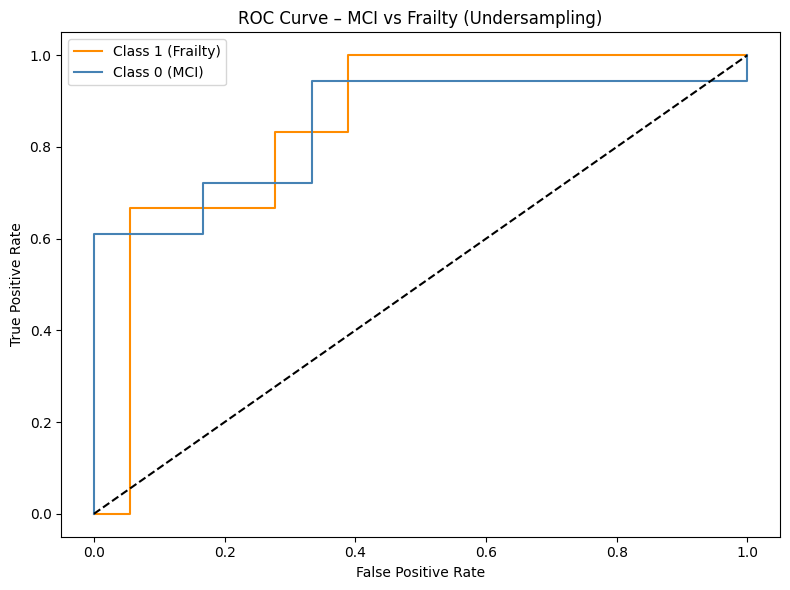

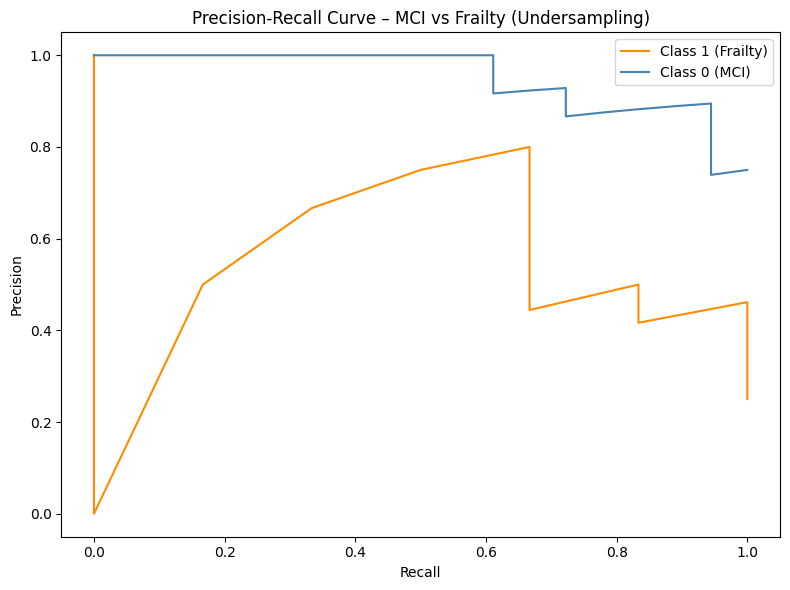

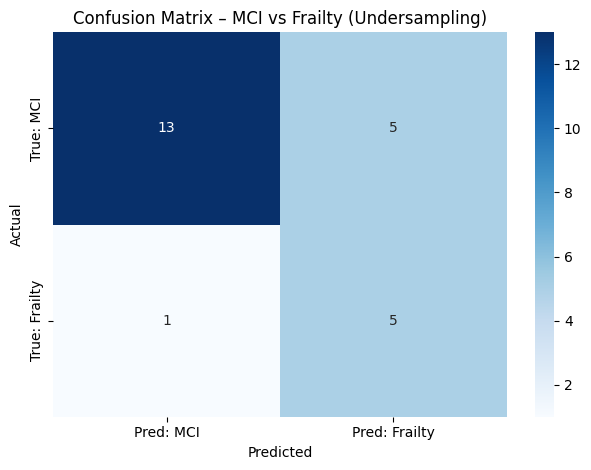

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.750 ± 0.085 | 95% CI [0.583, 0.917]
PRECISION: 0.511 ± 0.163 | 95% CI [0.182, 0.801]
RECALL: 0.830 ± 0.163 | 95% CI [0.500, 1.000]
SPECIFICITY: 0.722 ± 0.104 | 95% CI [0.526, 0.933]
F1: 0.617 ± 0.150 | 95% CI [0.266, 0.857]
ROC_AUC: 0.851 ± 0.086 | 95% CI [0.650, 1.000]
PR_AUC: 0.594 ± 0.224 | 95% CI [0.189, 1.000]


In [86]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('ros', RandomUnderSampler(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train_rus)
y_proba_train = model.predict_proba(X_train_rus)[:, 1]

# Metriche training
cm_train = confusion_matrix(y_train_rus, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train_rus, y_pred_train)
prec_train = precision_score(y_train_rus, y_pred_train)
f1_train = f1_score(y_train_rus, y_pred_train)
roc_auc_train = roc_auc_score(y_train_rus, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train_rus, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (Undersampling)")
print(classification_report(y_train_rus, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (Undersampling)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


## FF vs MCI with SMOTE

Cross-Validation Results (5-fold):
Accuracy: 0.808 ± 0.087
F1-score: 0.644 ± 0.153
ROC-AUC:  0.877 ± 0.105
PR-AUC:   0.746 ± 0.223
Training set metrics – MCI vs Frailty (SMOTE)
              precision    recall  f1-score   support

           0       0.97      0.85      0.91        40
           1       0.87      0.97      0.92        40

    accuracy                           0.91        80
   macro avg       0.92      0.91      0.91        80
weighted avg       0.92      0.91      0.91        80

Accuracy: 0.912
Precision: 0.867
Recall: 0.975
Specificity: 0.850
F1-score: 0.918
ROC-AUC: 0.972
PR-AUC: 0.967
Test set metrics
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        18
           1       0.67      0.33      0.44         6

    accuracy                           0.79        24
   macro avg       0.74      0.64      0.66        24
weighted avg       0.77      0.79      0.76        24

Accuracy: 0.792
Precision: 0.667
Recall: 

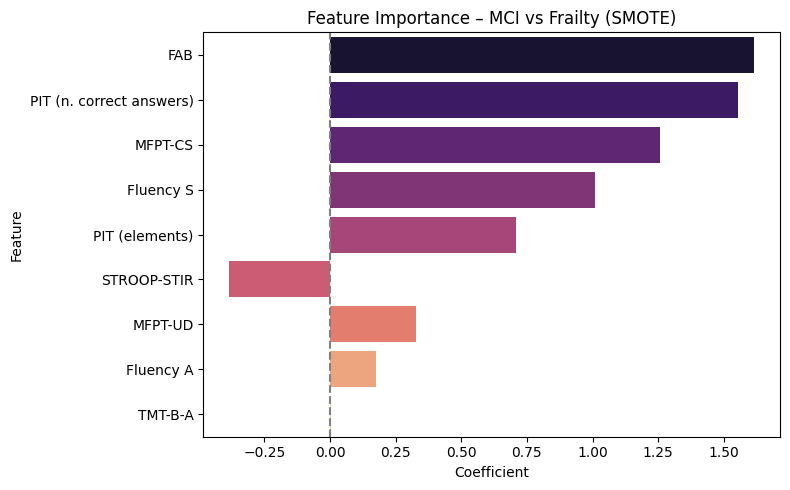

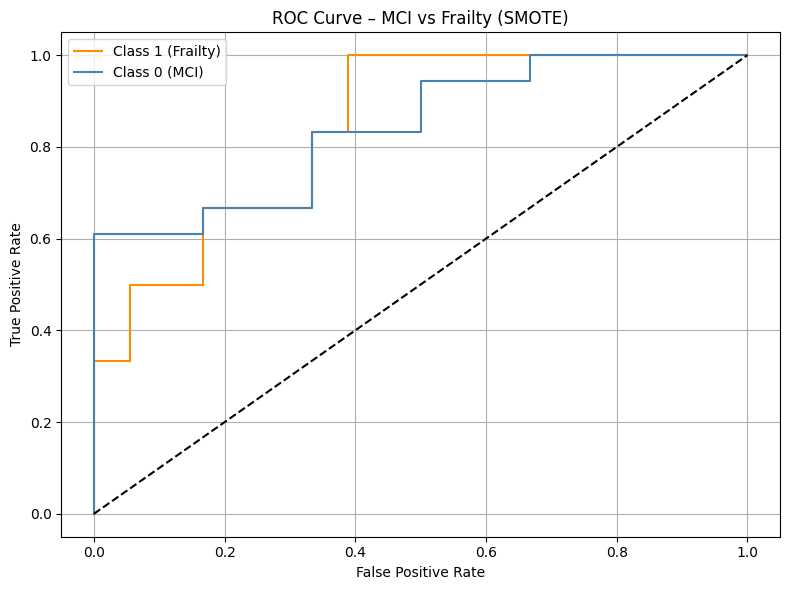

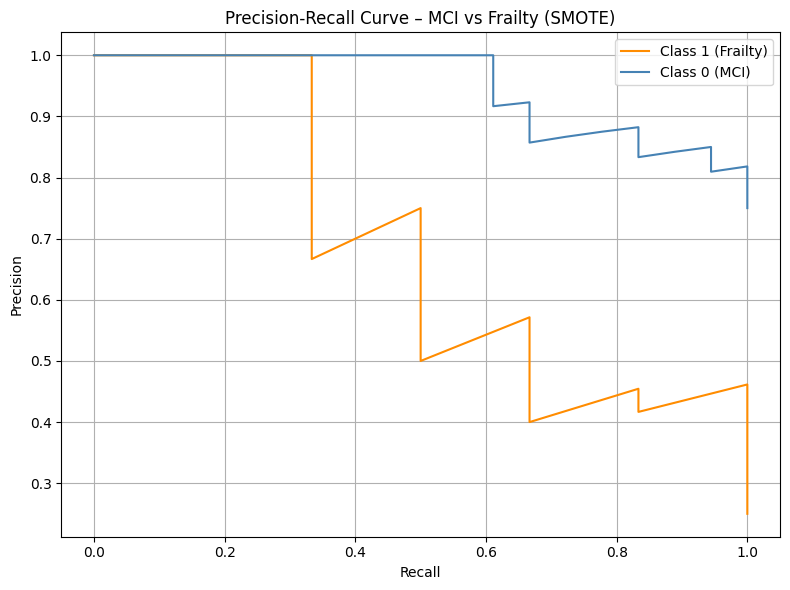

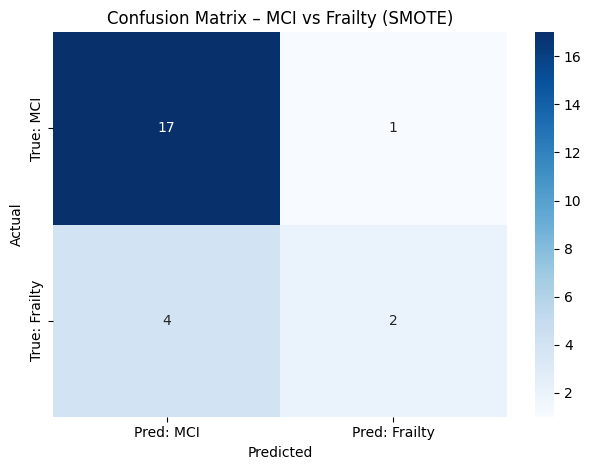

Bootstrapped test set metrics (mean ± std) with 95% CI
ACCURACY: 0.784 ± 0.085 | 95% CI [0.625, 0.917]
PRECISION: 0.636 ± 0.325 | 95% CI [0.000, 1.000]
RECALL: 0.337 ± 0.209 | 95% CI [0.000, 0.750]
SPECIFICITY: 0.939 ± 0.057 | 95% CI [0.812, 1.000]
F1: 0.418 ± 0.223 | 95% CI [0.000, 0.800]
ROC_AUC: 0.841 ± 0.090 | 95% CI [0.648, 0.983]
PR_AUC: 0.681 ± 0.187 | 95% CI [0.207, 0.955]


In [87]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Features
X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

print("Cross-Validation Results (5-fold):")
print(f"Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}")
print(f"F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC:  {np.mean(roc_auc_scores):.3f} ± {np.std(roc_auc_scores):.3f}")
print(f"PR-AUC:   {np.mean(pr_auc_scores):.3f} ± {np.std(pr_auc_scores):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_sm, y_train_sm)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Training
y_pred_train = model.predict(X_train_sm)
y_proba_train = model.predict_proba(X_train_sm)[:, 1]

cm_train = confusion_matrix(y_train_sm, y_pred_train)
tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
spec_train = tn_tr / (tn_tr + fp_tr)
rec_train = tp_tr / (tp_tr + fn_tr)
acc_train = accuracy_score(y_train_sm, y_pred_train)
prec_train = precision_score(y_train_sm, y_pred_train)
f1_train = f1_score(y_train_sm, y_pred_train)
roc_auc_train = roc_auc_score(y_train_sm, y_proba_train)
prec_vals_train, rec_vals_train, _ = precision_recall_curve(y_train_sm, y_proba_train)
pr_auc_train = auc(rec_vals_train, prec_vals_train)

print("Training set metrics – MCI vs Frailty (SMOTE)")
print(classification_report(y_train_sm, y_pred_train))
print(f"Accuracy: {acc_train:.3f}")
print(f"Precision: {prec_train:.3f}")
print(f"Recall: {rec_train:.3f}")
print(f"Specificity: {spec_train:.3f}")
print(f"F1-score: {f1_train:.3f}")
print(f"ROC-AUC: {roc_auc_train:.3f}")
print(f"PR-AUC: {pr_auc_train:.3f}")

# Test
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
rec = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_vals, prec_vals)

print("Test set metrics")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Coefficienti
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Feature Importance – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# ROC & PR curves
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(fpr0, tpr0, label=f"Class 0 (MCI)", color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label=f"Class 1 (Frailty)", color='darkorange')
plt.plot(recall0, precision0, label=f"Class 0 (MCI)", color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MCI vs Frailty (SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: MCI", "Pred: Frailty"],
            yticklabels=["True: MCI", "True: Frailty"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MCI vs Frailty (SMOTE)")
plt.tight_layout()
plt.show()

# Bootstrapping
n_iterations = 1000
rng = np.random.RandomState(42)
boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for _ in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0
    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped test set metrics (mean ± std) with 95% CI")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


The best-performing model for MCI vs Frailty classification is the one with random undersampling (because it maximizes recall).

### FF vs MCI: full model compared with no-PIT model

Metric Comparison – MCI vs Frailty (Undersampling)
             Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-score  \
With PIT        0.750      0.500                 0.833        0.722     0.625   
Without PIT     0.792      0.556                 0.833        0.778     0.667   

             ROC-AUC  PR-AUC  
With PIT       0.852   0.538  
Without PIT    0.880   0.658  


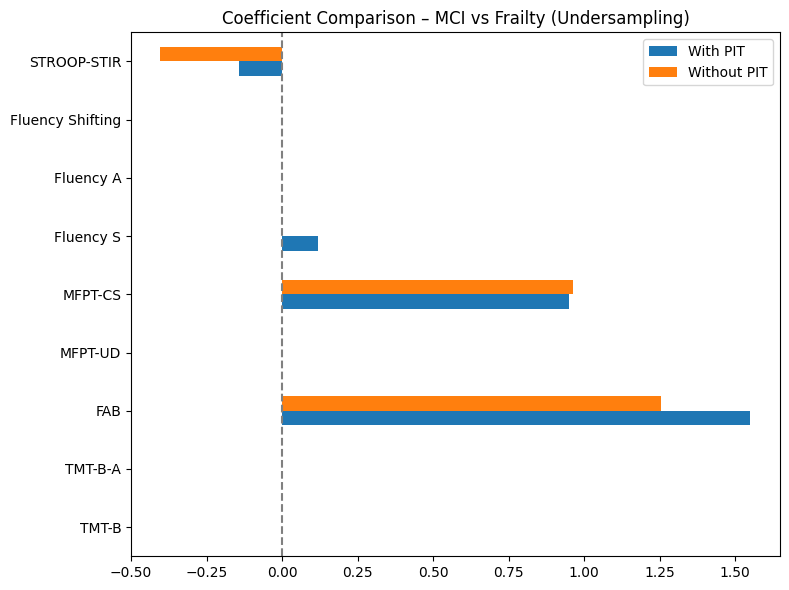

In [ ]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']

# Filter dataset for FF vs MCI
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

# Feature sets
X_full = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                         'Fluency S', 'Fluency A', 'Fluency Shifting',
                         'STROOP-STIR'] + pit_features]
X_nopit = X_full.drop(columns=pit_features)

# Binary target
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.3, random_state=42)
X_train_np, X_test_np = X_nopit.loc[X_train_f.index], X_nopit.loc[X_test_f.index]

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_f_rus, y_train_rus = rus.fit_resample(X_train_f, y_train)
X_train_np_rus, _ = rus.fit_resample(X_train_np, y_train)

# Train models
model_full = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model_nopit = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')

model_full.fit(X_train_f_rus, y_train_rus)
model_nopit.fit(X_train_np_rus, y_train_rus)

# Predictions
y_pred_f = model_full.predict(X_test_f)
y_proba_f = model_full.predict_proba(X_test_f)[:, 1]

y_pred_np = model_nopit.predict(X_test_np)
y_proba_np = model_nopit.predict_proba(X_test_np)[:, 1]

# Metric function
def get_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': auc(recall_vals, precision_vals)
    }

# Metric comparison
results = pd.DataFrame({
    'With PIT': get_metrics(y_test, y_pred_f, y_proba_f),
    'Without PIT': get_metrics(y_test, y_pred_np, y_proba_np)
}).T.round(3)

print("Metric Comparison – MCI vs Frailty (Undersampling)")
print(results)

# Coefficients
coef_f = pd.Series(model_full.coef_[0], index=X_full.columns)
coef_np = pd.Series(model_nopit.coef_[0], index=X_nopit.columns)

# Common coefficients
common_features = [col for col in coef_np.index if col in coef_f.index]
df_coef_compare = pd.DataFrame({
    'With PIT': coef_f[common_features],
    'Without PIT': coef_np[common_features]
})

# Plot
df_coef_compare.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='gray', linestyle='--')
plt.title("Coefficient Comparison – MCI vs Frailty (Undersampling)")
plt.tight_layout()
plt.show()


### Permutation importance: FF vs MCI

In [89]:
df_mci_frailty = df_n[df_n['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[['TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
                    'Fluency S', 'Fluency A', 'Fluency Shifting',
                    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']]

# Encode frailty as the positive class and MCI as the negative class.
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Train model
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_rus, y_train_rus)

# Safe scorer
def safe_roc_auc(y_true, y_score):
    return roc_auc_score(y_true, y_score, multi_class="ovr", average="weighted")

scorer = make_scorer(
    safe_roc_auc,
    response_method="predict_proba"
)

# Permutation importance
perm_result = permutation_importance(
    estimator=model_full,
    X=X_test_f,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=scorer
)


perm_df = pd.DataFrame({
    'Feature': X_test_f.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Filter & reduce std
threshold = 0.001
perm_df_filtered = perm_df[perm_df['Importance'].abs() > threshold].copy()
perm_df_filtered['Reduced_Std'] = perm_df_filtered['Std'] * 0.05

print("\nPermutation Importance (based on ROC-AUC, MCI vs Frailty):")
print(perm_df_filtered)


fig = px.bar(
    perm_df_filtered,
    x='Importance',
    y='Feature',
    title="Permutation Importance – MCI vs Frailty (RUS)",
    error_x='Reduced_Std',
    color='Importance',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Mean decrease in ROC-AUC when feature is permuted",
    yaxis_title="Feature",
    yaxis=dict(autorange="reversed"),
    plot_bgcolor="white"
)

fig.show()



Permutation Importance (based on ROC-AUC, MCI vs Frailty):
           Feature  Importance       Std  Reduced_Std
0              FAB    0.266975  0.133176     0.006659
1   PIT (elements)    0.010802  0.054048     0.002702
2          MFPT-CS    0.001543  0.023312     0.001166
10       Fluency S   -0.007407  0.012284     0.000614
11     STROOP-STIR   -0.008333  0.007691     0.000385


### Selected semantic-feature model: FF vs MCI

Test Set Metrics – HC vs Frailty
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.60      1.00      0.75         6

    accuracy                           0.83        24
   macro avg       0.80      0.89      0.81        24
weighted avg       0.90      0.83      0.84        24

Accuracy: 0.833
Precision: 0.600
Recall (Sensitivity): 1.000
Specificity: 0.778
F1-score: 0.750
ROC-AUC: 0.926
PR-AUC: 0.813
Stratified Cross-Validation (5 folds):
ACCURACY: 0.674 ± 0.193
PRECISION: 0.507 ± 0.259
RECALL: 0.800 ± 0.100
F1: 0.601 ± 0.211
ROC_AUC: 0.806 ± 0.124
AVERAGE_PRECISION: 0.699 ± 0.197
Non-zero Coefficients (LASSO):
                 Feature  Coefficient
2                    FAB     1.488100
8            STROOP-STIR    -0.822549
22           Density_PIT    -0.620560
6              Fluency A     0.604834
15    perseverations_tot     0.426187
4                MFPT-CS     0.382855
13  cluster_switches_tot     0.154

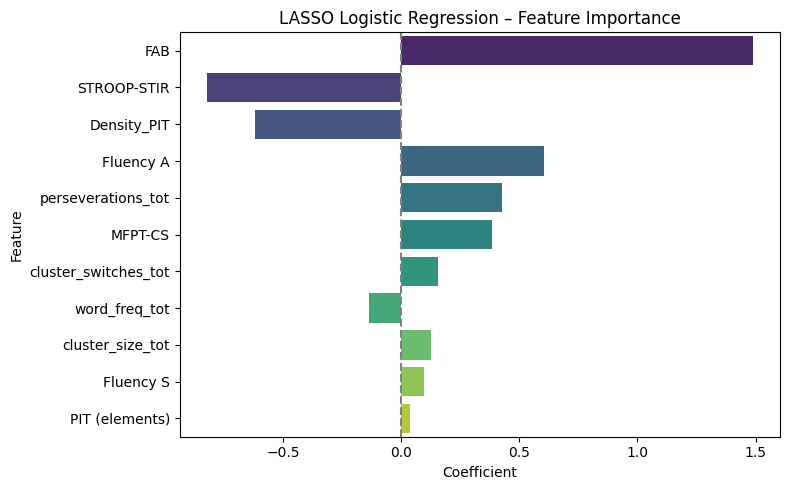

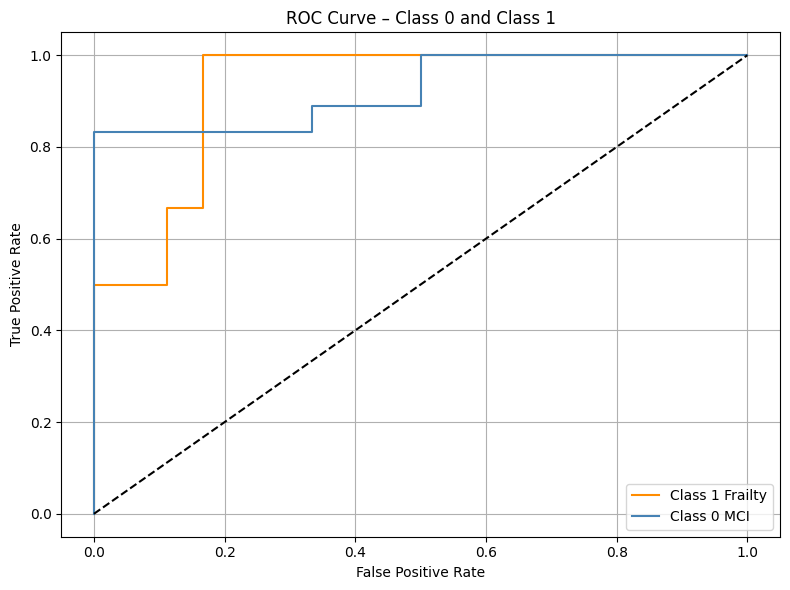

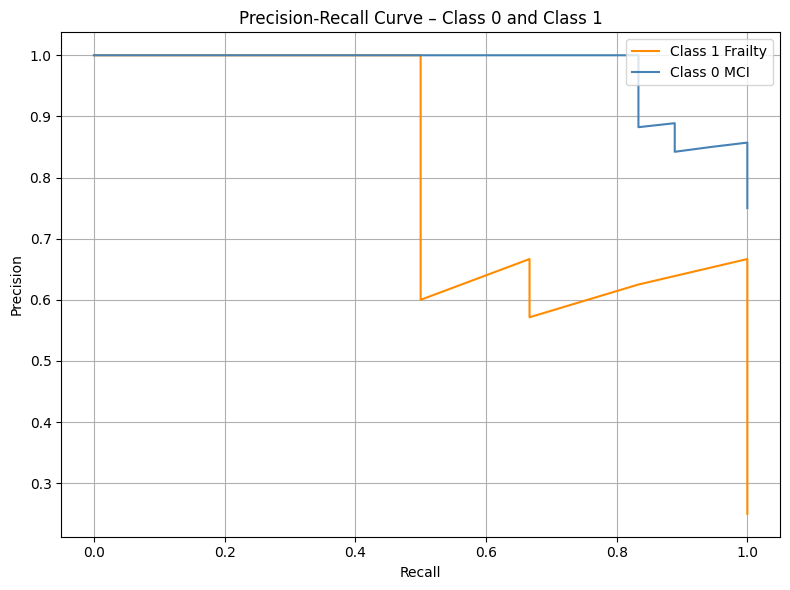

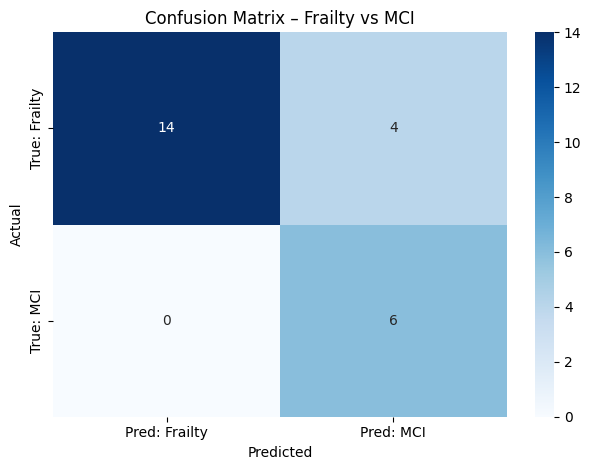

Bootstrapped metrics (mean ± std) [95% CI]:
ACCURACY: 0.831 ± 0.075 | 95% CI [0.667, 0.958]
PRECISION: 0.599 ± 0.161 | 95% CI [0.273, 0.900]
RECALL: 1.000 ± 0.000 | 95% CI [1.000, 1.000]
SPECIFICITY: 0.774 ± 0.097 | 95% CI [0.583, 0.947]
F1: 0.736 ± 0.132 | 95% CI [0.429, 0.947]
ROC_AUC: 0.924 ± 0.057 | 95% CI [0.784, 1.000]
PR_AUC: 0.806 ± 0.154 | 95% CI [0.409, 1.000]


In [105]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_mci_frailty = df[df['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[selected_features]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_features)
])


lasso_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

lasso_pipeline.fit(X_train_rus, y_train_rus)


y_pred = lasso_pipeline.predict(X_test)
y_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

print("Test Set Metrics – HC vs Frailty")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall (Sensitivity): {rec:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Cross validation
cv_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ( 'rus', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Stratified Cross-Validation (5 folds):")
for metric in scoring:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()}: {mean:.3f} ± {std:.3f}")

# Feature importance (coefficients)
model = lasso_pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df[coef_df['Coefficient'] != 0]
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Non-zero Coefficients (LASSO):")
print(coef_df[['Feature', 'Coefficient']])

feature_subset_fvm = coef_df["Feature"].tolist()   
coef_series_fvm = pd.Series(
    coef_df["Coefficient"].values,
    index=coef_df["Feature"].values
)
print("Saved feature_subset_fvm (n features):", len(feature_subset_fvm))

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='gray', linestyle='--')
plt.title('LASSO Logistic Regression – Feature Importance')
plt.tight_layout()
plt.show()

# ROC Curve
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
fpr0, tpr0, _ = roc_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Class 1 Frailty', color='darkorange')
plt.plot(fpr0, tpr0, label='Class 0 MCI', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0 and Class 1")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# PR Curve
precision1, recall1, _ = precision_recall_curve(y_test, y_proba)
precision0, recall0, _ = precision_recall_curve(1 - y_test, 1 - y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall1, precision1, label='Class 1 Frailty', color='darkorange')
plt.plot(recall0, precision0, label='Class 0 MCI', color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Class 0 and Class 1")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Frailty", "Pred: MCI"],
            yticklabels=["True: Frailty", "True: MCI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Frailty vs MCI")
plt.tight_layout()
plt.show()

# Bootstrapping (test set)
n_iterations = 1000
rng = np.random.RandomState(42)

boot_metrics = {
    "accuracy": [], "precision": [], "recall": [], "specificity": [],
    "f1": [], "roc_auc": [], "pr_auc": []
}

for i in range(n_iterations):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred[indices]
    y_proba_b = y_proba[indices]

    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    if cm_b.shape != (2, 2):
        continue

    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0
    rec_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0

    prec_vals_b, rec_vals_b, _ = precision_recall_curve(y_true_b, y_proba_b)
    pr_auc_b = auc(rec_vals_b, prec_vals_b)

    boot_metrics["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    boot_metrics["precision"].append(precision_score(y_true_b, y_pred_b, zero_division=0))
    boot_metrics["recall"].append(rec_b)
    boot_metrics["specificity"].append(spec_b)
    boot_metrics["f1"].append(f1_score(y_true_b, y_pred_b))
    boot_metrics["roc_auc"].append(roc_auc_score(y_true_b, y_proba_b))
    boot_metrics["pr_auc"].append(pr_auc_b)

print("Bootstrapped metrics (mean ± std) [95% CI]:")
for metric, values in boot_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    ci_low = np.percentile(values, 2.5)
    ci_high = np.percentile(values, 97.5)
    print(f"{metric.upper()}: {mean_val:.3f} ± {std_val:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")


### SHAP interpretation: FF vs MCI


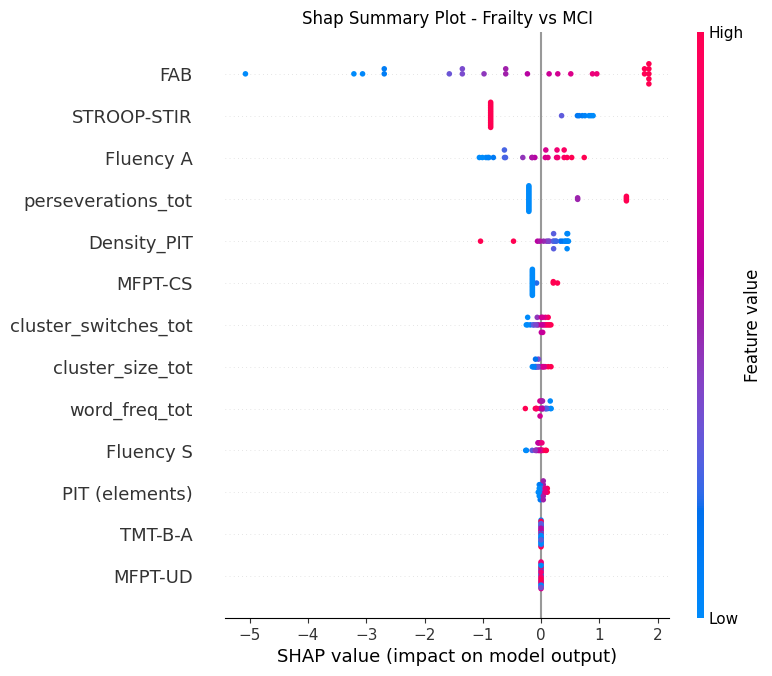

In [91]:
selected_features = [
    'TMT-B', 'TMT-B-A', 'FAB', 'MFPT-UD', 'MFPT-CS',
    'Fluency S', 'Fluency A', 'Fluency Shifting',
    'STROOP-STIR', 'PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)', 
    "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
    "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot",
    "NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
    "Entropy_PIT"
]

df_mci_frailty = df[df['group'].isin(['MCI', 'Frailty'])].copy()

X = df_mci_frailty[selected_features]
y = df_mci_frailty['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train_rus)
X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_imp = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imp)

model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train_rus)

# Compute SHAP values and generate the summary plot.
explainer = shap.LinearExplainer(model, X_train_scaled, feature_names=selected_features)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, max_display=13,title = "Shap Summary Plot - Frailty vs MCI", show=False)
plt.title("Shap Summary Plot - Frailty vs MCI")
plt.show()

y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Save the fitted binary model used for SHAP so it can be reused later
if 'binary_model_outputs' not in globals():
    binary_model_outputs = {}

binary_model_outputs['MCI vs Frailty'] = {
    'comparison_name': 'MCI vs Frailty',
    'positive_group': 'Frailty',
    'features': selected_features.copy(),
    'subset_index': X.index.copy(),
    'X_test': X_test.copy(),
    'y_test': y_test.copy(),
    'test_index': X_test.index.copy(),
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'test_probabilities': pd.Series(y_proba, index=X_test.index, name='pred_prob')
}


## Model probabilities compared with a neuropsychological reference

## Clinically derived reference validation

This section evaluates whether the predicted probabilities generated by each model align with a clinically derived neuropsychological reference.

Sections labelled as selected best-performing models correspond to the models previously marked with a leading plus sign; the label is made explicit here for publication readability.

For each binary contrast, the workflow defines a contrast-specific reference label, evaluates the corresponding logistic-regression model on the selected feature set, fits an OLS model between predicted probability and reference label, and visualizes the relationship with a regression plot.

The same dataframe and saved model outputs are reused so that the reference analysis remains consistent with the predictive results.

In [ ]:
# Reuse the analysis dataframe and fitted binary models from the ML and SHAP sections.
if 'df' not in globals():
    raise NameError("The dataframe 'df' is not available. Run the ML section cells first.")

if 'binary_model_outputs' not in globals():
    raise NameError(
        "The dictionary 'binary_model_outputs' is not available. Run the three binary SHAP cells first "
        "(MCI vs All, HC vs Frailty, MCI vs Frailty)."
    )

required_comparisons = ['MCI vs All', 'HC vs Frailty', 'MCI vs Frailty']
missing_comparisons = [c for c in required_comparisons if c not in binary_model_outputs]
if missing_comparisons:
    raise NameError(f"Missing saved SHAP model outputs for: {missing_comparisons}")

test_z_scores = [
    'MMSE', 'Corsi D.', 'Digit D.', 'Supraspan',
    'TMT-A', 'TMT-B', 'TMT-B-A', 'Rey_copy', 'Rey_Imm', 'Rey_diff', 'Rey_oblio',
    'Rac Im', 'Rac Diff', 'Rac Oblio', 'FAB',
    'MFPT-UD', 'MFPT-CS', 'Fluency F.', 'Fluency S', 'Fluency A', 'Fluency Shifting',
    'GDS', 'ADL', 'IADL'
]

# Tests where higher raw score means worse performance: invert sign after z-standardization
higher_is_worse = {'TMT-A', 'TMT-B', 'TMT-B-A', 'GDS'}

available_tests = [c for c in test_z_scores if c in df.columns]
missing_tests = [c for c in test_z_scores if c not in df.columns]
if missing_tests:
    print(f'Warning: missing tests for z-score computation: {missing_tests}')

z_cols = []
for col in available_tests:
    s = pd.to_numeric(df[col], errors='coerce')
    std = s.std(ddof=0)
    z_col = f'{col}__z'
    if pd.isna(std) or std == 0:
        df[z_col] = np.nan
    else:
        z = (s - s.mean()) / std
        if col in higher_is_worse:
            z = -z
        df[z_col] = z
    z_cols.append(z_col)

deficit_cutoff = -1.5
df['n_deficient'] = (df[z_cols] <= deficit_cutoff).sum(axis=1)
df['TFI_total'] = df[['TFI- variabili fisiche ', 'TFI- variabili psicologiche', 'TFI- sociali']].sum(axis=1)


def run_saved_model_vs_reference(comparison_name, reference_col, y_label, title):
    saved = binary_model_outputs[comparison_name]

    pred_df = pd.DataFrame({
        'pred_prob': saved['test_probabilities']
    })

    work = df.loc[saved['test_index']].copy()
    work = work.join(pred_df, how='left')
    work[reference_col] = pd.to_numeric(work[reference_col], errors='coerce')

    ols_df = work[[reference_col, 'pred_prob']].dropna().copy()

    print(f'\n{comparison_name}')
    print(f"Test-set cases from the saved SHAP model: {len(work)}")
    print(f"Valid clinically derived reference cases: {len(ols_df)}")
    print(f"Reference distribution: {work[reference_col].value_counts(dropna=False).to_dict()}")

    X_ols = sm.add_constant(ols_df['pred_prob'])
    ols_model = sm.OLS(ols_df[reference_col], X_ols).fit()
    print(ols_model.summary())

    plt.figure(figsize=(6, 4))
    sns.regplot(
        data=ols_df,
        x='pred_prob',
        y=reference_col,
        scatter_kws={'alpha': 0.75},
        line_kws={'linewidth': 2}
    )
    plt.xlabel('Predicted probability from the saved binary model')
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return {
        'comparison': comparison_name,
        'n_test': len(work),
        'n_reference_valid': len(ols_df),
        'ols_model': ols_model,
        'predictions': work,
        'saved_model_bundle': saved
    }


### MCI vs All: reference validation


MCI vs All
Test-set cases from the saved SHAP model: 33
Valid clinically derived reference cases: 33
Reference distribution: {1.0: 18, 0.0: 15}
                              OLS Regression Results                              
Dep. Variable:     clinical_reference_MCI   R-squared:                       0.276
Model:                                OLS   Adj. R-squared:                  0.252
Method:                     Least Squares   F-statistic:                     11.80
Date:                    Tue, 19 May 2026   Prob (F-statistic):            0.00171
Time:                            09:57:34   Log-Likelihood:                -18.493
No. Observations:                      33   AIC:                             40.99
Df Residuals:                          31   BIC:                             43.98
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    

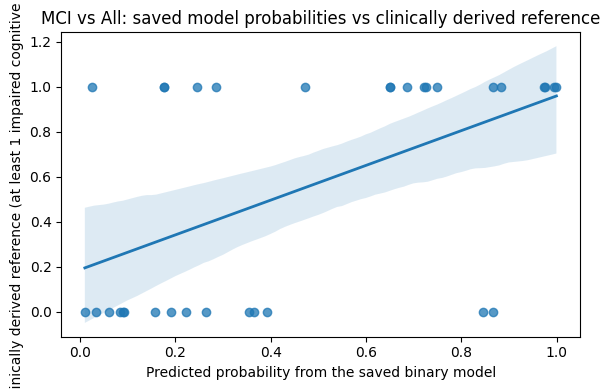

{'comparison': 'MCI vs All',
 'n_test': 33,
 'n_reference_valid': 33,
 'ols_model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f6ba44402d0>,
 'predictions':       id    group Gender  Age  Education level  MMSE  Corsi D.  Digit D.  \
 90    92  Frailty      F   76               13  30.0      5.24      5.27   
 108  110  Frailty      F   76                8  30.0      4.50      6.49   
 83    85       HC      F   73                8  27.4      4.36      5.53   
 34    35       HC      M   65               13  30.0      5.00      6.02   
 81    83      MCI      M   71               13  22.7      7.11      6.30   
 6      7      MCI      F   80                8  24.7      3.66      5.65   
 98   100       HC      M   71               13  26.7      5.11      7.13   
 97    99      MCI      F   85                8  29.8      4.87      5.87   
 46    47      MCI      F   66               16  24.2      3.00      6.02   
 105  107  Frailty      M   75               18  

In [93]:
df_mci_all = df.copy()
df_mci_all['clinical_reference_MCI'] = (df_mci_all['n_deficient'] >= 1).astype(float)
df['clinical_reference_MCI'] = df_mci_all['clinical_reference_MCI']

mci_all_results = run_saved_model_vs_reference(
    comparison_name='MCI vs All',
    reference_col='clinical_reference_MCI',
    y_label='Clinically derived reference (at least 1 impaired cognitive test)',
    title='MCI vs All: saved model probabilities vs clinically derived reference'
)

mci_all_results


### FF vs HC: reference validation


HC vs Frailty
Test-set cases from the saved SHAP model: 16
Valid clinically derived reference cases: 14
Reference distribution: {0.0: 10, 1.0: 4, nan: 2}
                                  OLS Regression Results                                  
Dep. Variable:     clinical_reference_HCvsFrailty   R-squared:                       0.030
Model:                                        OLS   Adj. R-squared:                 -0.051
Method:                             Least Squares   F-statistic:                    0.3720
Date:                            Tue, 19 May 2026   Prob (F-statistic):              0.553
Time:                                    09:57:34   Log-Likelihood:                -8.5268
No. Observations:                              14   AIC:                             21.05
Df Residuals:                                  12   BIC:                             22.33
Df Model:                                       1                                         
Covariance Type:          

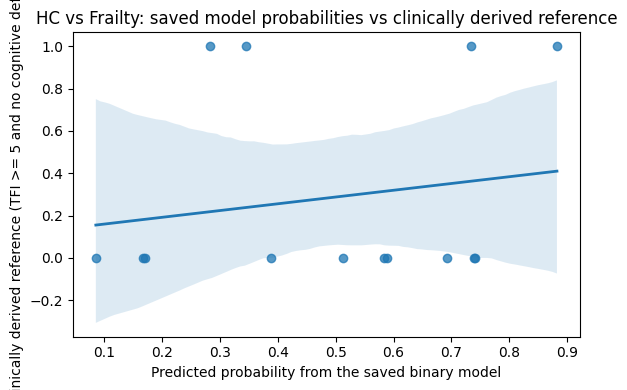

clinical_reference_HCvsFrailty
0.0    32
1.0    13
NaN     7
Name: count, dtype: int64


{'comparison': 'HC vs Frailty',
 'n_test': 16,
 'n_reference_valid': 14,
 'ols_model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f6b6150d690>,
 'predictions':       id    group Gender  Age  Education level  MMSE  Corsi D.  Digit D.  \
 107  109       HC      M   74               17  24.7      3.94      6.99   
 89    91       HC      F   67               17  30.0      5.83      6.87   
 44    45       HC      M   68               18  30.0      3.83      6.87   
 83    85       HC      F   73                8  27.4      4.36      5.53   
 99   101  Frailty      F   76                8  30.0      4.50      6.49   
 73    75       HC      F   75               13  26.3      5.24      6.22   
 19    20  Frailty      F   72               13  25.7      4.11      5.13   
 34    35       HC      M   65               13  30.0      5.00      6.02   
 35    36       HC      M   70               17  24.7      4.94      5.99   
 75    77  Frailty      F   84                

In [94]:
df_hcf = df[df['group'].isin(['HC', 'Frailty'])].copy()
df_hcf['clinical_reference_HCvsFrailty'] = np.where(
    df_hcf['group'] == 'HC',
    0,
    np.where(
        (df_hcf['group'] == 'Frailty') & (df_hcf['TFI_total'] >= 5) & (df_hcf['n_deficient'] == 0),
        1,
        np.nan
    )
)
df.loc[df_hcf.index, 'clinical_reference_HCvsFrailty'] = df_hcf['clinical_reference_HCvsFrailty']

hcf_results = run_saved_model_vs_reference(
    comparison_name='HC vs Frailty',
    reference_col='clinical_reference_HCvsFrailty',
    y_label='Clinically derived reference (TFI >= 5 and no cognitive deficits)',
    title='HC vs Frailty: saved model probabilities vs clinically derived reference'
)

print(df_hcf['clinical_reference_HCvsFrailty'].value_counts(dropna=False))
hcf_results


### FF vs MCI: reference validation


MCI vs Frailty
Test-set cases from the saved SHAP model: 24
Valid clinically derived reference cases: 12
Reference distribution: {nan: 12, 0.0: 8, 1.0: 4}
                                   OLS Regression Results                                  
Dep. Variable:     clinical_reference_MCIvsFrailty   R-squared:                       0.862
Model:                                         OLS   Adj. R-squared:                  0.848
Method:                              Least Squares   F-statistic:                     62.50
Date:                             Tue, 19 May 2026   Prob (F-statistic):           1.31e-05
Time:                                     09:57:35   Log-Likelihood:                 3.8831
No. Observations:                               12   AIC:                            -3.766
Df Residuals:                                   10   BIC:                            -2.796
Df Model:                                        1                                         
Covariance Type:

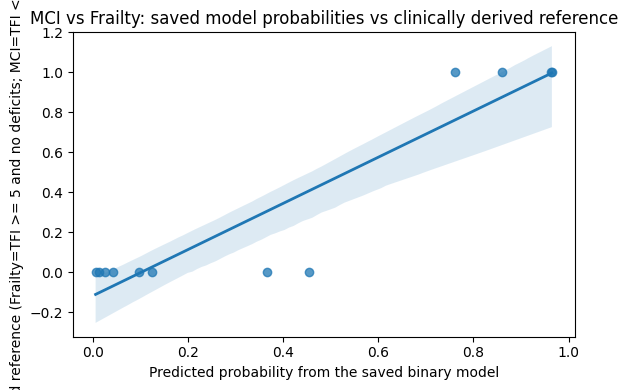

clinical_reference_MCIvsFrailty
NaN    39
0.0    22
1.0    16
Name: count, dtype: int64


{'comparison': 'MCI vs Frailty',
 'n_test': 24,
 'n_reference_valid': 12,
 'ols_model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f6be93d6e10>,
 'predictions':       id    group Gender  Age  Education level  MMSE  Corsi D.  Digit D.  \
 103  105      MCI      M   72               18  25.0      3.94      4.99   
 2      3      MCI      F   67                8  27.0      4.25      5.23   
 68    70      MCI      F   70                8  27.4      5.36      6.35   
 19    20  Frailty      F   72               13  25.7      4.11      5.13   
 75    77  Frailty      F   84                8  30.0      4.66      5.65   
 7      8      MCI      M   69               17  25.2      4.83      3.87   
 39    40      MCI      F   87                8  26.8      4.87      6.87   
 38    39      MCI      F   73               17  30.0      3.94      4.99   
 81    83      MCI      M   71               13  22.7      7.11      6.30   
 32    33      MCI      F   66               

In [95]:
df_mci_frailty = df[df['group'].isin(['MCI', 'Frailty'])].copy()
df_mci_frailty['clinical_reference_MCIvsFrailty'] = np.where(
    (df_mci_frailty['TFI_total'] >= 5) & (df_mci_frailty['n_deficient'] == 0),
    1,
    np.where(
        (df_mci_frailty['TFI_total'] < 5) & (df_mci_frailty['n_deficient'] >= 1),
        0,
        np.nan
    )
)
df.loc[df_mci_frailty.index, 'clinical_reference_MCIvsFrailty'] = df_mci_frailty['clinical_reference_MCIvsFrailty']

mci_frailty_results = run_saved_model_vs_reference(
    comparison_name='MCI vs Frailty',
    reference_col='clinical_reference_MCIvsFrailty',
    y_label='Clinically derived reference (Frailty=TFI >= 5 and no deficits; MCI=TFI < 5 and >=1 deficit)',
    title='MCI vs Frailty: saved model probabilities vs clinically derived reference'
)

print(df_mci_frailty['clinical_reference_MCIvsFrailty'].value_counts(dropna=False))
mci_frailty_results


The outputs above provide an external validity check: if model probabilities increase with the clinically derived label, the model is capturing a clinically meaningful signal rather than only separating the observed groups in the dataset.

## Robustness analysis of semantic LASSO models with fixed-count downsampling

We repeated the binary classifications with the same preprocessing and model family, but restricted the feature set to the non-zero LASSO coefficients selected in the original analysis. To assess class imbalance, we applied fixed-count downsampling of the majority class in the training set only, while leaving the held-out test set unchanged.

Each model used KNN imputation ($k = 5$) and standardization inside a ColumnTransformer, followed by L1-penalized logistic regression with the liblinear solver and balanced class weights. We report accuracy, precision, recall, specificity, F1-score, ROC-AUC, and PR-AUC, together with confusion matrices, ROC and PR curves, and bootstrap confidence intervals.

To assess robustness, we repeated the downsampling analysis across 100 random seeds and summarized the metric distributions with boxplots.

In [139]:
# Build the preprocessing pipeline.
def make_preprocessor(feature_names, n_neighbors=5):
    """
    Apply KNN imputation and standardization to the specified feature columns.
    """
    numeric_transformer = Pipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=n_neighbors)),
        ("scaler", StandardScaler())
    ])

    return ColumnTransformer(
        transformers=[("num", numeric_transformer, list(feature_names))],
        remainder="drop"
    )


# Build the LASSO logistic-regression model.
def make_lasso_lr(random_state=42, C=1.0, class_weight="balanced"):
    """
    Create an L1-penalized logistic-regression estimator using the liblinear solver.
    """
    return LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        class_weight=class_weight,
        random_state=random_state
    )


# Compute classification metrics.
def compute_metrics(y_true, y_pred, y_proba):
    """
    Returns Accuracy, Precision, Recall, Specificity, F1, ROC_AUC, PR_AUC.
    The positive class is encoded as 1.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "Specificity": np.nan,
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC_AUC": np.nan,
            "PR_AUC": np.nan,
        }

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    roc_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(rec_vals, prec_vals)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
    }


def bootstrap_metrics(y_test, X_test, fitted_pipeline, n_iter=1000, random_state=42, verbose=True):
    """
    Bootstrap metrics on test set by resampling indices with replacement.
    Uses the fitted_pipeline to get predictions/probabilities.
    """
    rng = np.random.RandomState(random_state)

    y_test_arr = np.asarray(y_test)
    n = len(y_test_arr)

    # predict once, then index (fast and deterministic)
    y_pred_full = fitted_pipeline.predict(X_test)
    y_proba_full = fitted_pipeline.predict_proba(X_test)[:, 1]

    boot = {k: [] for k in ["Accuracy","Precision","Recall","Specificity","F1","ROC_AUC","PR_AUC"]}

    for _ in range(n_iter):
        idx = rng.choice(n, size=n, replace=True)
        y_b = y_test_arr[idx]
        y_pred_b = np.asarray(y_pred_full)[idx]
        y_proba_b = np.asarray(y_proba_full)[idx]

        if len(np.unique(y_b)) < 2:
            continue

        m = compute_metrics(y_b, y_pred_b, y_proba_b)
        for k in boot:
            boot[k].append(m[k])

    if verbose:
        print("Bootstrapped metrics (mean ± std) [95% CI]:")
        for k, vals in boot.items():
            vals = np.asarray(vals, dtype=float)
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                print(f"{k}: NA")
                continue
            mean = vals.mean()
            std = vals.std()
            ci_low = np.percentile(vals, 2.5)
            ci_high = np.percentile(vals, 97.5)
            print(f"{k}: {mean:.3f} ± {std:.3f} | 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

    return boot


# Plot evaluation curves and confusion matrices as separate figures.
def plot_evaluation_curves(y_true, y_proba, y_pred, title_prefix="Model"):
    """
    Generate ROC, precision-recall, and confusion-matrix figures separately.
    """
    y_true = np.asarray(y_true)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC: {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} — ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC: {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} — Precision–Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title_prefix} — Confusion Matrix")
    plt.tight_layout()
    plt.show()


# Your exact boxplot function (unchanged)
def plot_robustness_boxplot(
    results_df,
    metrics_to_plot=None,
    title="Repeated Downsampling Robustness"
):
    if metrics_to_plot is None:
        metrics_to_plot = ['Accuracy', 'F1', 'Recall', 'ROC_AUC', 'PR_AUC']

    paper_colors = [
        "#5F7FA6",  # Accuracy
        "#C7772C",  # F1
        "#556F2D",  # Recall
        "#466789",  # ROC_AUC
        "#D8B11E"   # PR_AUC
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    bp = ax.boxplot(
        [results_df[m].dropna() for m in metrics_to_plot],
        patch_artist=True,
        labels=metrics_to_plot,
        widths=0.6,
        showmeans=True
    )

    for patch, color in zip(bp['boxes'], paper_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('#333333')
        patch.set_linewidth(1.2)

    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    for mean in bp['means']:
        mean.set_marker('D')
        mean.set_markerfacecolor('white')
        mean.set_markeredgecolor('#333333')
        mean.set_markersize(5)

    for whisker in bp['whiskers']:
        whisker.set_color('#444444')

    for cap in bp['caps']:
        cap.set_color('#444444')

    for flier in bp['fliers']:
        flier.set(
            marker='o',
            markerfacecolor='#333333',
            markeredgecolor='#333333',
            alpha=0.45,
            markersize=4
        )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


# Assess robustness across repeated downsampling seeds. (fixed-count training-only)
def repeated_downsampling_robustness(
    *,
    X_train_sub,
    y_train,
    X_test_sub,
    y_test,
    feature_subset,
    counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness"
):
    """
    For each seed:
      - downsample TRAIN to fixed counts (counts={0:k,1:k})
      - fit LASSO LR pipeline (same preprocessing)
      - evaluate on unchanged TEST
    Returns:
      results_df: per-seed metrics
      summary_df: mean/std/min/max per metric
    """
    rows = []

    for i in range(n_repeats):
        seed = random_state_start + i

        rus = RandomUnderSampler(sampling_strategy=counts, random_state=seed)
        X_bal, y_bal = rus.fit_resample(X_train_sub, y_train)

        pipe = Pipeline(steps=[
            ("preprocessing", make_preprocessor(feature_subset)),
            ("classifier", make_lasso_lr(random_state=seed, C=1.0))
        ])
        pipe.fit(X_bal, y_bal)

        y_pred = pipe.predict(X_test_sub)
        y_proba = pipe.predict_proba(X_test_sub)[:, 1]

        m = compute_metrics(y_test, y_pred, y_proba)
        m["seed"] = seed
        rows.append(m)

    results_df = pd.DataFrame(rows)

    summary_df = results_df.drop(columns=["seed"]).agg(["mean", "std", "min", "max"]).T
    summary_df.columns = ["Mean", "SD", "Min", "Max"]

    print(title)
    print(summary_df.round(3))

    return results_df, summary_df


### FF vs MCI: fixed-count downsampling robustness

Feature subset used (FF vs MCI): ['FAB', 'STROOP-STIR', 'Density_PIT', 'Fluency A', 'perseverations_tot', 'MFPT-CS', 'cluster_switches_tot', 'word_freq_tot', 'cluster_size_tot', 'Fluency S', 'PIT (elements)']

Training distribution BEFORE balancing:
group
0    39
1    14
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.94      0.83      0.88        18
           1       0.62      0.83      0.71         6

    accuracy                           0.83        24
   macro avg       0.78      0.83      0.80        24
weighted avg       0.86      0.83      0.84        24


Unbalanced — test set metrics:
{'Accuracy': 0.833, 'Precision': 0.625, 'Recall': 0.833, 'Specificity': 0.833, 'F1': 0.714, 'ROC_AUC': 0.935, 'PR_AUC': 0.803}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.831 ± 0.075 | 95% CI [0.667, 0.958]
Precision: 0.626 ± 0.180 | 95% C

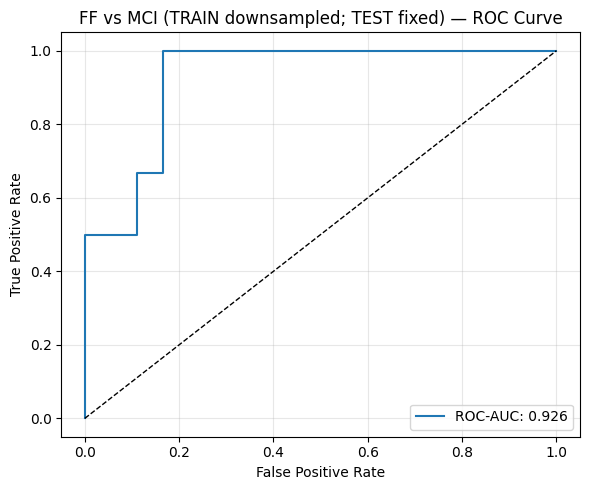

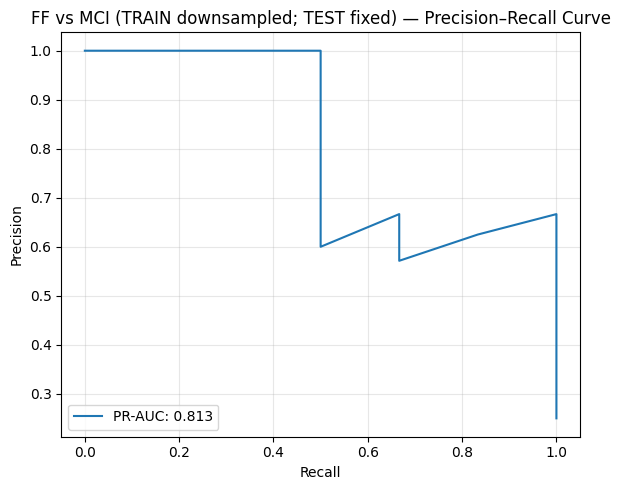

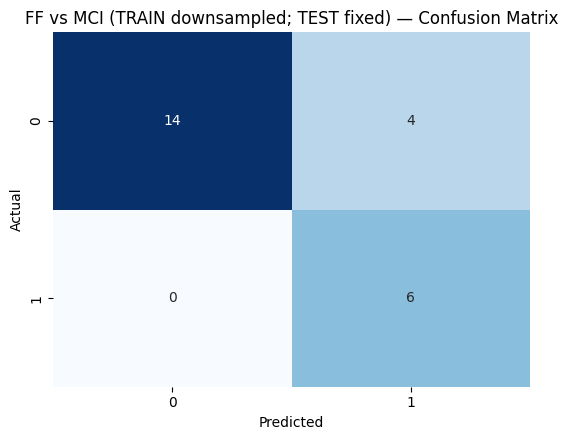

Repeated Downsampling Robustness — FF vs MCI
              Mean     SD    Min    Max
Accuracy     0.823  0.046  0.667  0.917
Precision    0.613  0.081  0.375  0.800
Recall       0.843  0.134  0.500  1.000
Specificity  0.816  0.062  0.667  0.944
F1           0.703  0.074  0.429  0.857
ROC_AUC      0.899  0.031  0.787  0.963
PR_AUC       0.670  0.118  0.456  0.920


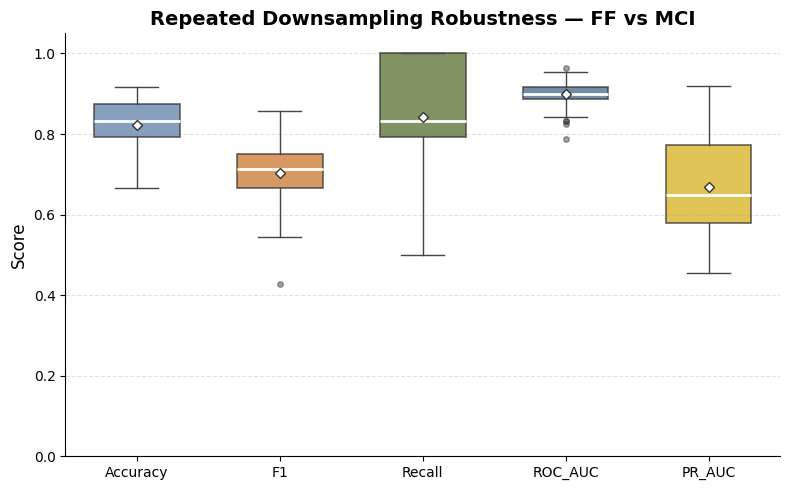

In [ ]:
# FF vs MCI semantic robustness.
# Positive class: FF.
# The training set is balanced by downsampling the majority class to the minority count.

df_task = df[df['group'].isin(['MCI', 'Frailty'])].copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("FF_MCI", X_train.columns)
print("Feature subset used (Frailty vs MCI):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution before balancing:")
print(y_train.value_counts())

# Fit and evaluate the unbalanced training pipeline.
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (unbalanced, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (unbalanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# Fit and evaluate the downsampled training pipeline.
k = int(y_train.value_counts().min())
counts = {0: k, 1: k}

rus = RandomUnderSampler(sampling_strategy=counts, random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_sub, y_train)

print("\nTraining distribution after balancing (TRAIN downsampling only):")
print(pd.Series(y_train_bal).value_counts())

pipe_bal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_bal, y_train_bal)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (balanced, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (balanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Visualize final metrics and robustness across repeated downsampling.
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="Frailty vs MCI (training downsampled; held-out test set unchanged)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — Frailty vs MCI"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — Frailty vs MCI")


### MCI vs All: fixed-count downsampling robustness


Feature subset used (MCI vs All): ['Fluency S', 'Fluency A', 'FAB', 'MFPT-UD', 'perseverations_tot', 'Clustering_PIT', 'STROOP-STIR', 'PIT (elements)', 'switch_rate_tot', 'word_freq_tot', 'Density_PIT']

Training distribution BEFORE balancing:
group
1    40
0    36
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.86      0.71      0.77        17

    accuracy                           0.79        33
   macro avg       0.80      0.79      0.79        33
weighted avg       0.80      0.79      0.79        33


Unbalanced — test set metrics:
{'Accuracy': 0.788, 'Precision': 0.857, 'Recall': 0.706, 'Specificity': 0.875, 'F1': 0.774, 'ROC_AUC': 0.801, 'PR_AUC': 0.855}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.785 ± 0.073 | 95% CI [0.636, 0.909]
Precision: 0.851 ± 0.098 | 95% CI [0.6

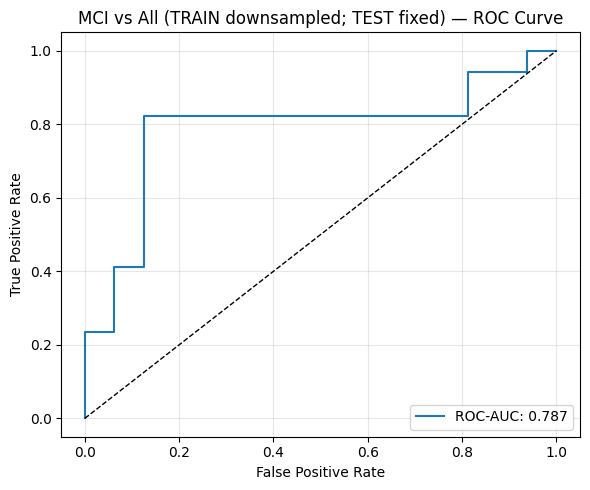

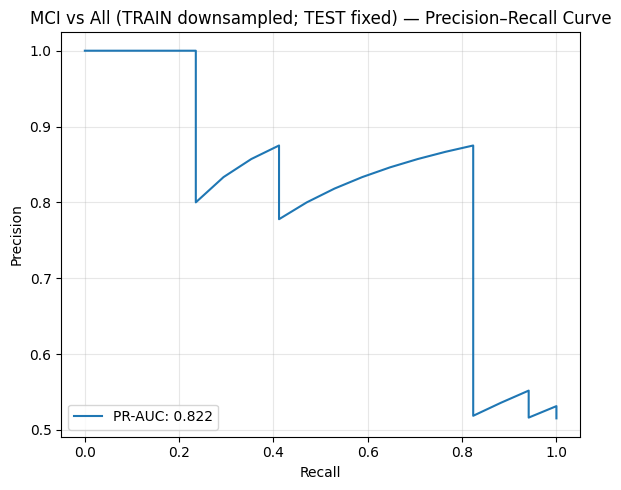

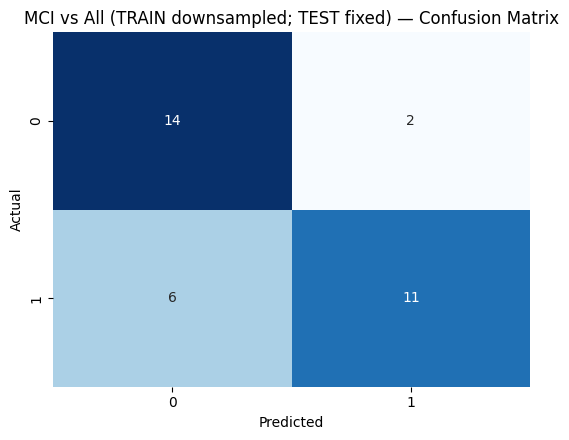

Repeated Downsampling Robustness — MCI vs All
              Mean     SD    Min    Max
Accuracy     0.779  0.022  0.727  0.818
Precision    0.851  0.014  0.800  0.867
Recall       0.691  0.042  0.588  0.765
Specificity  0.872  0.014  0.812  0.875
F1           0.762  0.030  0.690  0.812
ROC_AUC      0.808  0.015  0.779  0.842
PR_AUC       0.855  0.015  0.806  0.882


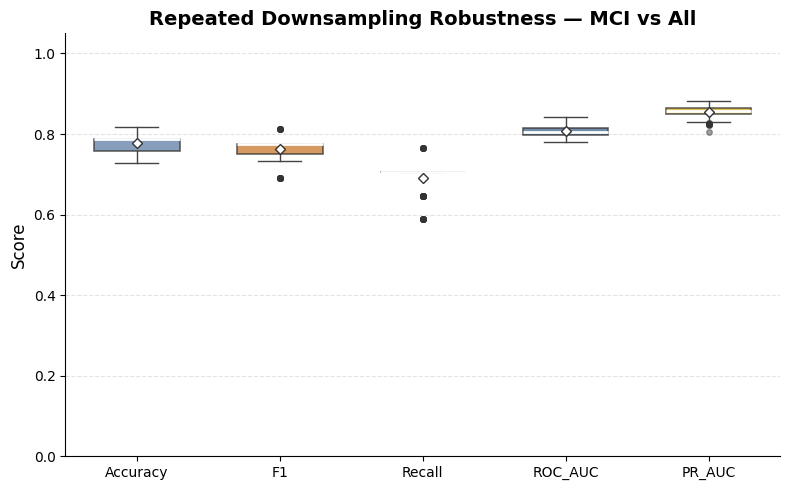

In [ ]:
# MCI vs All semantic robustness.
# Positive class: MCI.
# The training set is balanced by downsampling the majority class to the minority count.

df_task = df.copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'MCI' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("MCI_ALL", X_train.columns)
print("Feature subset used (MCI vs All):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution before balancing:")
print(y_train.value_counts())

# Fit and evaluate the unbalanced training pipeline.
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (unbalanced, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (unbalanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# Fit and evaluate the downsampled training pipeline.
k = int(y_train.value_counts().min())
counts = {0: k, 1: k}

rus = RandomUnderSampler(sampling_strategy=counts, random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_sub, y_train)

print("\nTraining distribution after balancing (TRAIN downsampling only):")
print(pd.Series(y_train_bal).value_counts())

pipe_bal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_bal, y_train_bal)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (balanced, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (balanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Visualize final metrics and robustness across repeated downsampling.
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="MCI vs All (training downsampled; held-out test set unchanged)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — MCI vs All"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — MCI vs All")


### FF vs HC: fixed-count downsampling robustness


Feature subset used (FF vs HC): ['MFPT-CS', 'MFPT-UD', 'PIT (elements)', 'PIT (s)', 'Fluency Shifting', 'aoa_tot', 'Clustering_PIT', 'intrusions_tot', 'TMT-B', 'word_freq_tot', 'STROOP-STIR', 'cluster_size_tot']

Training distribution BEFORE balancing:
group
0    22
1    14
Name: count, dtype: int64

Classification report (UNBALANCED, test set)
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.38      0.50      0.43         6

    accuracy                           0.50        16
   macro avg       0.50      0.50      0.49        16
weighted avg       0.53      0.50      0.51        16


Unbalanced — test set metrics:
{'Accuracy': 0.5, 'Precision': 0.375, 'Recall': 0.5, 'Specificity': 0.5, 'F1': 0.429, 'ROC_AUC': 0.617, 'PR_AUC': 0.557}

Bootstrapped metrics (UNBALANCED, test set):
Bootstrapped metrics (mean ± std) [95% CI]:
Accuracy: 0.503 ± 0.123 | 95% CI [0.250, 0.750]
Precision: 0.376 ± 0.178 | 95% CI [

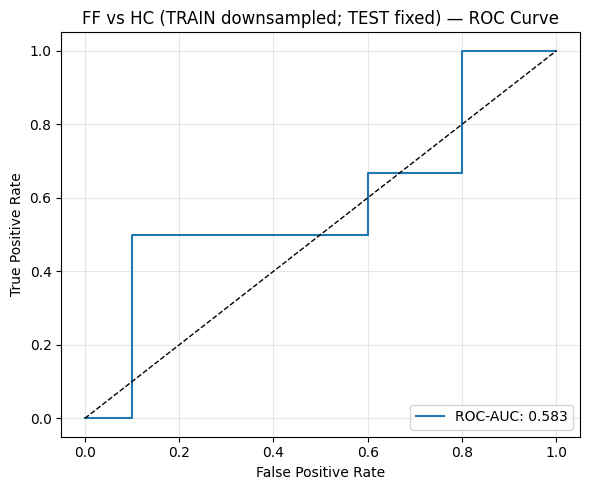

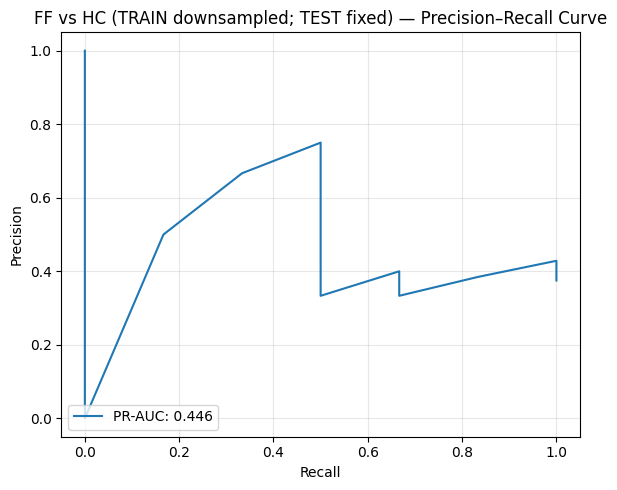

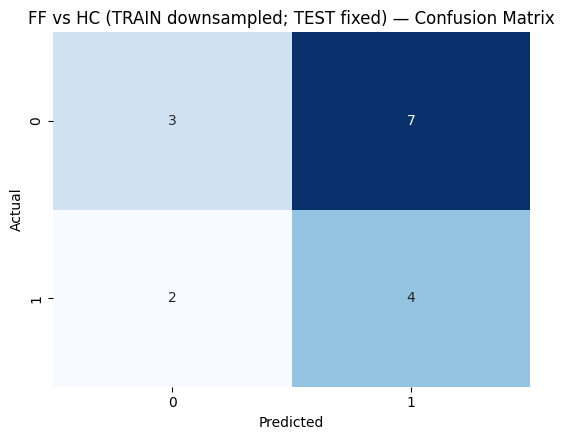

Repeated Downsampling Robustness — FF vs HC
              Mean     SD    Min    Max
Accuracy     0.499  0.083  0.312  0.688
Precision    0.395  0.066  0.273  0.556
Recall       0.613  0.118  0.500  0.833
Specificity  0.431  0.111  0.200  0.700
F1           0.478  0.077  0.353  0.667
ROC_AUC      0.603  0.053  0.500  0.717
PR_AUC       0.526  0.075  0.347  0.694


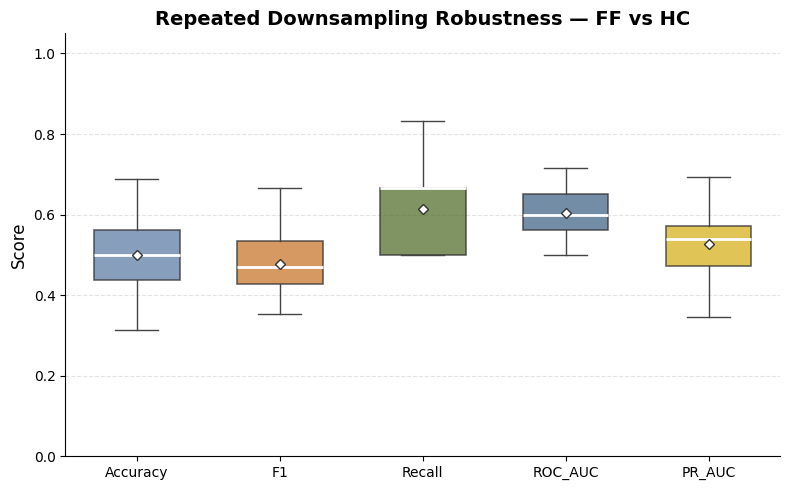

In [ ]:
# FF vs HC semantic robustness.
# Positive class: FF.
# The training set is balanced by downsampling the majority class to the minority count.

df_task = df[df['group'].isin(['HC', 'Frailty'])].copy()
X_all = df_task[selected_features]
y_all = df_task['group'].apply(lambda g: 1 if g == 'Frailty' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, stratify=y_all, test_size=0.3, random_state=42
)

feature_subset = get_feature_subset("FF_HC", X_train.columns)
print("Feature subset used (Frailty vs healthy controls):", feature_subset)

X_train_sub = X_train[feature_subset].copy()
X_test_sub  = X_test[feature_subset].copy()

print("\nTraining distribution before balancing:")
print(y_train.value_counts())

# Fit and evaluate the unbalanced training pipeline.
pipe_unbal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_unbal.fit(X_train_sub, y_train)

yu_pred  = pipe_unbal.predict(X_test_sub)
yu_proba = pipe_unbal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (unbalanced, test set)")
print(classification_report(y_test, yu_pred))
metrics_unbal = compute_metrics(y_test, yu_pred, yu_proba)
print_metrics("\nUnbalanced — test set metrics:", metrics_unbal)

print("\nBootstrapped metrics (unbalanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_unbal, n_iter=1000, random_state=42)

# Fit and evaluate the downsampled training pipeline.
k = int(y_train.value_counts().min())
counts = {0: k, 1: k}

rus = RandomUnderSampler(sampling_strategy=counts, random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_sub, y_train)

print("\nTraining distribution after balancing (TRAIN downsampling only):")
print(pd.Series(y_train_bal).value_counts())

pipe_bal = Pipeline(steps=[
    ('preprocessing', make_preprocessor(feature_subset)),
    ('classifier', make_lasso_lr(random_state=42, C=1.0))
])
pipe_bal.fit(X_train_bal, y_train_bal)

y_pred  = pipe_bal.predict(X_test_sub)
y_proba = pipe_bal.predict_proba(X_test_sub)[:, 1]
print("\nClassification report (balanced, test set)")
print(classification_report(y_test, y_pred))
metrics_bal = compute_metrics(y_test, y_pred, y_proba)
print_metrics("\nBalanced (k=minority TRAIN count) — test set metrics:", metrics_bal)

print("\nBootstrapped metrics (balanced, test set):")
_ = bootstrap_metrics(y_test, X_test_sub, pipe_bal, n_iter=1000, random_state=42)

print("\nComparison (same split, same feature subset):")
print("Unbalanced:", {k: round(v, 3) for k, v in metrics_unbal.items()})
print("Balanced:",   {k: round(v, 3) for k, v in metrics_bal.items()})

print("\nKey metrics summary (Acc, F1, Recall, ROC_AUC):")
print({m: (round(metrics_unbal[m], 3), round(metrics_bal[m], 3))
       for m in ['Accuracy', 'F1', 'Recall', 'ROC_AUC']})

# Visualize final metrics and robustness across repeated downsampling.
plot_evaluation_curves(y_test, y_proba, y_pred, title_prefix="Frailty vs healthy controls (training downsampled; held-out test set unchanged)")

results_df, summary_df = repeated_downsampling_robustness(
    X_train_sub=X_train_sub,
    y_train=y_train,
    X_test_sub=X_test_sub,
    y_test=y_test,
    feature_subset=feature_subset,
    counts=counts,
    n_repeats=100,
    random_state_start=0,
    title="Repeated Downsampling Robustness — Frailty vs healthy controls"
)

plot_robustness_boxplot(results_df, title="Repeated Downsampling Robustness — Frailty vs healthy controls")
